In [1]:

# %%
import numpy as np
import os
import cv2
import gzip
import shutil
from astropy.io import fits
from PIL import Image, ImageTk
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ast
import math
import time
import warnings
warnings.filterwarnings("ignore")

top_dir = 'E:/pythonfile/main-task-image/'
output_dir = 'E:/pythonfile/main-task/output-fts/'

# function convert to jpg format
def fts_to_jpg(image_fts):
    min_val = np.min(image_fts)
    max_val = np.max(image_fts)
    normalized_array = (image_fts - min_val) / (max_val - min_val)
    jpg_scaled_array = normalized_array * 255
    jpg_converted_array = jpg_scaled_array.astype(np.uint8)
    return jpg_converted_array

# function adjust image size by aspect ratio
def resize_with_aspect_ratio(data):
    img = Image.fromarray(data)
    img.thumbnail((800, 600))
    data_resized = np.array(img)
    return data_resized

fts_gz_files = []

# import images in fst format
for root, dirs, files in os.walk(top_dir):
    for file in files:
        file_path = os.path.join(root, file)
        if file.endswith('.fts.gz'):
            try:
                extracted_fits_file = os.path.join(output_dir, file.replace('.gz', ''))
                with gzip.open(file_path, 'rb') as f_in:
                    with open(extracted_fits_file, 'wb') as f_out:
                        shutil.copyfileobj(f_in, f_out)
                hdul = fits.open(extracted_fits_file)
                data = hdul[0].data
                data = np.flipud(data)
                data = fts_to_jpg(data)
                data = resize_with_aspect_ratio(data)
                fts_gz_files.append({
                    'filename': file.replace('.fts.gz', ''),
                    'image_data': data
                })
            except Exception as e:
                print(f"read file {file_path} error: {e}")



In [2]:
def set_seed(seed=42):
    """
    Set all possible random seeds to ensure experimental results are reproducible
    
    Args:
        seed: Random seed value
    """
    import random
    import numpy as np
    import torch
    import os
    
    # Python's random module
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    
    # CUDA/GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If using multiple GPUs
        
        # The following two lines make CUDA operations more deterministic, but may reduce performance
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Set Python hash seed, affects some internal operations
    os.environ['PYTHONHASHSEED'] = str(seed)


In [3]:
import torch.nn.functional as F
# function convert string to tuple. example:(10,20,30,40)->10,20,30,40
def parse_coordinates(val):
        try:
            return ast.literal_eval(val) if isinstance(val, str) else val
        except (ValueError, SyntaxError):
            return None

def data_process(data_name):
    # Ensure file_path is correctly defined
    file_path = 'E:/pythonfile/main-task/'  # Add this line if file_path is not defined

    lable = pd.read_csv(file_path + data_name + '.csv')
    lable['ID'] = lable['ID'].str.replace('.fts', '', regex=False)
    if lable[data_name+'_lable'].dtype == 'object':  # If it's object/string type
        lable[data_name+'_lable'] = lable[data_name+'_lable'].str.replace(r'(?<=\d)-|-(?=\d)', '', regex=True)
    else:
        lable[data_name+'_lable'] = lable[data_name+'_lable'].astype(str).str.replace(r'(?<=\d)-|-(?=\d)', '', regex=True)
        lable[data_name+'_lable'] = lable[data_name+'_lable'].str.replace(r'\.0$', '', regex=True)
    #lable[data_name+'_lable'] = lable[data_name+'_lable'].str.replace(r'(?<=\d)-|-(?=\d)', '', regex=True)
    lable[data_name+'_lable'] = lable[data_name+'_lable'].replace('nan', '')
    lable = lable.dropna()
    lable = lable[lable[data_name+'_lable'] != '']
    
    df = []
    successful_count = 0
    failed_count = 0
    
    for index, row in lable.iterrows():
        file_id = row['ID']
        coordinates = parse_coordinates(row[data_name])
        label = row[data_name+'_lable']
        
        # Check if coordinates are valid
        if coordinates is None:
            print(f"Warning: Invalid coordinates for ID {file_id}")
            failed_count += 1
            continue
            
        # Continue from previous code
        matching_image = None
        for item in fts_gz_files:
            if file_id in item['filename']:
                matching_image = item['image_data']
                break
        
        if matching_image is not None:
            try:
                x1, y1, x2, y2 = coordinates
                # Check if coordinate range is valid
                if x1 >= x2 or y1 >= y2 or x1 < 0 or y1 < 0:
                    print(f"Warning: Invalid coordinate range for ID {file_id}: ({x1},{y1},{x2},{y2})")
                    failed_count += 1
                    continue
                    
                # Check if coordinates exceed image boundaries
                img_height, img_width = matching_image.shape[:2]
                if x2 > img_width or y2 > img_height:
                    #print(f"Warning: Coordinates for ID {file_id} exceed image boundaries")
                    failed_count += 1
                    continue
                    
                cropped_image = matching_image[y1:y2, x1:x2]
                
                # Check if the cropped image is valid
                if cropped_image.size == 0:
                    print(f"Warning: Empty cropped image for ID {file_id}")
                    failed_count += 1
                    continue
                
                # Rotate the cropped image 90 degrees counterclockwise
                rotated_image = cv2.rotate(cropped_image, cv2.ROTATE_90_COUNTERCLOCKWISE)
                
                df.append({
                    'ID': file_id,
                    'image_data': rotated_image,
                    'coordinates': coordinates,
                    'label': label
                })
                successful_count += 1
                
            except Exception as e:
                print(f"Error: An error occurred while processing ID {file_id}: {e}")
                failed_count += 1
                
        else:
            print(f"No matching image found for ID: {file_id}")
            failed_count += 1
    
    print(f"\nProcessing completed: {successful_count} successful, {failed_count} failed")
    return df

# %%
# PyTorch versions of label and image processing (keeping same logic)
class LabelProcessor:
    def __init__(self, data):
        # create character set
        self.chars = set()
        for item in data:
            self.chars.update(set(item['label']))
        self.chars = sorted(list(self.chars))
        
        # create character to index mapping
        self.char_to_num = {char: i+1 for i, char in enumerate(self.chars)}  # Start numbering from 1, 0 reserved for blank
        self.num_to_char = {i+1: char for i, char in enumerate(self.chars)}  # Start numbering from 1, 0 reserved for blank
        self.num_to_char[0] = ''  # Explicitly set blank as empty character
        
        self.max_label_length = max(len(item['label']) for item in data)  # Maximum label length
        
        print(f"Character set size: {len(self.chars)}")
        print(f"Maximum label length: {self.max_label_length}")
        print("Character set: ", self.chars)
    
    # convert text labels into numerical sequences
    def encode_label(self, label):
        label_nums = [self.char_to_num[char] for char in label]
        label_padded = label_nums + [0] * (self.max_label_length - len(label_nums))
        return np.array(label_padded)

# ImagePreprocessor class - Modify necessary parts
# ImagePreprocessor class - Fix handling of None values
class ImagePreprocessor:
    def __init__(self, data):
        # calculate the maximum width and height in the dataset
        max_width = 0
        max_height = 0
        for item in data:
            # Check if image data is empty - Added
            if item.get('image_data') is None:
                print(f"Warning: Empty image data for ID {item.get('ID', 'unknown')}")
                continue
                
            # Use actual image data instead of coordinates to calculate dimensions - Modified
            img_data = item['image_data']
            height, width = img_data.shape[:2]
            max_width = max(max_width, width)
            max_height = max(max_height, height)
        
        # Ensure width and height are multiples of 8 for network downsampling
        if max_width % 8 != 0:
            max_width = ((max_width // 8) + 1) * 8
        if max_height % 8 != 0:
            max_height = ((max_height // 8) + 1) * 8
            
        self.target_size = (max_height, max_width)
        print(f"Maximum image dimensions - Height: {max_height}, Width: {max_width}")
    
    # expand image - Keep original logic, just remove negative value errors
    def pad_image(self, image):
        # original image size
        original_height = image.shape[0]
        original_width = image.shape[1]
        
        pad_height = self.target_size[0] - original_height
        pad_width = self.target_size[1] - original_width
        
        # Ensure padding is not negative - Added safety check
        pad_height = max(0, pad_height)
        pad_width = max(0, pad_width)
        
        top_pad = pad_height // 2
        bottom_pad = pad_height - top_pad
        left_pad = pad_width // 2
        right_pad = pad_width - left_pad
        
        padded_image = np.pad(
            image,
            ((top_pad, bottom_pad), 
             (left_pad, right_pad)),
            mode='constant',
            constant_values=0
        )
        
        return padded_image, (top_pad, left_pad, bottom_pad, right_pad)

    def process_image(self, image):
        padded_image, padding_info = self.pad_image(image)  # expand image
        processed_image = padded_image.astype(np.float32) / 255.0
        return processed_image, padding_info
    

# Simplified data augmentation
class SimpleDataAugmentation:
    def __init__(self, p=0.3):
        """
        Simplified data augmentation strategy for stability
        
        Args:
            p: Probability of applying each augmentation
        """
        self.p = p
        
        # Basic transformations
        self.transforms = transforms.Compose([
            # Random affine transform - Minor movement, rotation and scaling
            transforms.RandomApply([
                transforms.RandomAffine(
                    degrees=1,  # Very small angle rotation
                    translate=(0.01, 0.01),  # Slight translation
                    scale=(0.99, 1.01),  # Slight scaling
                    fill=0  # Fill value
                )
            ], p=p),
            
            # Brightness, contrast adjustment
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.1,
                    contrast=0.1
                )
            ], p=p),
        ])
    
    def __call__(self, x):
        return self.transforms(x)

# Normalize image
def normalize_image(image):
    """Normalize image to [0,1] range"""
    return image  # Image already scaled to [0,1] in preprocessing

# Simplified dataset class
class SimpleOCRDataset(Dataset):
    def __init__(self, images, labels, transforms=None, is_training=True):
        self.images = images
        self.labels = labels
        self.transforms = transforms
        self.is_training = is_training
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Convert to tensor
        image_tensor = torch.FloatTensor(image).unsqueeze(0)  # Add channel dimension
        
        # Apply data augmentation during training
        if self.is_training and self.transforms:
            image_tensor = self.transforms(image_tensor)
            
        return image_tensor, torch.LongTensor(label)

# Process dataset and create train/val/test splits
# Process dataset and create train/val/test splits - Fix handling empty data
def process_dataset(data):
    image_preprocessor = ImagePreprocessor(data)
    label_processor = LabelProcessor(data)
    
    processed_images = []
    processed_labels = []
    original_images = []
    original_labels = []
    
    for item in data:
        # Check if image data is empty - Added
        if item.get('image_data') is None:
            print(f"Skipping ID {item.get('ID', 'unknown')} - Empty image data")
            continue
            
        # image
        processed_image, _ = image_preprocessor.process_image(item['image_data'])
        processed_images.append(processed_image)
        
        # label
        processed_label = label_processor.encode_label(item['label'])
        processed_labels.append(processed_label)
        
        # save original image
        original_images.append(item['image_data'])
        original_labels.append(item['label'])
    
    processed_images = np.array(processed_images)
    processed_labels = np.array(processed_labels)

    X_train_temp, X_val, y_train_temp, y_val, orig_train_labels_temp, orig_val_labels = train_test_split(
        processed_images, 
        processed_labels, 
        original_labels, 
        test_size=0.2, 
        random_state=42
    )

    X_train, X_test, y_train, y_test, orig_train_labels, orig_test_labels = train_test_split(
        X_train_temp,
        y_train_temp,
        orig_train_labels_temp,
        test_size=0.125,  # 0.125 = 0.1/0.8
        random_state=42
    )
    
    return {
        'train': {
            'images': X_train, 
            'labels': y_train, 
            'original_labels': orig_train_labels
        },
        'val': {
            'images': X_val, 
            'labels': y_val, 
            'original_labels': orig_val_labels
        },
        'test': {
            'images': X_test, 
            'labels': y_test, 
            'original_labels': orig_test_labels
        },
        'label_processor': label_processor,
        'image_preprocessor': image_preprocessor
    }
# Visualize samples from the training, validation and testing sets
def visualize_splits(data_splits, samples_per_split=5):
    plt.figure(figsize=(20, 8))
    
    for i in range(samples_per_split):
        plt.subplot(3, samples_per_split, i + 1)
        plt.imshow(data_splits['train']['images'][i], cmap='gray')
        plt.title(f'Train Sample\nlabels: {data_splits["train"]["original_labels"][i]}\n'
                 f'Encoded: {data_splits["train"]["labels"][i]}')
        plt.axis('on')
    
    for i in range(samples_per_split):
        plt.subplot(3, samples_per_split, i + samples_per_split + 1)
        plt.imshow(data_splits['val']['images'][i], cmap='gray')
        plt.title(f'Val Sample\nlabel: {data_splits["val"]["original_labels"][i]}\n'
                 f'Encoded: {data_splits["val"]["labels"][i]}')
        plt.axis('on')
    
    for i in range(samples_per_split):
        plt.subplot(3, samples_per_split, i + 2*samples_per_split + 1)
        plt.imshow(data_splits['test']['images'][i], cmap='gray')
        plt.title(f'Test Sample\nlabel: {data_splits["test"]["original_labels"][i]}\n'
                 f'Encoded: {data_splits["test"]["labels"][i]}')
        plt.axis('on')
    
    plt.tight_layout()
    plt.show()

def data_main(rell_number_df):
    # process the dataset and partition it
    data_splits = process_dataset(rell_number_df)
    
    print(f"Training set size: {len(data_splits['train']['images'])}")
    print(f"Validation set size: {len(data_splits['val']['images'])}")
    print(f"Test set size: {len(data_splits['test']['images'])}")
    print(f"Image shape: {data_splits['train']['images'][0].shape}")
    print(f"Label shape: {data_splits['train']['labels'][0].shape}")
    
    visualize_splits(data_splits)
    
    return data_splits

# %%
# Fixed simplified CRNN model
class CRNN(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CRNN, self).__init__()
        
        # Reduce model complexity by decreasing channel counts
        self.cnn = nn.Sequential(
            # First layer: Input channels 1 -> 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # Halve spatial dimensions
            
            # Second layer: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # Halve again
            
            # Third layer: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),  # Preserve width for sequence information
            
            # Fourth layer: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),  # Preserve width
        )
        
        self.cnn_dropout = nn.Dropout(0.2)
        
        # Calculate CNN output height
        h, w = input_shape
        h = h // 2 // 2 // 2 // 2  # Four pooling layers
        self.cnn_output_h = h
        
        # Simplify RNN layers, reduce from 3 to 2 layers
        self.rnn1 = nn.LSTM(256 * h, 128, bidirectional=True, batch_first=True)
        self.rnn_dropout1 = nn.Dropout(0.2)  # Lower dropout rate for training stability
        
        self.rnn2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.rnn_dropout2 = nn.Dropout(0.2)
        
        # Fully connected layer
        self.dense = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # CNN feature extraction
        conv = self.cnn(x)
        conv = self.cnn_dropout(conv)
        
        # Prepare RNN input
        batch, channels, height, width = conv.size()
        conv = conv.permute(0, 3, 1, 2)  # (batch, width, channels, height)
        conv = conv.reshape(batch, width, channels * height)
        
        # RNN sequence processing
        rnn_out1, _ = self.rnn1(conv)
        rnn_out1 = self.rnn_dropout1(rnn_out1)
        
        rnn_out2, _ = self.rnn2(rnn_out1)
        rnn_out2 = self.rnn_dropout2(rnn_out2)
        
        # Final prediction
        output = self.dense(rnn_out2)
        output = nn.functional.log_softmax(output, dim=2)
        
        return output

    
# Attention mechanism module
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.hidden_size = hidden_size
        
        # Attention weight calculation
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Parameter(torch.rand(hidden_size))
        stdv = 1. / math.sqrt(self.v.size(0))
        self.v.data.uniform_(-stdv, stdv)
        
    def forward(self, hidden, encoder_outputs):
        # hidden: [batch_size, hidden_size]
        # encoder_outputs: [batch_size, seq_len, hidden_size]
        
        batch_size = encoder_outputs.size(0)
        seq_len = encoder_outputs.size(1)
        
        # Create reusable hidden
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        
        # Concatenate hidden with encoder_outputs and pass through attention network
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        
        # Calculate attention weights
        attention = torch.matmul(energy, self.v)
        attention = F.softmax(attention, dim=1)
        
        # Use attention weights to weight encoder_outputs
        context = torch.bmm(attention.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1)
        
        return context, attention

# CRNN model with attention mechanism
class CRNNWithAttention(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CRNNWithAttention, self).__init__()
        
        # Use the same CNN part as the original CRNN
        self.cnn = nn.Sequential(
            # First layer: Input channels 1 -> 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # Halve spatial dimensions
            
            # Second layer: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # Halve again
            
            # Third layer: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),  # Preserve width for sequence information
            
            # Fourth layer: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1)),  # Preserve width
        )
        
        self.cnn_dropout = nn.Dropout(0.2)
        
        # Calculate CNN output height
        h, w = input_shape
        h = h // 2 // 2 // 2 // 2  # Four pooling layers
        self.cnn_output_h = h
        
        # RNN part
        self.rnn1 = nn.LSTM(256 * h, 128, bidirectional=True, batch_first=True)
        self.rnn_dropout1 = nn.Dropout(0.2)
        
        # Attention mechanism
        self.attention = Attention(256)  # Bidirectional LSTM, hidden size 128*2=256
        
        # Only need one LSTM layer as we'll use the attention mechanism
        self.rnn2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.rnn_dropout2 = nn.Dropout(0.2)
        
        # Fully connected layer
        self.dense = nn.Linear(256 * 2, num_classes)  # 256 from LSTM + 256 from attention
        
    def forward(self, x):
        # CNN feature extraction
        conv = self.cnn(x)
        conv = self.cnn_dropout(conv)
        
        # Prepare RNN input
        batch, channels, height, width = conv.size()
        conv = conv.permute(0, 3, 1, 2)  # (batch, width, channels, height)
        conv = conv.reshape(batch, width, channels * height)
        
        # First LSTM layer
        rnn_out1, (h, c) = self.rnn1(conv)
        rnn_out1 = self.rnn_dropout1(rnn_out1)
        
        # Apply attention mechanism
        h_combined = torch.cat((h[0], h[1]), dim=1)  # Combine bidirectional LSTM hidden states
        context, attention_weights = self.attention(h_combined, rnn_out1)
        
        # Second LSTM layer
        rnn_out2, _ = self.rnn2(rnn_out1)
        rnn_out2 = self.rnn_dropout2(rnn_out2)
        
        # For each time step, concatenate the context vector with LSTM output
        context_expanded = context.unsqueeze(1).expand(-1, rnn_out2.size(1), -1)
        combined = torch.cat((rnn_out2, context_expanded), dim=2)
        
        # Final prediction
        output = self.dense(combined)
        output = nn.functional.log_softmax(output, dim=2)
        
        return output

# Model selection function
def create_model(model_type, input_shape, num_classes, device):
    """
    Create model instance
    
    Args:
        model_type: Model type, 'crnn' or 'crnn_attention'
        input_shape: Input image shape (height, width)
        num_classes: Number of classes
        device: Computing device
        
    Returns:
        Created model instance
    """
    if model_type.lower() == 'crnn':
        model = CRNN(input_shape, num_classes)
    elif model_type.lower() == 'crnn_attention':
        model = CRNNWithAttention(input_shape, num_classes)
    else:
        raise ValueError(f"Unsupported model type: {model_type}, please choose 'crnn' or 'crnn_attention'")
    
    # Model initialization
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.constant_(m.bias, 0)
            
    return model.to(device)


# Custom CharacterAccuracy metric
class CharacterAccuracy:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.total_chars = 0
        self.correct_chars = 0
        
    def update(self, pred, target):
        """Update accuracy metrics with proper length handling"""
        pred_indices = pred.argmax(dim=2)
        
        # Handle sequence length differences
        min_len = min(pred_indices.size(1), target.size(1))
        pred_indices = pred_indices[:, :min_len]
        target = target[:, :min_len]
        
        # Create a mask to ignore padding
        mask = (target != 0).float()
        
        # Calculate correct predictions
        correct = (pred_indices == target).float() * mask
        
        self.total_chars += mask.sum().item()
        self.correct_chars += correct.sum().item()
        
    def get(self):
        return self.correct_chars / self.total_chars if self.total_chars > 0 else 0

# Greedy search decoder - Faster and more stable
def greedy_decode_predictions(predictions, label_processor):
    """
    Use greedy search for CTC decoding - Basic version
    
    Args:
        predictions: tensor of shape (batch_size, seq_len, num_classes)
        label_processor: LabelProcessor instance
    Returns:
        List of decoded text labels
    """
    pred_indices = predictions.argmax(dim=2).cpu().numpy()
    
    decoded_labels = []
    for pred in pred_indices:
        # Apply CTC decoding rules:
        # 1. Remove duplicate characters
        # 2. Remove blank characters (index 0)
        filtered = []
        last_char = -1
        for p in pred:
            if p != 0 and p != last_char:  # Not blank and not repeating
                filtered.append(p)
                last_char = p
        
        # Convert to text
        text = ''.join([label_processor.num_to_char.get(i, '') for i in filtered])
        decoded_labels.append(text)
    
    return decoded_labels

# Beam search decoder - Higher performance but potentially less stable than greedy search
def beam_decode_predictions(predictions, label_processor, beam_size=5):
    """
    Use simplified beam search for CTC decoding
    
    Args:
        predictions: tensor of shape (batch_size, seq_len, num_classes)
        label_processor: LabelProcessor instance
        beam_size: Beam width for search
    """
    pred_probs = torch.exp(predictions).cpu().numpy()  # Convert to probabilities
    batch_size = pred_probs.shape[0]
    decoded_labels = []
    
    for b in range(batch_size):
        # Only consider the top 5 most likely characters
        probs = pred_probs[b]
        
        # Greedy search - take highest probability at each position
        best_path = np.argmax(probs, axis=1)
        
        # Apply CTC rules to simplify path
        prev = -1
        filtered = []
        for p in best_path:
            if p != 0 and p != prev:  # Not blank and not repeating
                filtered.append(p)
            prev = p
        
        # Convert to text
        text = ''.join([label_processor.num_to_char.get(i, '') for i in filtered])
        decoded_labels.append(text)
    
    return decoded_labels

# Early stopping strategy
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, verbose=True):
        """
        Args:
            patience: Number of epochs to tolerate no improvement in validation metric
            min_delta: Minimum change considered as improvement
            verbose: Whether to print early stopping information
        """
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, val_score):
        if self.best_score is None:
            self.best_score = val_score
            return False
        
        # For metrics where higher is better (like accuracy)
        if val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} / {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        else:
            self.best_score = val_score
            self.counter = 0
            
        return False

# Validation function
def validate(model, dataloader, criterion, device, char_acc_metric):
    model.eval()
    val_loss = 0
    char_acc_metric.reset()
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate input and target lengths
            batch_size = outputs.size(0)
            input_lengths = torch.full((batch_size,), outputs.size(1), dtype=torch.long).to(device)
            target_lengths = torch.sum(targets > 0, dim=1).to(device)
            
            # Convert to CTC required format
            log_probs = outputs.permute(1, 0, 2)  # (T, N, C)
            targets_flat = targets.view(-1)
            targets_flat = targets_flat[targets_flat != 0]  # Remove padding
            
            # Calculate loss
            try:
                loss = criterion(log_probs, targets_flat, input_lengths, target_lengths)
                
                # Update character accuracy metric
                char_acc_metric.update(outputs, targets)
                
                val_loss += loss.item()
            except Exception as e:
                print(f"Error during validation: {e}")
                continue
            
    return val_loss / max(1, len(dataloader)), char_acc_metric.get()

# Fixed evaluation function
def fixed_evaluate_model(model, test_loader, label_processor, device, num_samples=10, use_beam_search=False):
    """
    Optimize model performance evaluation and visualize results, increase stability
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_images = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            # Save original images for visualization
            all_images.extend(images.cpu().numpy())
            
            try:
                # Forward pass
                predictions = model(images)
                
                # Save predictions and true labels
                all_predictions.append(predictions.cpu())
                all_labels.append(labels.cpu().numpy())
            except Exception as e:
                print(f"Error during evaluation: {e}")
                continue
    
    # Concatenate all batches
    if all_predictions:
        all_predictions = torch.cat(all_predictions, dim=0)
        all_labels = np.concatenate(all_labels, axis=0)
    else:
        print("Warning: No successful prediction results")
        return {
            'accuracy': 0.0, 
            'char_accuracy': 0.0,
            'predictions': [], 
            'true_labels': [],
            'edit_distance': 0.0
        }
    
    # Decode predictions
    if use_beam_search:
        print("Using beam search to decode predictions...")
        try:
            decoded_predictions = beam_decode_predictions(all_predictions, label_processor, beam_size=5)
        except Exception as e:
            print(f"Beam search decoding failed: {e}, falling back to greedy search")
            decoded_predictions = greedy_decode_predictions(all_predictions, label_processor)
    else:
        print("Using greedy search to decode predictions...")
        decoded_predictions = greedy_decode_predictions(all_predictions, label_processor)
    
    # Decode targets
    true_labels = []
    for label in all_labels:
        text = ''
        for idx in label:
            if idx != 0:  # Skip padding
                text += label_processor.num_to_char.get(idx, '')
        true_labels.append(text)
    
    # Calculate accuracy
    correct = sum(1 for pred, true in zip(decoded_predictions, true_labels) if pred == true)
    accuracy = correct / len(true_labels) if len(true_labels) > 0 else 0
    print(f"\nOverall prediction accuracy: {accuracy:.2%}")
    
    # Calculate character accuracy
    total_chars = sum(len(true) for true in true_labels)
    matching_characters = 0
    
    for pred, true in zip(decoded_predictions, true_labels):
        pred_len = len(pred)
        true_len = len(true)
        min_len = min(pred_len, true_len)
        
        # Calculate matching characters
        for i in range(min_len):
            if pred[i] == true[i]:
                matching_characters += 1
    
    char_accuracy = matching_characters / total_chars if total_chars > 0 else 0
    print(f"Character accuracy: {char_accuracy:.2%}")
    
    # Calculate edit distance
    try:
        import Levenshtein
        
        total_edit_distance = sum(Levenshtein.distance(pred, true) 
                               for pred, true in zip(decoded_predictions, true_labels))
        avg_edit_distance = total_edit_distance / len(true_labels) if len(true_labels) > 0 else 0
        print(f"Average edit distance: {avg_edit_distance:.2f}")
    except ImportError:
        print("Levenshtein library not installed, skipping edit distance calculation")
        avg_edit_distance = 0

    # Visualize some prediction results
    plt.figure(figsize=(20, 4 * ((min(num_samples, len(all_images)) + 4) // 5)))
    for i in range(min(num_samples, len(all_images))):
        plt.subplot((min(num_samples, len(all_images)) + 4) // 5, 5, i + 1)
        plt.imshow(all_images[i].squeeze(0), cmap='gray')
        
        # Calculate character match ratio
        if i < len(decoded_predictions) and i < len(true_labels):
            min_len = min(len(decoded_predictions[i]), len(true_labels[i]))
            matches = sum(1 for j in range(min_len) 
                        if decoded_predictions[i][j] == true_labels[i][j])
            char_match_ratio = matches / len(true_labels[i]) if len(true_labels[i]) > 0 else 0
            
            # Choose color based on accuracy
            if decoded_predictions[i] == true_labels[i]:
                color = 'blue'  # Completely correct
            elif char_match_ratio > 0.5:
                color = 'green'  # Mostly correct
            else:
                color = 'red'  # Mostly incorrect
                
            plt.title(f'true: {true_labels[i]}\npred: {decoded_predictions[i]}', color=color)
        else:
            plt.title("Sample data not available")
        
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'eval_results.png')
    plt.show()
    
    # Return analysis results
    return {
        'accuracy': accuracy, 
        'char_accuracy': char_accuracy,
        'predictions': decoded_predictions, 
        'true_labels': true_labels,
        'edit_distance': avg_edit_distance
    }

# Modified training function
def train_model(data_df, parameter, data_name, model_type='crnn', seed=42):
    """
    Main function for training OCR model, supporting different model architectures
    
    Args:
        data_df: DataFrame containing training data
        parameter: Training parameters tuple (epochs, batch_size, initial_lr)
        data_name: Dataset name
        model_type: Model type, 'crnn' or 'crnn_attention'
        
    Returns:
        Trained model, training history, data split info and evaluation results
    """
    import os
    import time
    
    set_seed(seed)
    epochs, batch_size, initial_lr = parameter
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"Selected model type: {model_type}")
    
    # Process data
    data_splits = process_dataset(data_df)
    label_processor = data_splits['label_processor']
    
    # Create datasets - reduce data augmentation intensity for stability
    train_dataset = SimpleOCRDataset(
        data_splits['train']['images'], 
        data_splits['train']['labels'],
        transforms=SimpleDataAugmentation(p=0.3),
        is_training=True
    )
    
    val_dataset = SimpleOCRDataset(
        data_splits['val']['images'], 
        data_splits['val']['labels'],
        is_training=False
    )
    
    test_dataset = SimpleOCRDataset(
        data_splits['test']['images'], 
        data_splits['test']['labels'],
        is_training=False
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        pin_memory=True,
        num_workers=0,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=True,
        num_workers=0
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=True,
        num_workers=0
    )
    
    # Get dimensions
    input_shape = (data_splits['train']['images'][0].shape[0], data_splits['train']['images'][0].shape[1])
    num_classes = len(label_processor.char_to_num) + 1  # +1 for blank/padding
    
    # Create model - use model selection function
    model = create_model(model_type, input_shape, num_classes, device)
    
    # Calculate model parameter count
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total model parameters: {total_params:,}")

    # Use standard CTC loss function, avoid custom complex logic
    criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    
    # Optimizer - use smaller learning rate
    optimizer = optim.Adam(  # Use standard Adam instead of AdamW
        model.parameters(), 
        lr=initial_lr, 
        weight_decay=1e-5,  # Reduce weight decay
    )
    
    # Learning rate scheduler - simplify to standard step scheduler
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        verbose=True
    )
    
    # Character accuracy metric
    char_acc_metric = CharacterAccuracy()
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_char_acc': [],
        'val_char_acc': [],
        'lr': []
    }
    
    # Best model tracking
    best_val_acc = 0
    best_val_loss = float('inf')
    
    # Create output directory
    output_dir = os.path.join(os.getcwd(), f'{data_name}_{model_type}_models')
    os.makedirs(output_dir, exist_ok=True)
    best_model_path = os.path.join(output_dir, f'{data_name}_{model_type}_best_model.pt')
    
    # Early stopping setup
    early_stopping = EarlyStopping(patience=30, min_delta=0.000001)
    
    # Training loop - avoid using mixed precision training for numerical stability
    start_time = time.time()
    
    for epoch in range(epochs):
        epoch_start = time.time()
        
        # Train
        model.train()
        train_loss = 0
        char_acc_metric.reset()
        
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(device)
            targets = targets.to(device)
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Calculate input and target lengths
            batch_size = outputs.size(0)
            input_lengths = torch.full((batch_size,), outputs.size(1), dtype=torch.long).to(device)
            target_lengths = torch.sum(targets > 0, dim=1).to(device)
            
            # Convert to format needed for CTC
            log_probs = outputs.permute(1, 0, 2)  # T x N x C
            targets_flat = targets.view(-1)
            targets_flat = targets_flat[targets_flat != 0]  # Remove padding
            
            try:
                loss = criterion(log_probs, targets_flat, input_lengths, target_lengths)
                
                # Check for NaN and skip
                if torch.isnan(loss).item():
                    print(f"Warning: Epoch {epoch+1}, batch {batch_idx} loss is NaN, skipping this batch")
                    continue
                
                # Backward pass
                loss.backward()
                
                # Gradient clipping - use smaller threshold
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                # Update weights
                optimizer.step()
                
                # Update character accuracy metric
                char_acc_metric.update(outputs, targets)
                
                train_loss += loss.item()
            except Exception as e:
                print(f"Warning: Error in batch {batch_idx}: {e}, skipping this batch")
                continue
        
        if len(train_loader) > 0:
            train_loss /= len(train_loader)
        else:
            train_loss = float('nan')
        
        train_char_acc = char_acc_metric.get()
        
        # Validate
        val_loss, val_char_acc = validate(model, val_loader, criterion, device, char_acc_metric)
        
        # Update learning rate - based on validation loss
        current_lr = optimizer.param_groups[0]['lr']
        lr_scheduler.step(val_loss)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_char_acc'].append(train_char_acc)
        history['val_char_acc'].append(val_char_acc)
        history['lr'].append(current_lr)
        
        # Calculate epoch time
        epoch_time = time.time() - epoch_start
        
        # Print progress
        print(f"Epoch {epoch+1}/{epochs} - "
              f"time: {epoch_time:.2f}s - "
              f"LR: {current_lr:.6f} - "
              f"train loss: {train_loss:.4f} - "
              f"val loss: {val_loss:.4f} - "
              f"train char acc: {train_char_acc:.4f} - "
              f"val char acc: {val_char_acc:.4f}")
        
        # Save best model - use validation loss as primary metric, character accuracy as secondary metric
        if val_loss < best_val_loss or (val_loss == best_val_loss and val_char_acc > best_val_acc):
            best_val_loss = val_loss
            best_val_acc = val_char_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_char_acc': val_char_acc,
                'char_to_num': label_processor.char_to_num,
                'num_to_char': label_processor.num_to_char,
                'input_shape': input_shape,
                'num_classes': num_classes,
                'model_type': model_type  # Save model type
            }, best_model_path)
            print(f"Saved best model, validation loss: {best_val_loss:.4f}, character accuracy: {best_val_acc:.4f}")
        
        # Check early stopping
        if early_stopping(val_char_acc):
            print(f"Early stopping triggered, stopping training at epoch {epoch+1}")
            break
    
    # Total training time
    total_time = time.time() - start_time
    print(f"\nTraining complete! Total time: {total_time/60:.2f} minutes")
    
    # Load best model for evaluation
    try:
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model (epoch {checkpoint['epoch']+1}), "
              f"validation loss: {checkpoint['val_loss']:.4f}, "
              f"character accuracy: {checkpoint['val_char_acc']:.4f}")
    except Exception as e:
        print(f"Could not load best model: {e}, using current model for evaluation")
    
    # Plot training history
    plt.figure(figsize=(16, 6))
    
    # Loss curve
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='train loss')
    plt.plot(history['val_loss'], label='val loss')
    plt.title('model loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.legend()
    
    # Character accuracy curve
    plt.subplot(1, 3, 2)
    plt.plot(history['train_char_acc'], label='train char acc')
    plt.plot(history['val_char_acc'], label='val char acc')
    plt.title('char acc')
    plt.xlabel('Epoch')
    plt.ylabel('acc')
    plt.legend()
    
    # Learning rate curve
    plt.subplot(1, 3, 3)
    plt.plot(history['lr'])
    plt.title('lr')
    plt.xlabel('Epoch')
    plt.ylabel('lr')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{data_name}_{model_type}_training_history.png'))
    plt.show()
    
    # Evaluate model - use greedy search to avoid potential instability of beam search
    print(f"\nEvaluating {model_type} model:")
    results = fixed_evaluate_model(
        model, test_loader, label_processor, device, num_samples=20, use_beam_search=False
    )
    
    # Save final model
    final_model_path = os.path.join(output_dir, f'{data_name}_{model_type}_final_model.pt')
    torch.save({
        'model_state_dict': model.state_dict(),
        'char_to_num': label_processor.char_to_num,
        'num_to_char': label_processor.num_to_char,
        'input_shape': input_shape,
        'num_classes': num_classes,
        'test_accuracy': results['accuracy'],
        'char_accuracy': results['char_accuracy'],
        'model_type': model_type  # Save model type
    }, final_model_path)
    print(f"\nTraining complete, final model saved to {final_model_path}")
    
    return model, history, data_splits, results

# Fixed training function

# Inference function - for predicting on new images
def predict_text(model, image, label_processor, device, input_shape=None):
    """
    Use trained model to predict text in an image
    
    Args:
        model: Trained model
        image: Preprocessed image (numpy array)
        label_processor: Label processor
        device: Computing device
        input_shape: Input shape, for resizing the image
    """
    model.eval()
    
    # Preprocess image
    if input_shape is not None:
        # Resize image
        h, w = input_shape
        image_resized = cv2.resize(image, (w, h))
    else:
        image_resized = image
    
    # Convert to PyTorch tensor
    image_tensor = torch.FloatTensor(image_resized).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    
    # Move to device
    image_tensor = image_tensor.to(device)
    
    # Predict
    with torch.no_grad():
        try:
            predictions = model(image_tensor)
            
            # Use greedy search decoding, more stable
            decoded_text = greedy_decode_predictions(predictions, label_processor)[0]
            
            return decoded_text, predictions.cpu()
        except Exception as e:
            print(f"Error during prediction: {e}")
            return "", None



In [4]:
def train_and_compare_models(data_df, parameter, data_name, seed=42):
    """
    Train and compare CRNN model with CRNN model with attention mechanism
    
    Args:
        data_df: DataFrame containing training data
        parameter: Training parameter tuple (epochs, batch_size, initial_lr)
        data_name: Dataset name
        
    Returns:
        Comparison of results of the two models
    """
    set_seed(seed)
    # Training basic CRNN model
    print("\n===== Training basic CRNN model =====")
    crnn_model, crnn_history, data_splits, crnn_results = train_model(
        data_df, parameter, data_name, model_type='crnn'
    )
    
    # Training CRNN model with attention mechanism
    print("\n===== Training CRNN model with attention mechanism =====")
    attention_model, attention_history, _, attention_results = train_model(
        data_df, parameter, data_name, model_type='crnn_attention'
    )
    
    # Model comparison
    print("\n===== Model comparison =====")
    print(f"Basic CRNN model accuracy: {crnn_results['accuracy']:.4f}")
    print(f"CRNN model with attention mechanism accuracy: {attention_results['accuracy']:.4f}")
    print(f"Accuracy difference: {attention_results['accuracy'] - crnn_results['accuracy']:.4f}")
    
    print(f"\nBasic CRNN model character accuracy: {crnn_results['char_accuracy']:.4f}")
    print(f"CRNN model with attention mechanism character accuracy: {attention_results['char_accuracy']:.4f}")
    print(f"Character accuracy difference: {attention_results['char_accuracy'] - crnn_results['char_accuracy']:.4f}")
    
    # Plot comparison charts
    plt.figure(figsize=(15, 10))
    
    # Loss comparison
    plt.subplot(2, 2, 1)
    plt.plot(crnn_history['train_loss'], label='CRNN train loss')
    plt.plot(crnn_history['val_loss'], label='CRNN val loss')
    plt.plot(attention_history['train_loss'], label='Attention-CRNN train loss')
    plt.plot(attention_history['val_loss'], label='Attention-CRNN val loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Character accuracy comparison
    plt.subplot(2, 2, 2)
    plt.plot(crnn_history['train_char_acc'], label='CRNN train char acc')
    plt.plot(crnn_history['val_char_acc'], label='CRNN val char acc')
    plt.plot(attention_history['train_char_acc'], label='Attention-CRNN train char acc')
    plt.plot(attention_history['val_char_acc'], label='Attention-CRNN val char acc')
    plt.title('Character Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Character accuracy comparison bar chart
    models = ['CRNN', 'Attention-CRNN']
    plt.subplot(2, 2, 4)
    char_accuracies = [crnn_results['char_accuracy'], attention_results['char_accuracy']]
    plt.bar(models, char_accuracies, color=['blue', 'green'])
    plt.title('Model Character Accuracy')
    plt.ylabel('Character Accuracy')
    for i, v in enumerate(char_accuracies):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.savefig(f'{data_name}_model_comparison.png')
    plt.show()
    
    return {
        'crnn': {
            'model': crnn_model,
            'history': crnn_history,
            'results': crnn_results
        },
        'crnn_attention': {
            'model': attention_model,
            'history': attention_history,
            'results': attention_results
        }
    }



Processing completed: 1198 successful, 85 failed
Maximum image dimensions - Height: 48, Width: 136
Character set size: 14
Maximum label length: 8
Character set:  ['#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'F', 'L', 'P']
Training set size: 838
Validation set size: 240
Test set size: 120
Image shape: (48, 136)
Label shape: (8,)


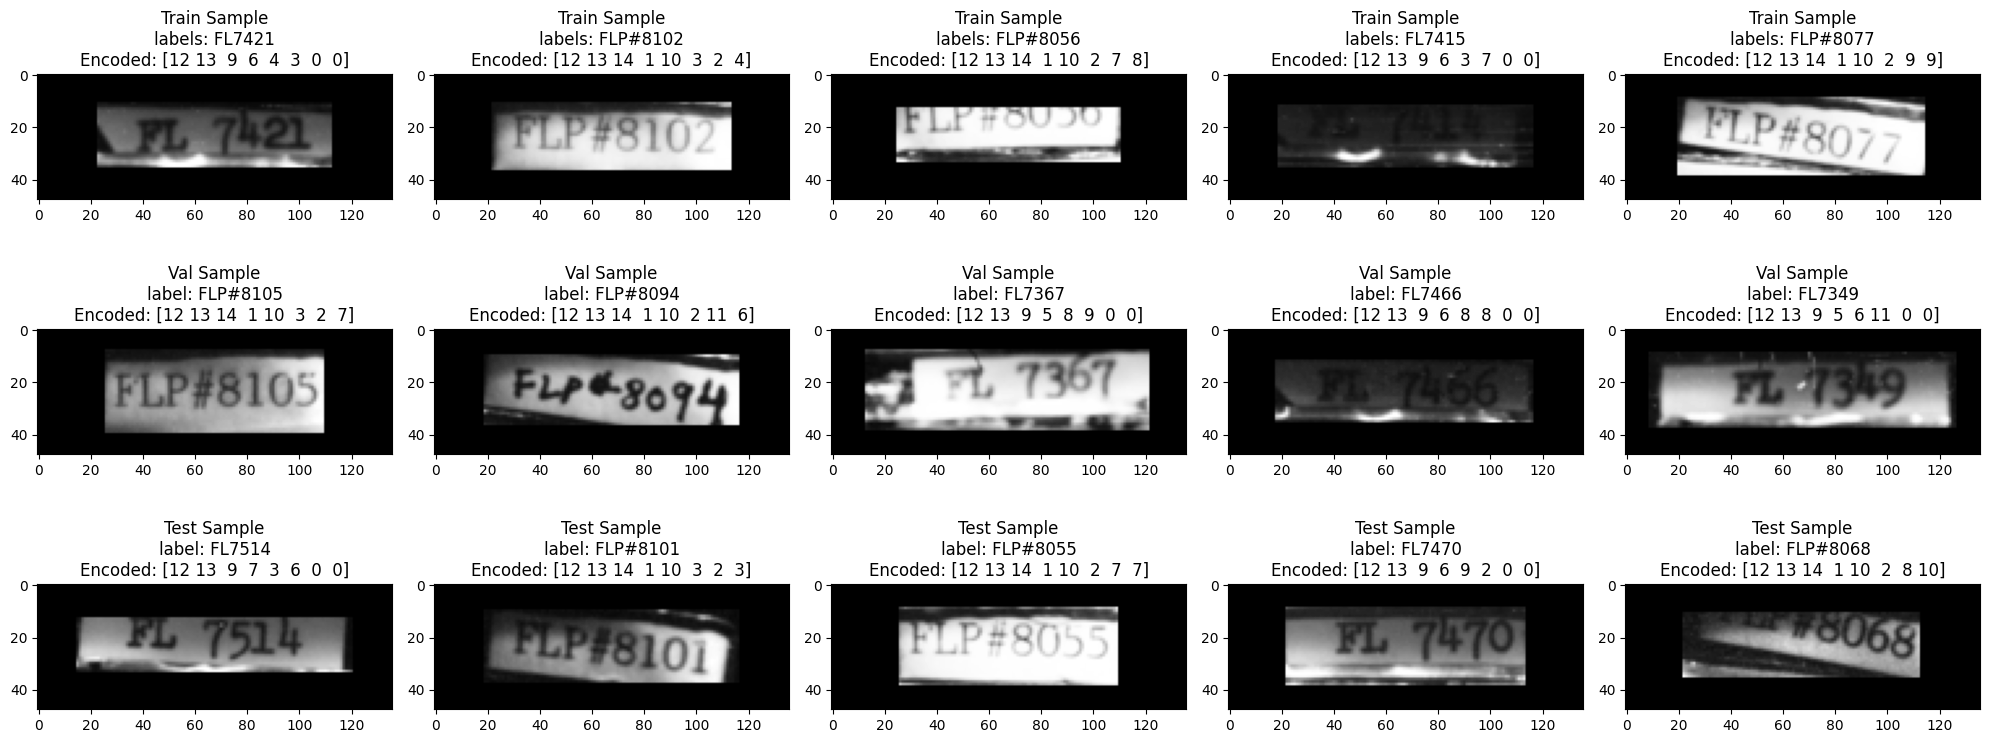


===== Training basic CRNN model =====
Using device: cuda
Selected model type: crnn
Maximum image dimensions - Height: 48, Width: 136
Character set size: 14
Maximum label length: 8
Character set:  ['#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'F', 'L', 'P']
Total model parameters: 2,298,063
Epoch 1/150 - time: 26.31s - LR: 0.050000 - train loss: 2.9001 - val loss: 5.3935 - train char acc: 0.2295 - val char acc: 0.1458
Saved best model, validation loss: 5.3935, character accuracy: 0.1458
Epoch 2/150 - time: 4.50s - LR: 0.050000 - train loss: 2.5915 - val loss: 2.1987 - train char acc: 0.1978 - val char acc: 0.2910
Saved best model, validation loss: 2.1987, character accuracy: 0.2910
Epoch 3/150 - time: 4.40s - LR: 0.050000 - train loss: 2.9737 - val loss: 2.6493 - train char acc: 0.2538 - val char acc: 0.1458
EarlyStopping counter: 1 / 30
Epoch 4/150 - time: 4.33s - LR: 0.050000 - train loss: 2.4928 - val loss: 2.9745 - train char acc: 0.2700 - val char acc: 0.2916
Epoch 5/150

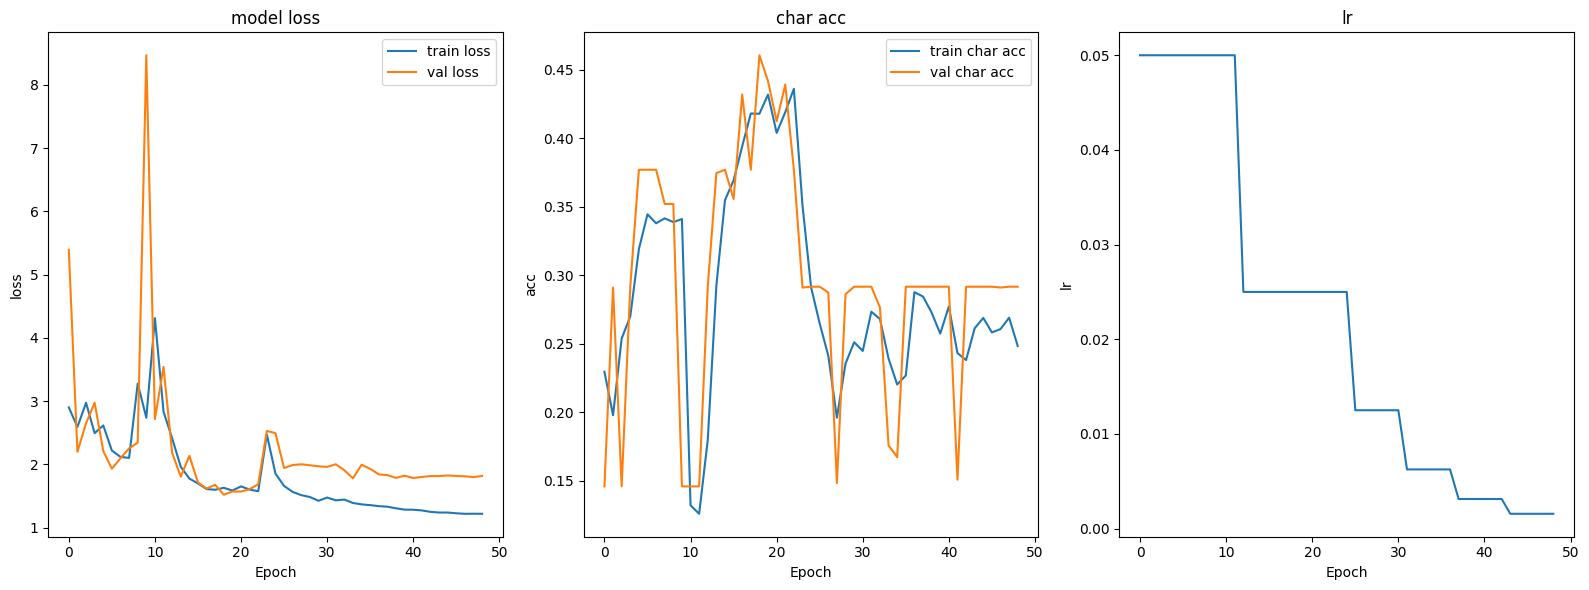


Evaluating crnn model:
Using greedy search to decode predictions...

Overall prediction accuracy: 0.00%
Character accuracy: 45.72%
Average edit distance: 3.79


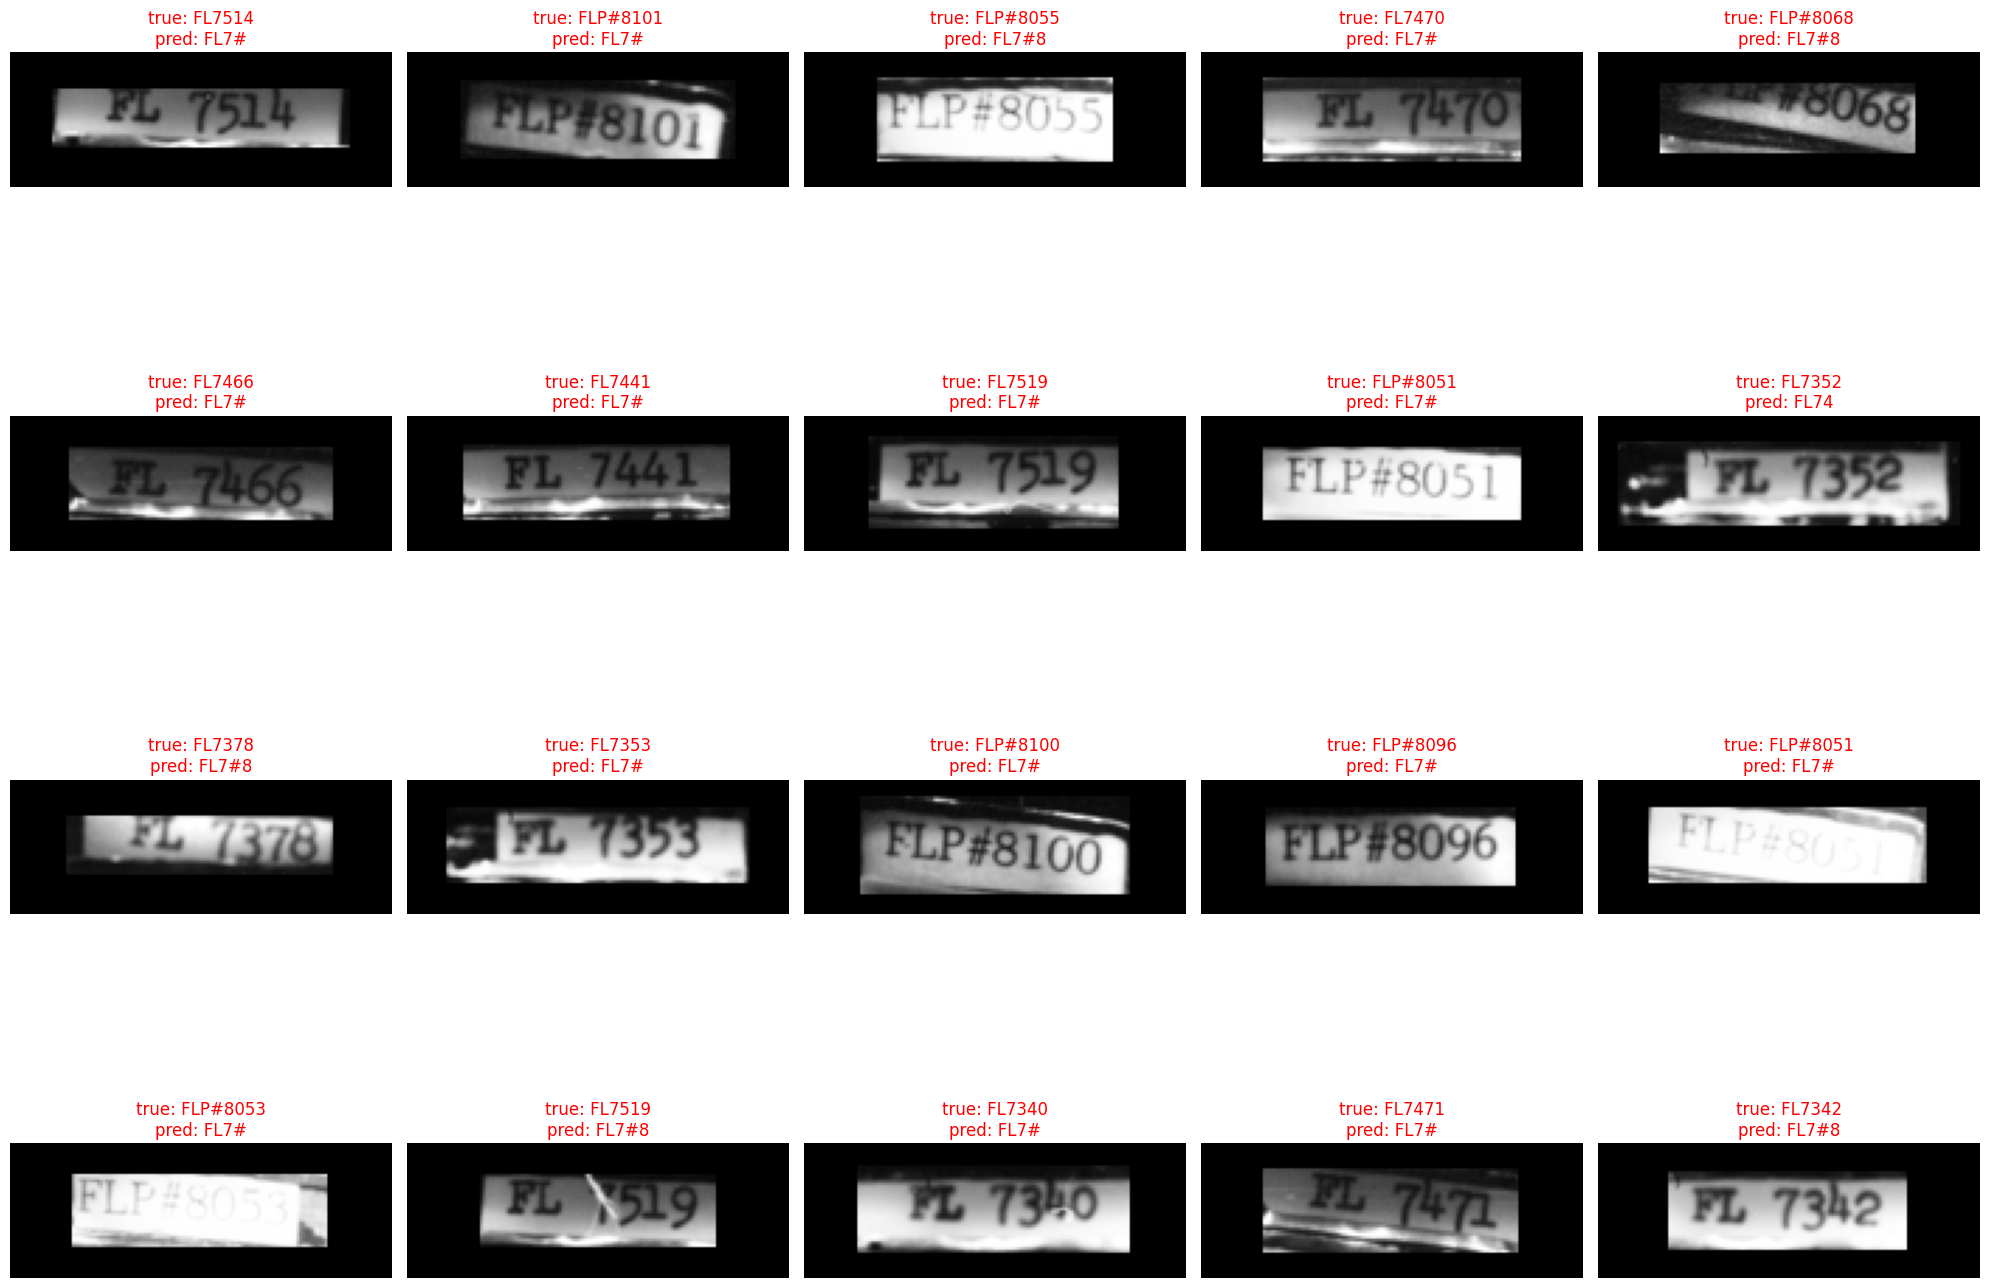


Training complete, final model saved to e:\pythonfile\main-task\read text\rell_number_crnn_models\rell_number_crnn_final_model.pt

===== Training CRNN model with attention mechanism =====
Using device: cuda
Selected model type: crnn_attention
Maximum image dimensions - Height: 48, Width: 136
Character set size: 14
Maximum label length: 8
Character set:  ['#', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'F', 'L', 'P']
Total model parameters: 2,433,487
Epoch 1/150 - time: 5.80s - LR: 0.050000 - train loss: 4.9009 - val loss: 1.9516 - train char acc: 0.1395 - val char acc: 0.3771
Saved best model, validation loss: 1.9516, character accuracy: 0.3771
Epoch 2/150 - time: 5.09s - LR: 0.050000 - train loss: 2.3398 - val loss: 2.3540 - train char acc: 0.3510 - val char acc: 0.3771
EarlyStopping counter: 1 / 30
Epoch 3/150 - time: 5.24s - LR: 0.050000 - train loss: 2.2959 - val loss: 2.1908 - train char acc: 0.3636 - val char acc: 0.3771
EarlyStopping counter: 2 / 30
Epoch 4/150 - time: 4

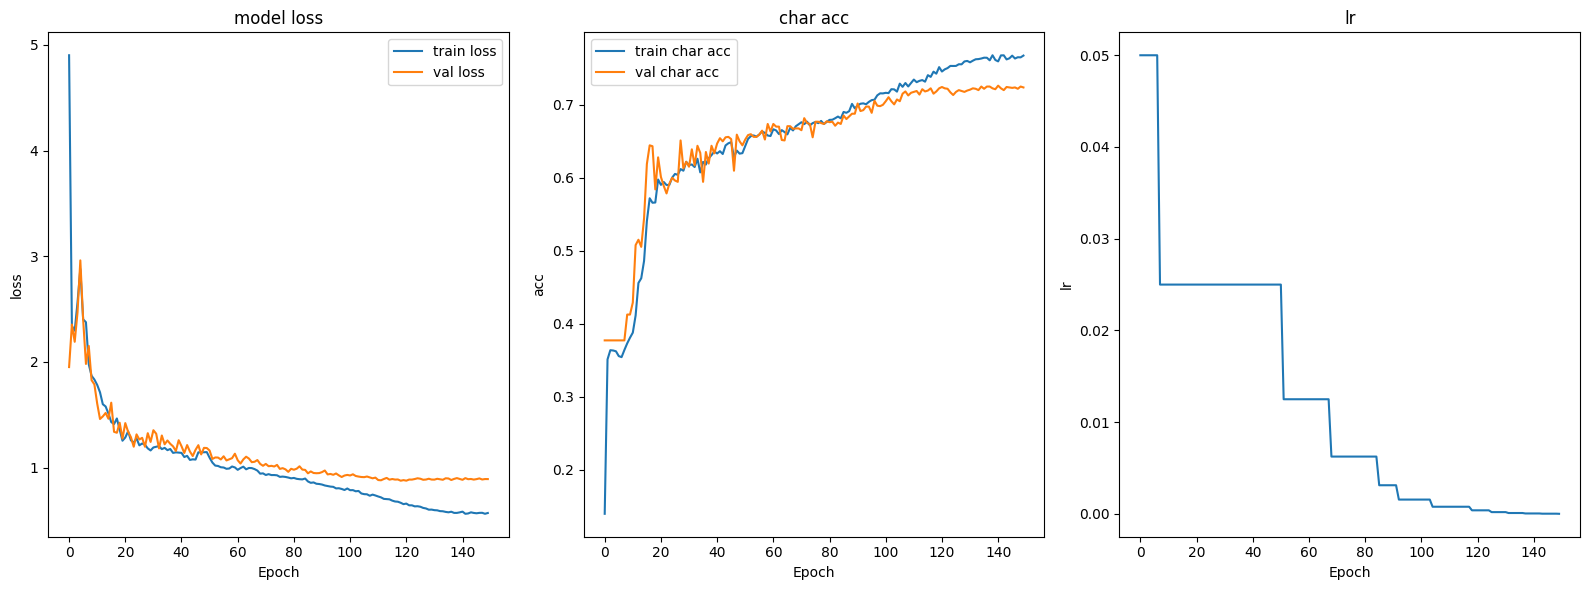


Evaluating crnn_attention model:
Using greedy search to decode predictions...

Overall prediction accuracy: 5.83%
Character accuracy: 74.35%
Average edit distance: 1.70


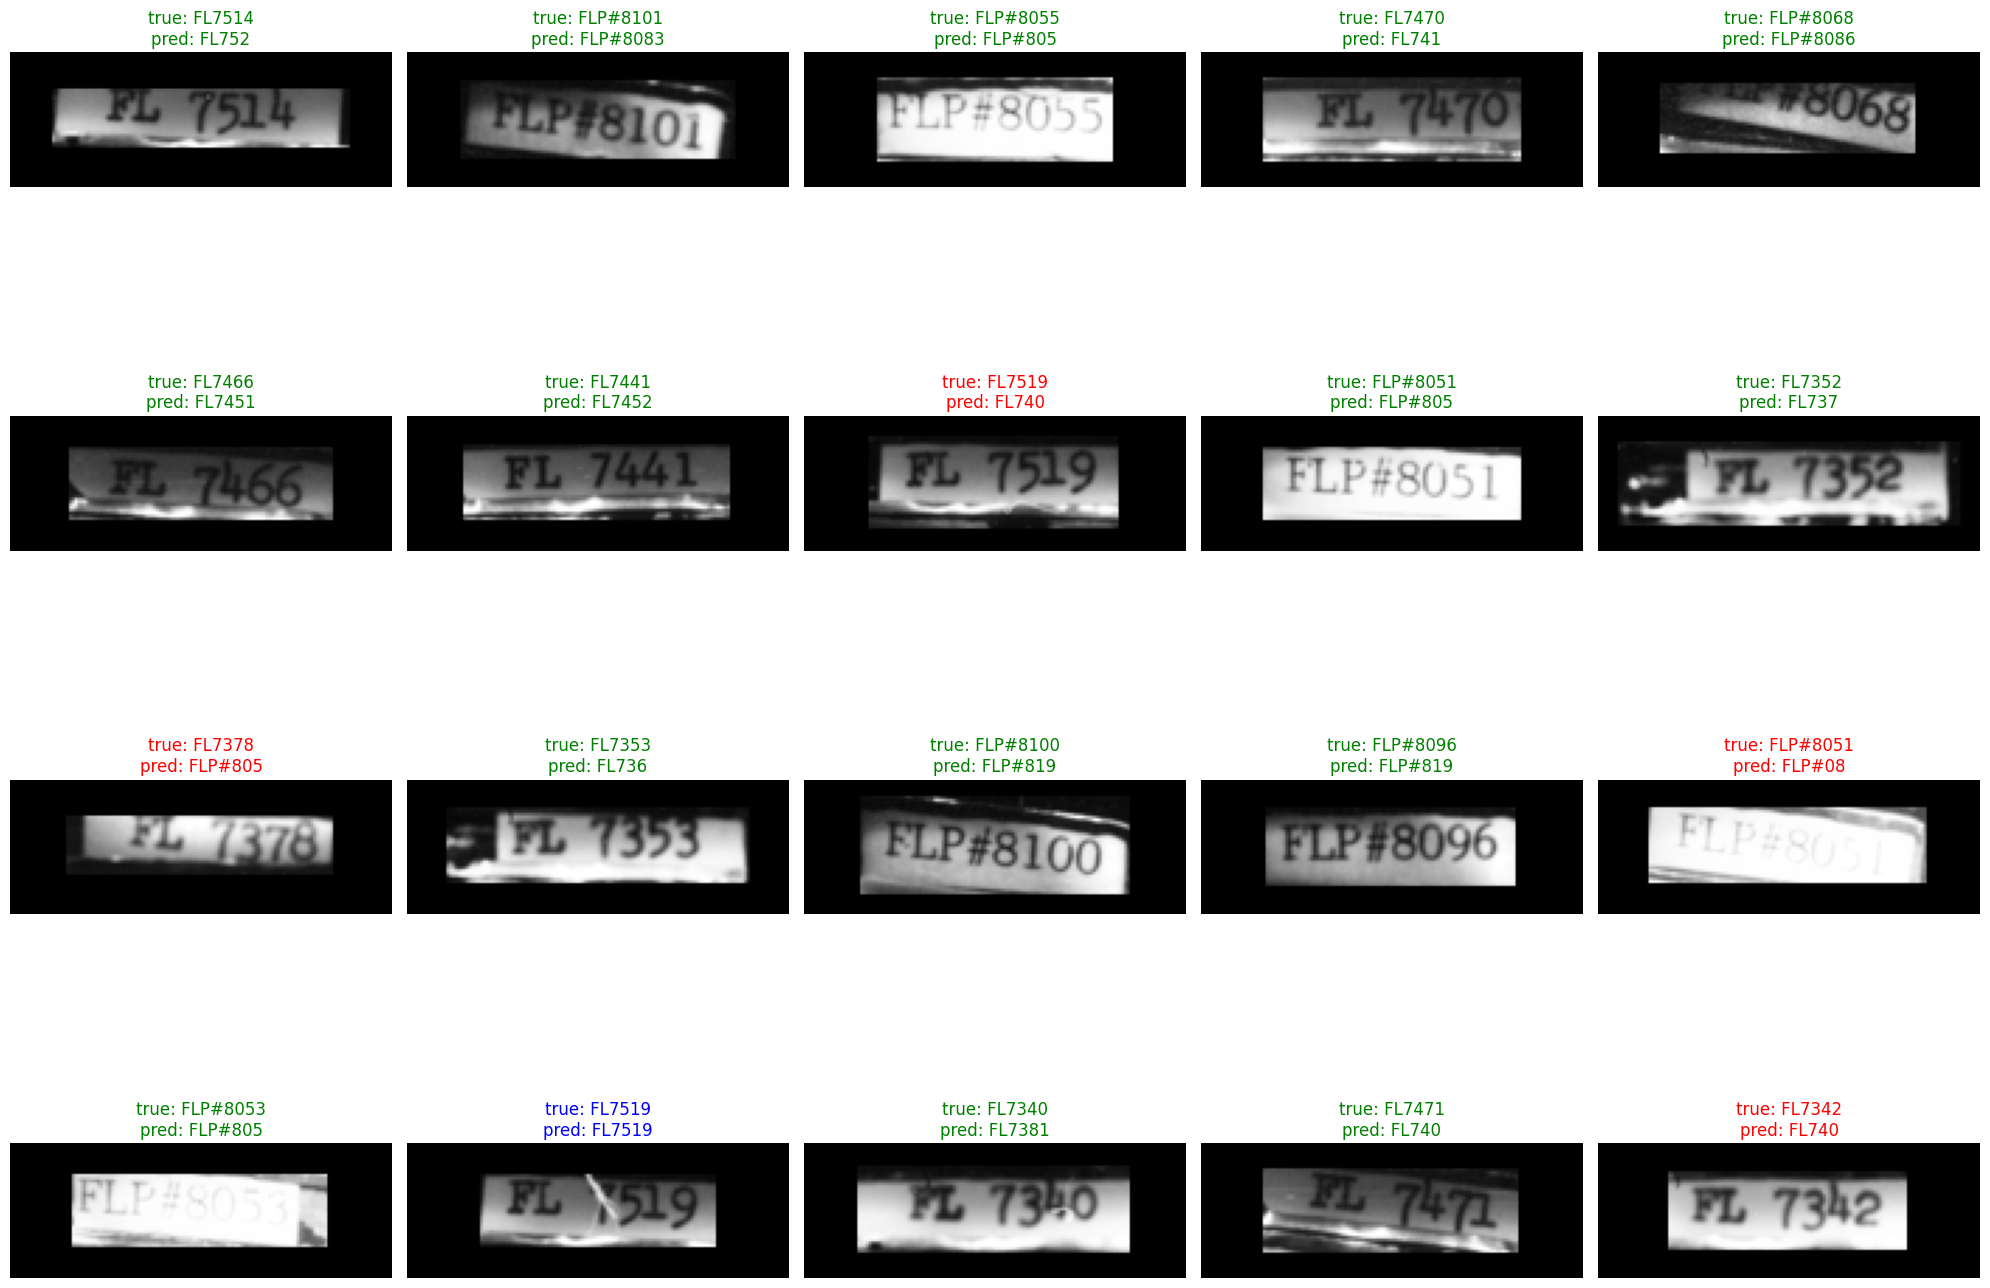


Training complete, final model saved to e:\pythonfile\main-task\read text\rell_number_crnn_attention_models\rell_number_crnn_attention_final_model.pt

===== Model comparison =====
Basic CRNN model accuracy: 0.0000
CRNN model with attention mechanism accuracy: 0.0583
Accuracy difference: 0.0583

Basic CRNN model character accuracy: 0.4572
CRNN model with attention mechanism character accuracy: 0.7435
Character accuracy difference: 0.2862


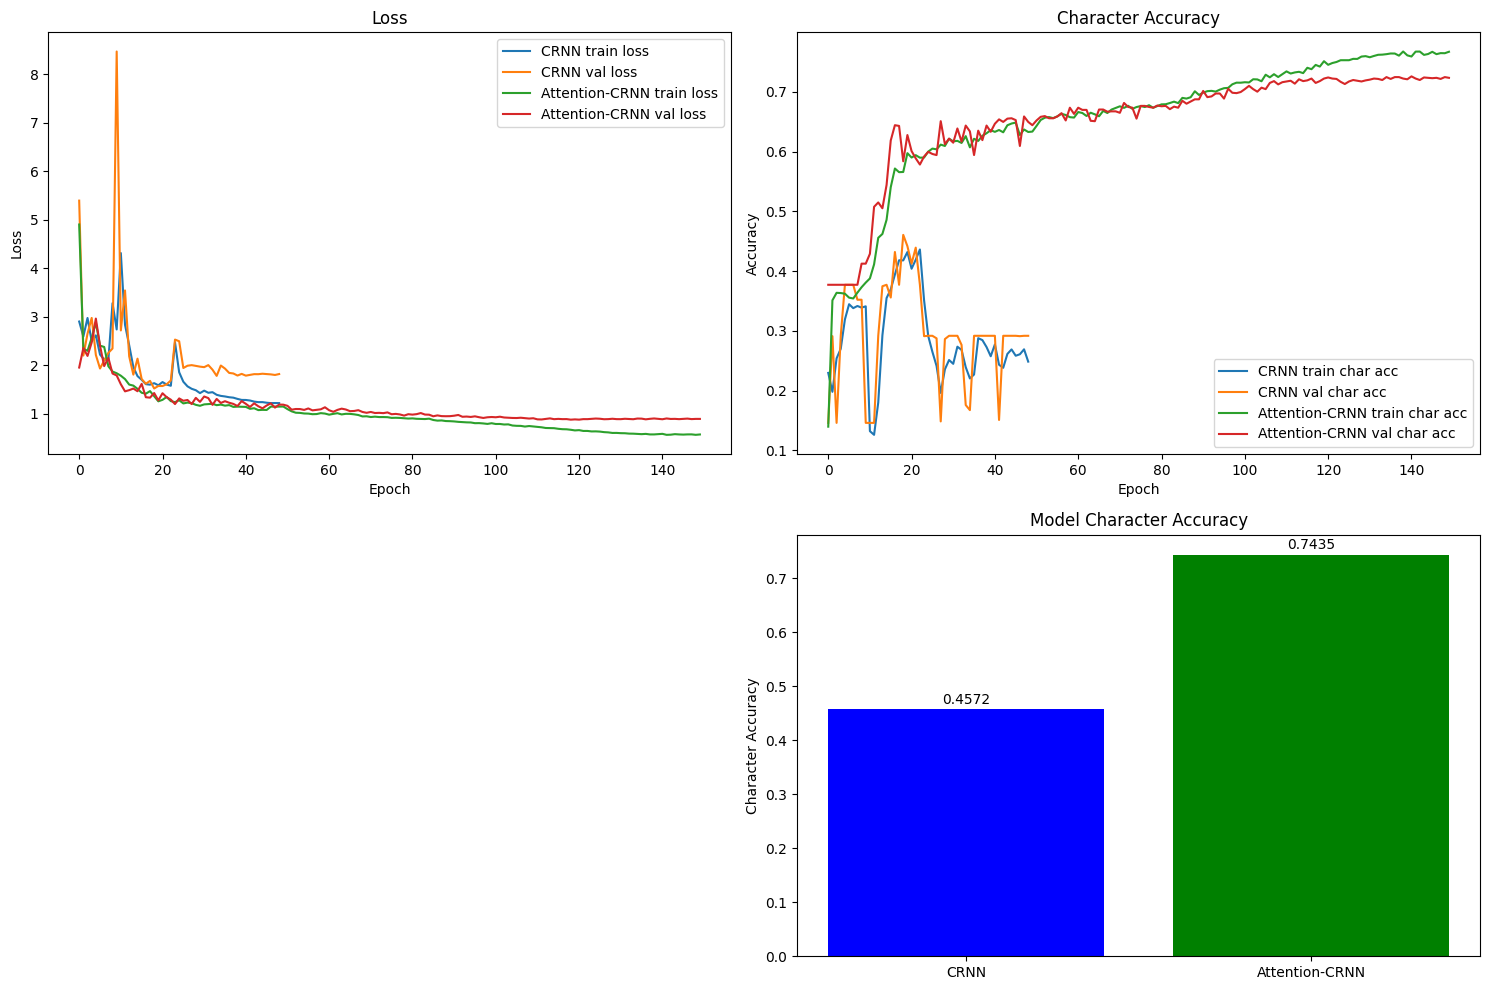

In [5]:
file_path = 'E:/pythonfile/main-task/'
data_name = ['rell_number', 'date', 'hour', 'minute', 'seconds']
seed = 42
n = 0
rell_numbe_df = data_process(data_name[n])
data_splits = data_main(rell_numbe_df)
parameter = 150, 4, 0.05#100, 16, 0.0015  # epochs, batch_size, learning_rate
rell_numbe_results = train_and_compare_models(rell_numbe_df, parameter, data_name[n], seed=seed)


Processing completed: 1171 successful, 0 failed
Maximum image dimensions - Height: 64, Width: 136
Character set size: 38
Maximum label length: 11
Character set:  [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'F', 'J', 'M', 'N', 'O', 'P', 'R', 'S', 'U', 'Y', 'a', 'b', 'c', 'e', 'g', 'l', 'm', 'n', 'o', 'p', 'r', 't', 'u', 'v', 'y']
Training set size: 819
Validation set size: 235
Test set size: 117
Image shape: (64, 136)
Label shape: (11,)


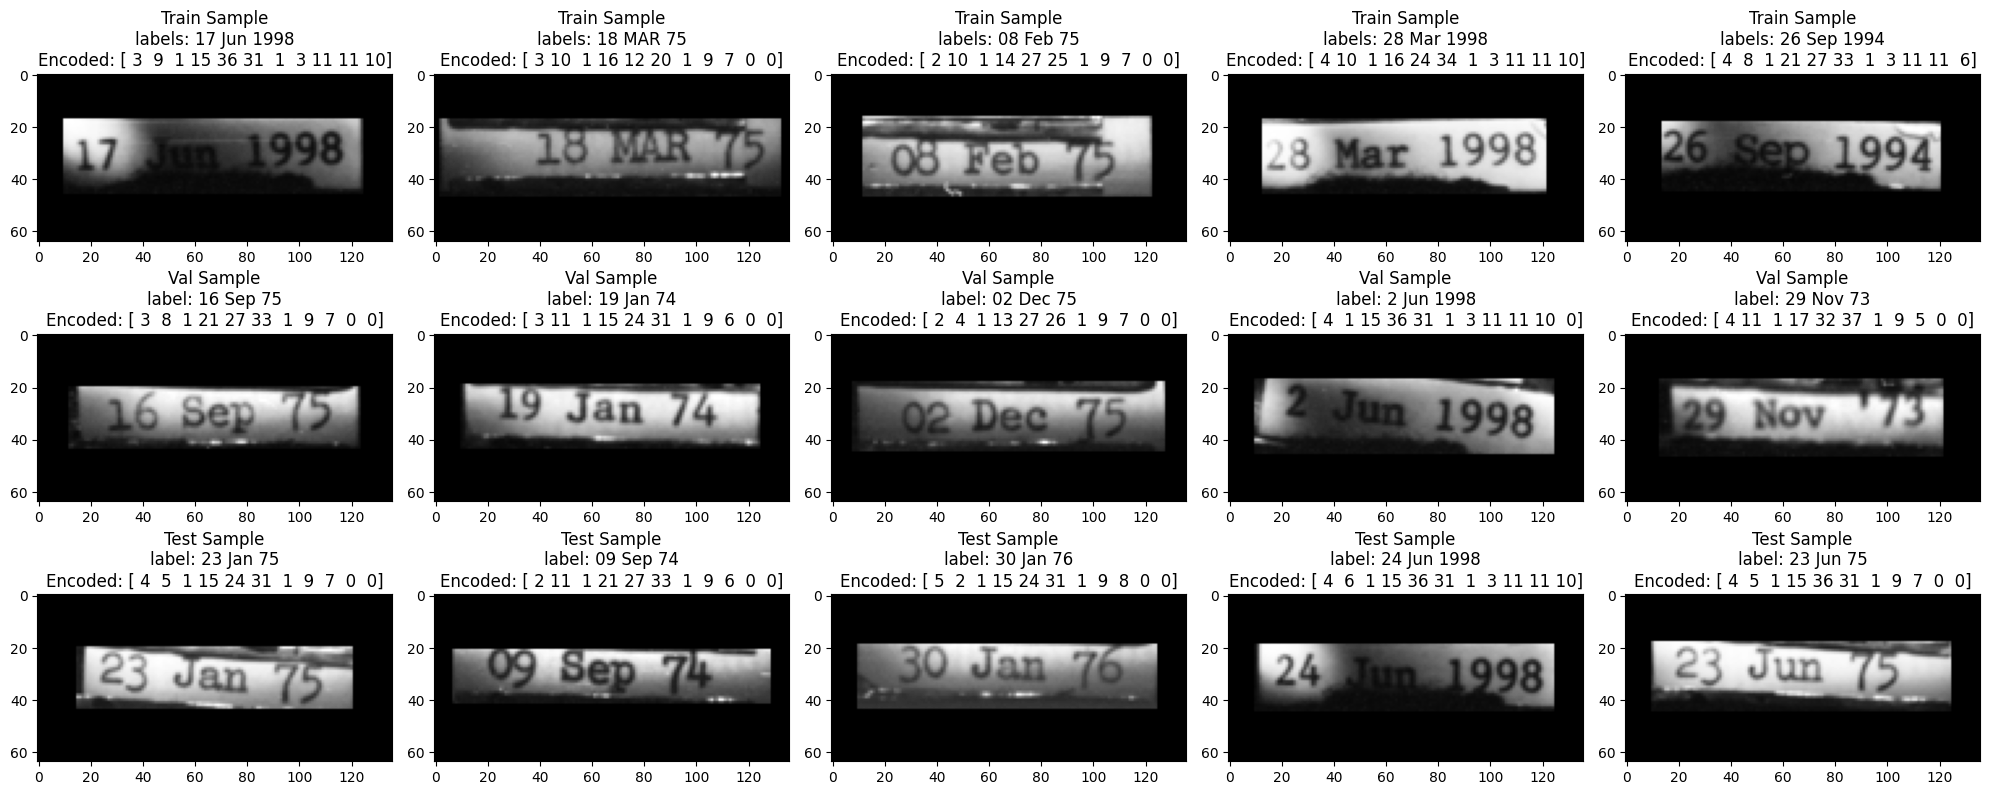


===== Training basic CRNN model =====
Using device: cuda
Selected model type: crnn
Maximum image dimensions - Height: 64, Width: 136
Character set size: 38
Maximum label length: 11
Character set:  [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'F', 'J', 'M', 'N', 'O', 'P', 'R', 'S', 'U', 'Y', 'a', 'b', 'c', 'e', 'g', 'l', 'm', 'n', 'o', 'p', 'r', 't', 'u', 'v', 'y']
Total model parameters: 2,566,375
Epoch 1/150 - time: 2.43s - LR: 0.002000 - train loss: 3.0059 - val loss: 2.2747 - train char acc: 0.0143 - val char acc: 0.0606
Saved best model, validation loss: 2.2747, character accuracy: 0.0606
Epoch 2/150 - time: 2.11s - LR: 0.002000 - train loss: 1.9996 - val loss: 1.8889 - train char acc: 0.1147 - val char acc: 0.1311
Saved best model, validation loss: 1.8889, character accuracy: 0.1311
Epoch 3/150 - time: 2.31s - LR: 0.002000 - train loss: 1.6101 - val loss: 1.4496 - train char acc: 0.1376 - val char acc: 0.1422
Saved best model, validation loss: 1.4496, charact

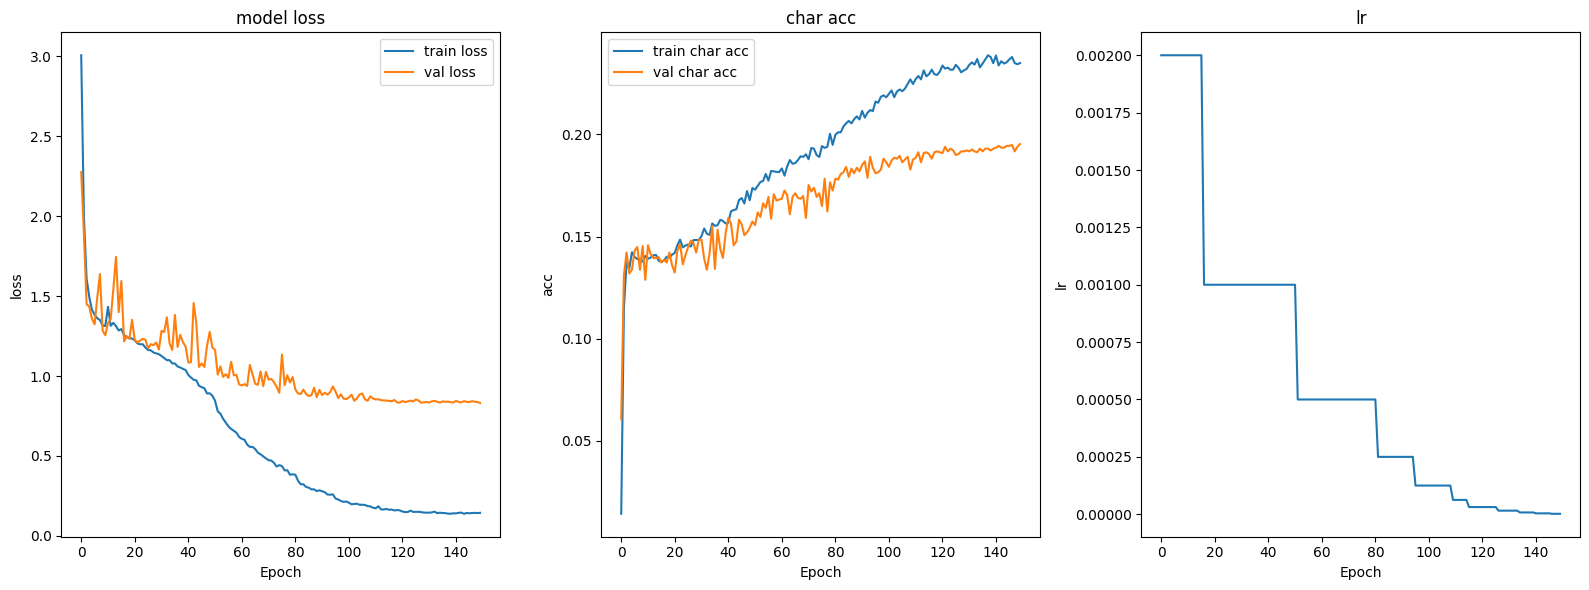


Evaluating crnn model:
Using greedy search to decode predictions...

Overall prediction accuracy: 11.11%
Character accuracy: 62.07%
Average edit distance: 2.19


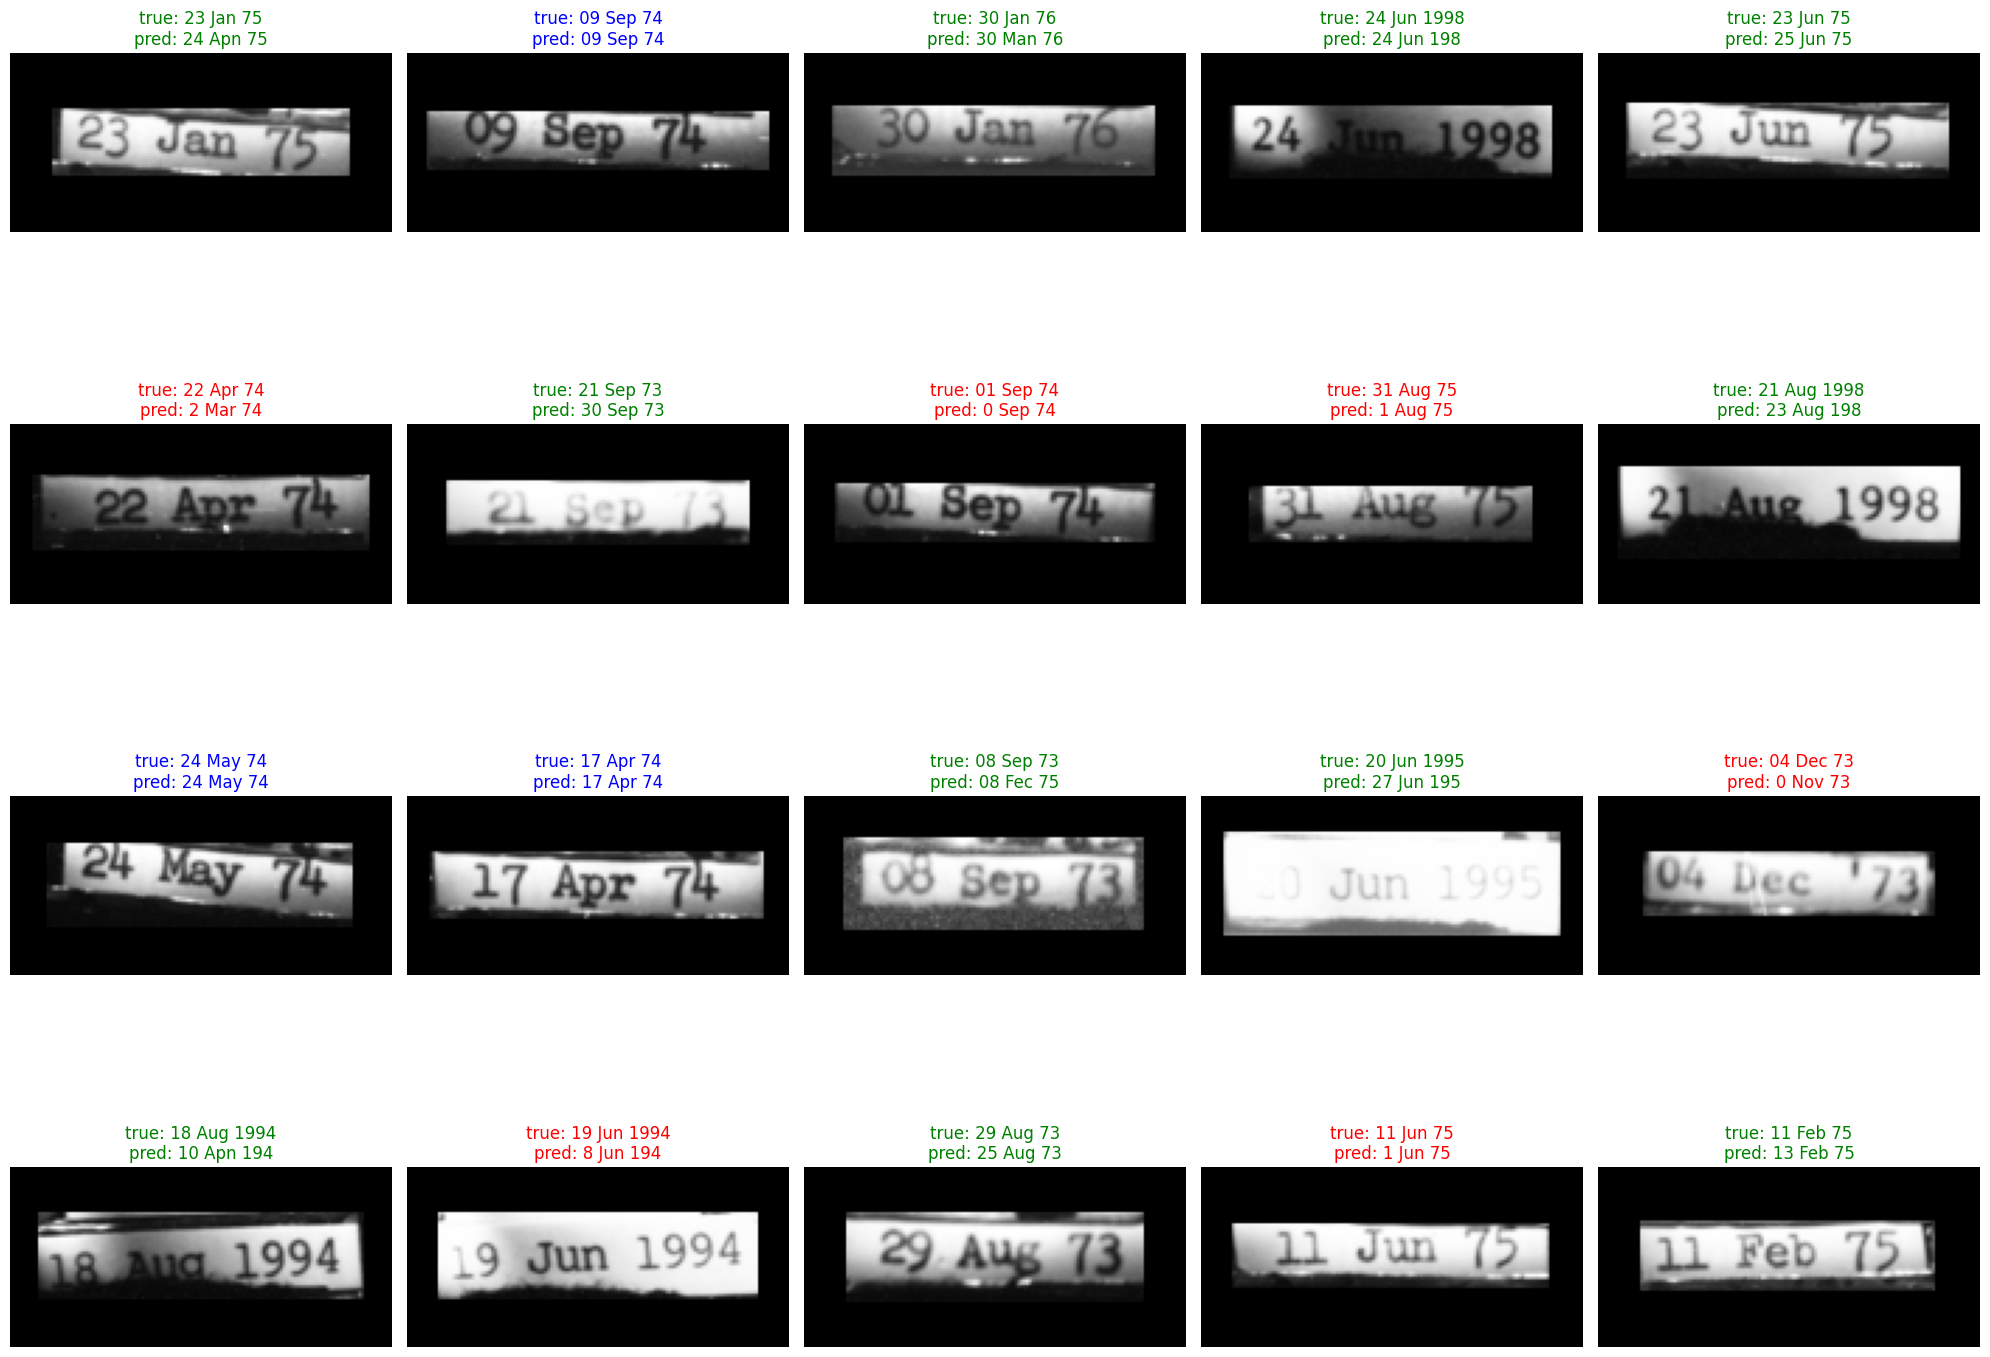


Training complete, final model saved to e:\pythonfile\main-task\read text\date_crnn_models\date_crnn_final_model.pt

===== Training CRNN model with attention mechanism =====
Using device: cuda
Selected model type: crnn_attention
Maximum image dimensions - Height: 64, Width: 136
Character set size: 38
Maximum label length: 11
Character set:  [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'F', 'J', 'M', 'N', 'O', 'P', 'R', 'S', 'U', 'Y', 'a', 'b', 'c', 'e', 'g', 'l', 'm', 'n', 'o', 'p', 'r', 't', 'u', 'v', 'y']
Total model parameters: 2,707,943
Epoch 1/150 - time: 2.44s - LR: 0.002000 - train loss: 3.1350 - val loss: 2.4684 - train char acc: 0.0119 - val char acc: 0.0294
Saved best model, validation loss: 2.4684, character accuracy: 0.0294
Epoch 2/150 - time: 2.43s - LR: 0.002000 - train loss: 1.9356 - val loss: 1.6907 - train char acc: 0.1220 - val char acc: 0.1382
Saved best model, validation loss: 1.6907, character accuracy: 0.1382
Epoch 3/150 - time: 2.37s - LR: 0

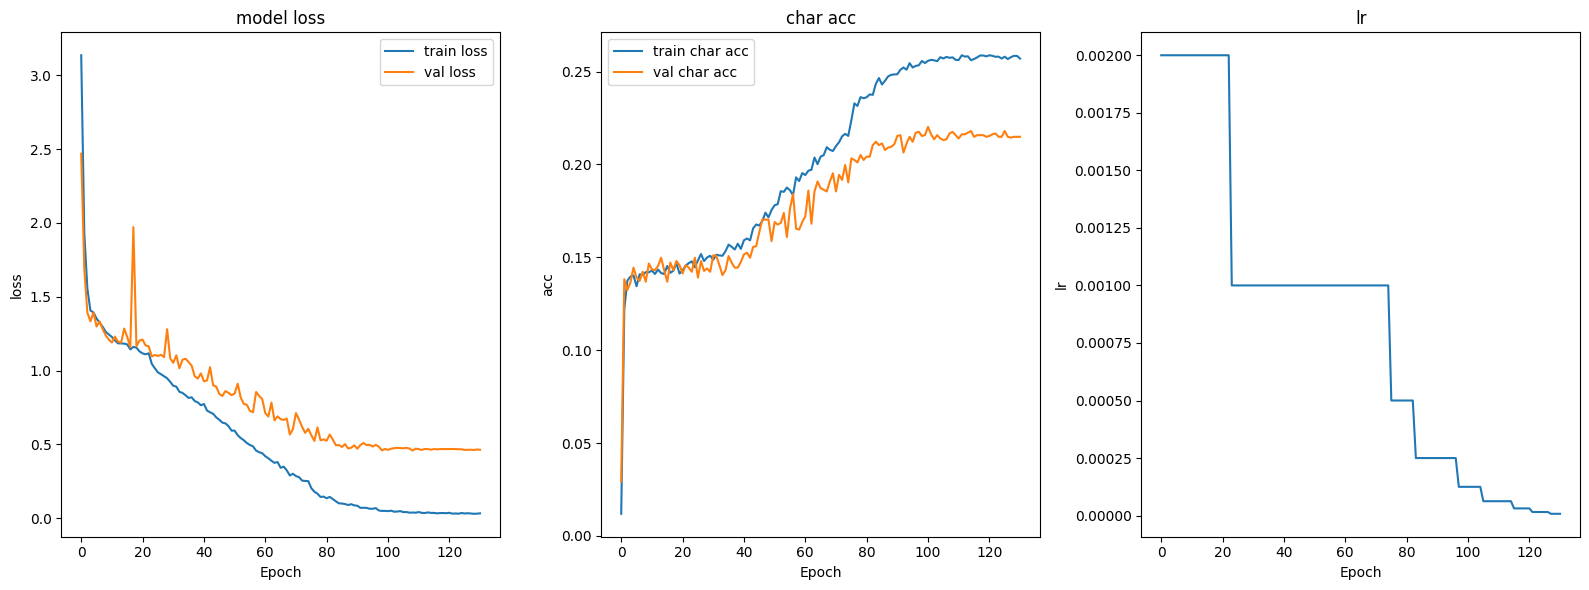


Evaluating crnn_attention model:
Using greedy search to decode predictions...

Overall prediction accuracy: 22.22%
Character accuracy: 71.26%
Average edit distance: 1.61


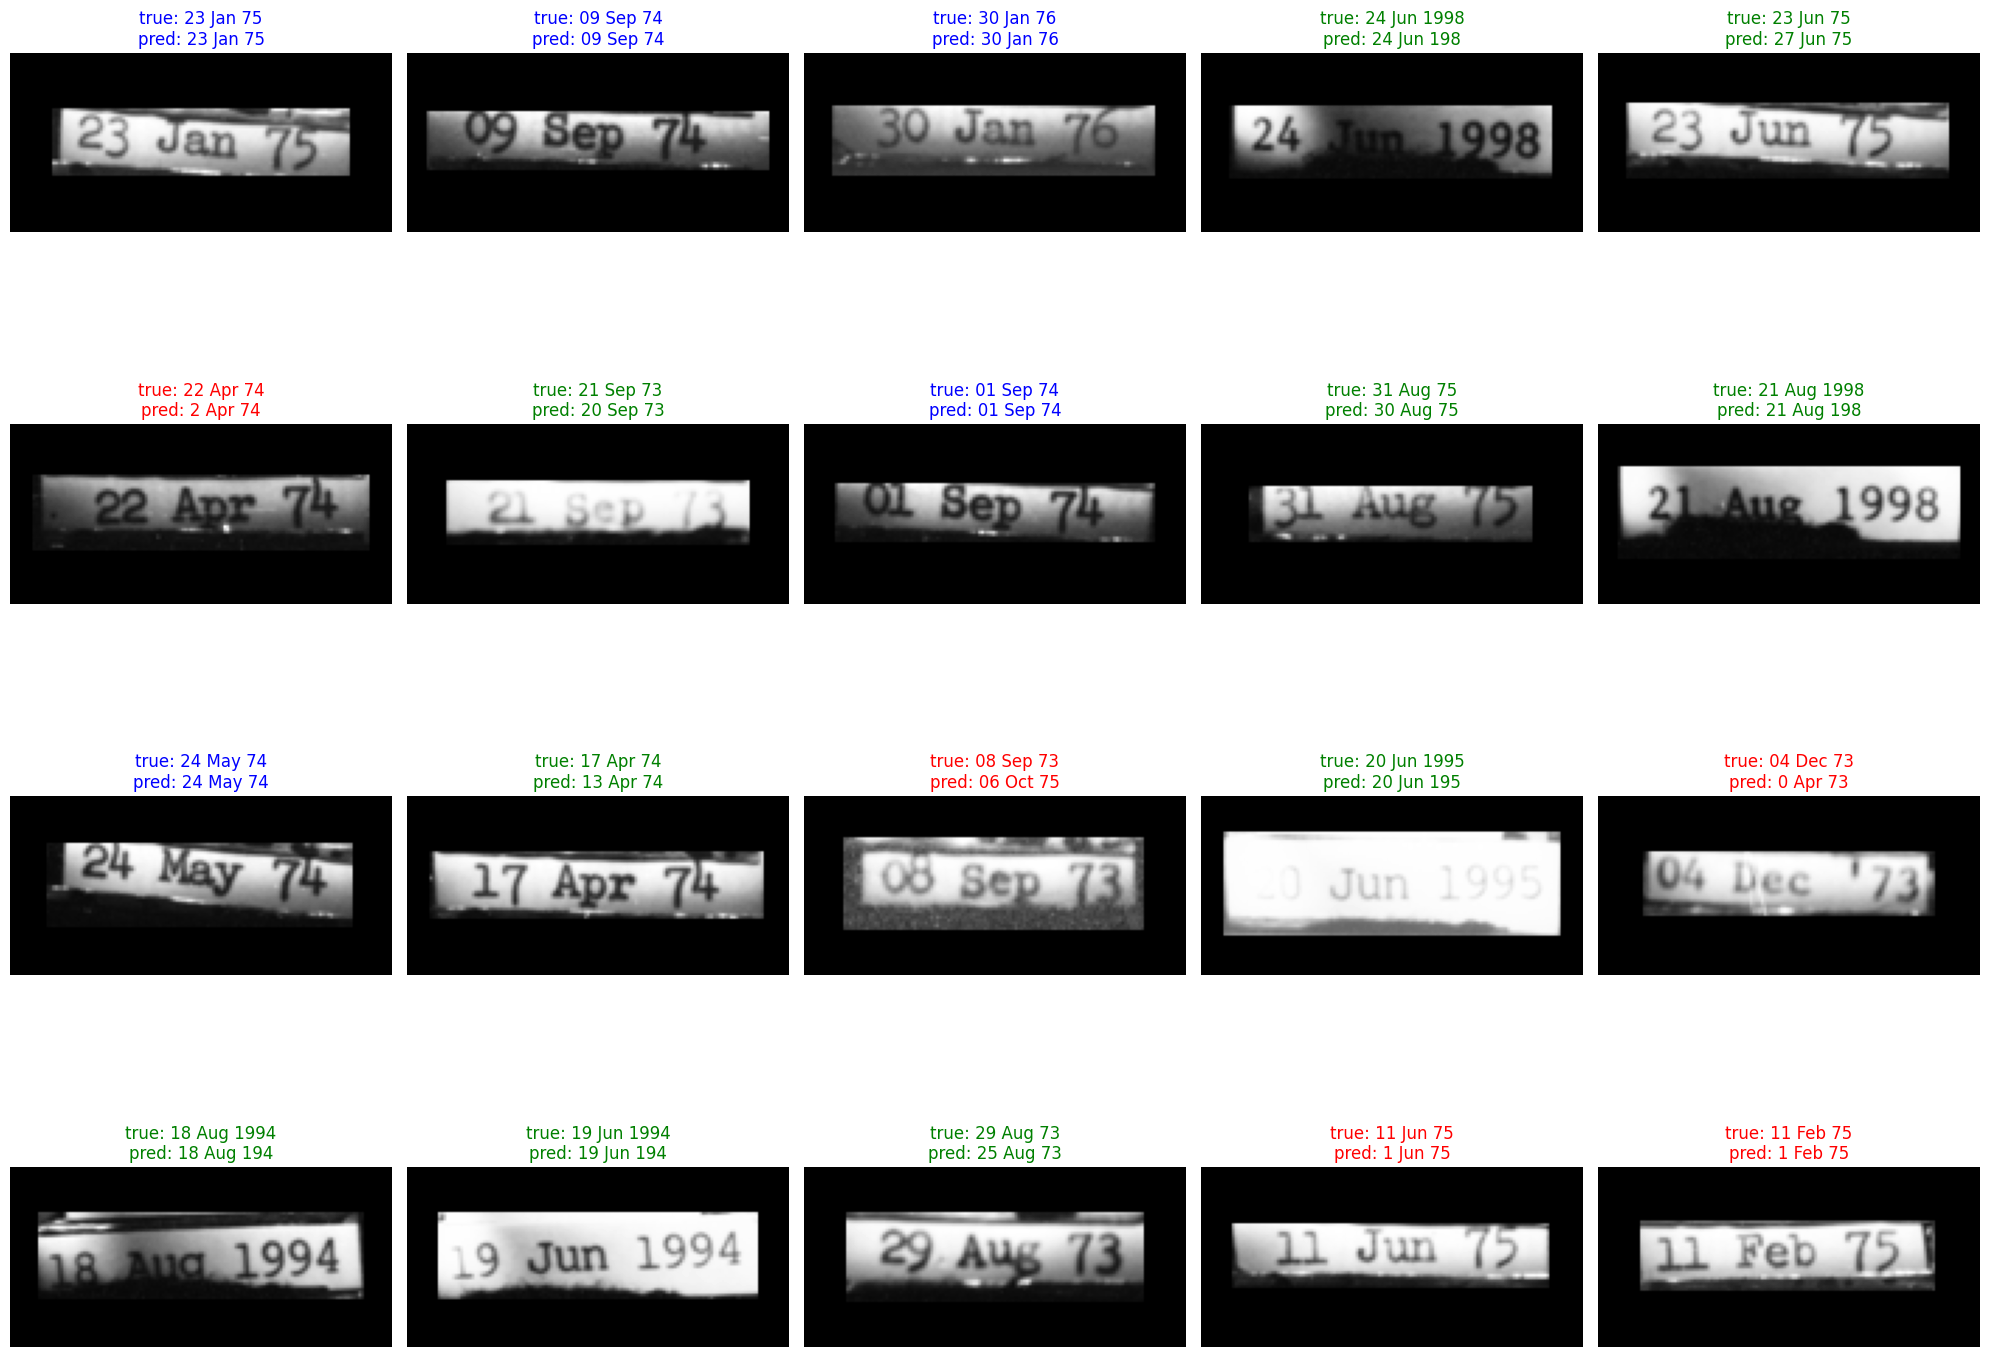


Training complete, final model saved to e:\pythonfile\main-task\read text\date_crnn_attention_models\date_crnn_attention_final_model.pt

===== Model comparison =====
Basic CRNN model accuracy: 0.1111
CRNN model with attention mechanism accuracy: 0.2222
Accuracy difference: 0.1111

Basic CRNN model character accuracy: 0.6207
CRNN model with attention mechanism character accuracy: 0.7126
Character accuracy difference: 0.0919


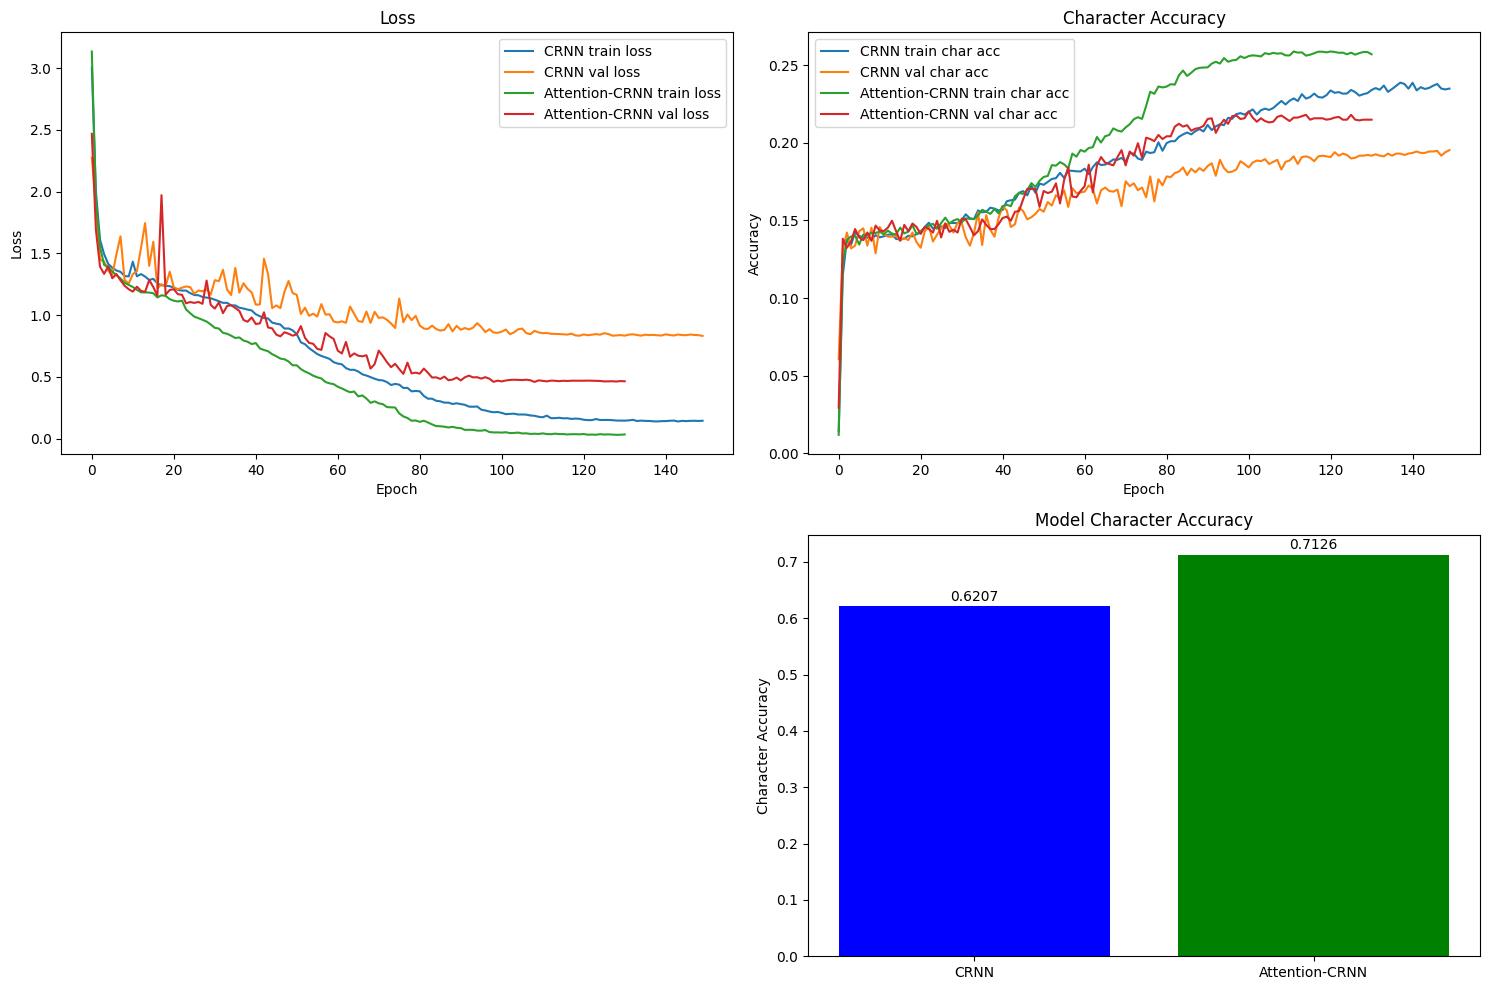

In [6]:
n = 1
date_df = data_process(data_name[n])
data_splits = data_main(date_df)
parameter = 150, 16, 0.002
date_df_results = train_and_compare_models(date_df, parameter, data_name[n], seed=seed)



Processing completed: 1371 successful, 22 failed
Maximum image dimensions - Height: 80, Width: 120
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training set size: 959
Validation set size: 275
Test set size: 137
Image shape: (80, 120)
Label shape: (2,)


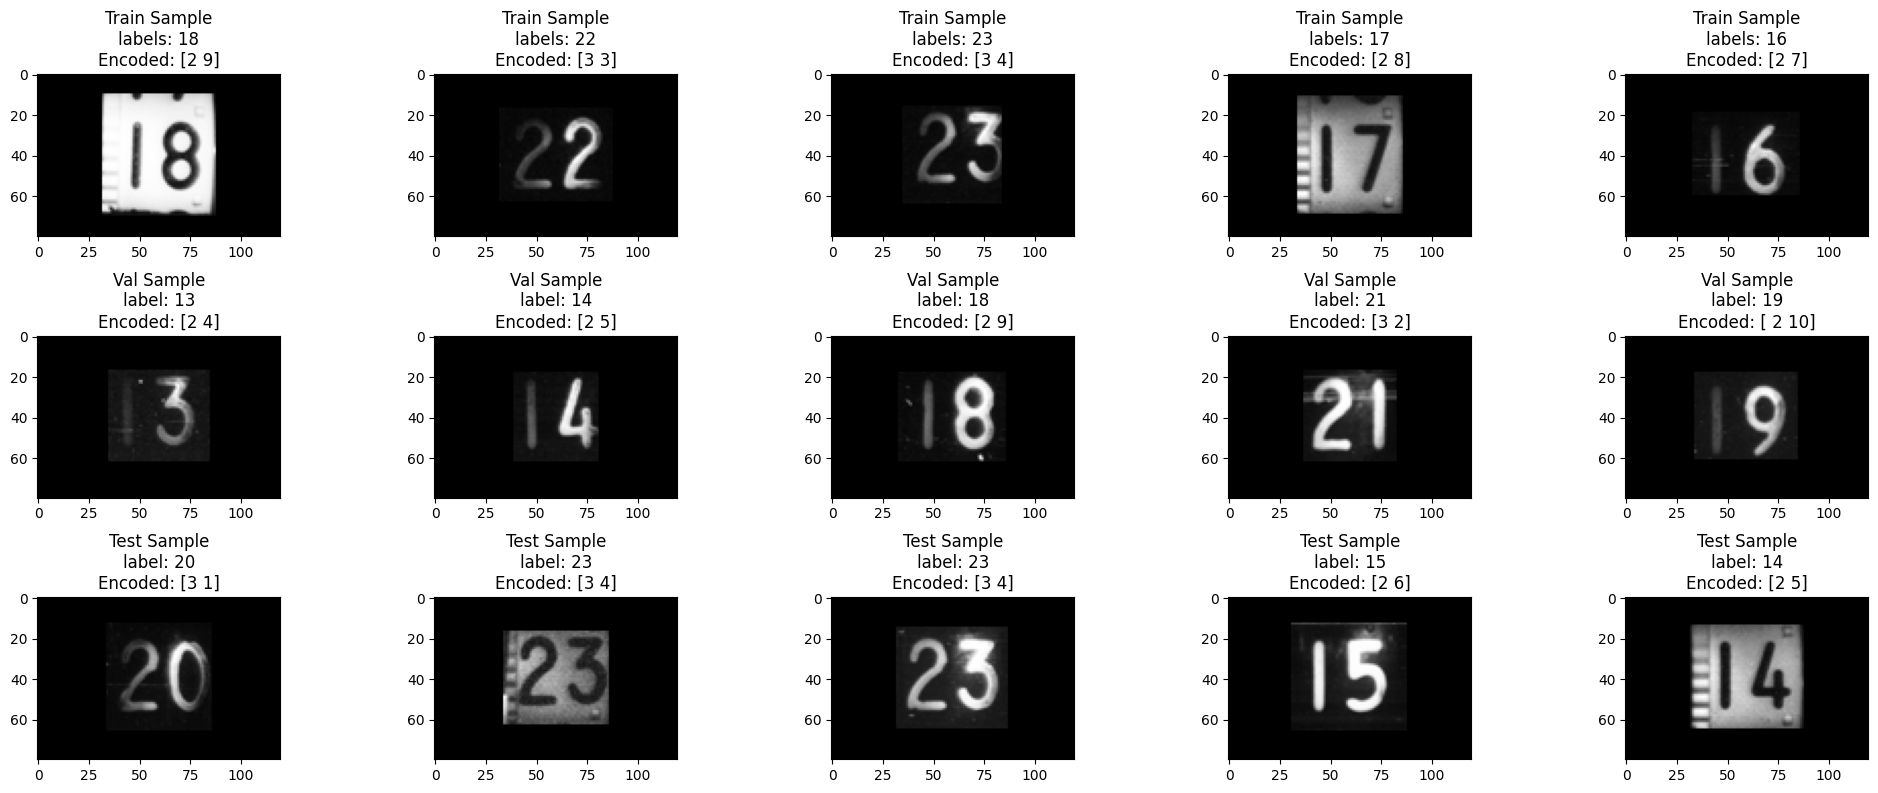


===== Training basic CRNN model =====
Using device: cuda
Selected model type: crnn
Maximum image dimensions - Height: 80, Width: 120
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total model parameters: 2,821,323
Epoch 1/100 - time: 2.43s - LR: 0.000100 - train loss: 12.4079 - val loss: 2.9164 - train char acc: 0.0104 - val char acc: 0.0000
Saved best model, validation loss: 2.9164, character accuracy: 0.0000
Epoch 2/100 - time: 2.39s - LR: 0.000100 - train loss: 2.4823 - val loss: 2.4049 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.4049, character accuracy: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/100 - time: 2.33s - LR: 0.000100 - train loss: 2.2104 - val loss: 2.1216 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.1216, character accuracy: 0.0000
EarlyStopping counter: 2 / 30
Epoch 4/100 - time: 2.40s - LR: 0.000100 - train loss: 1.974

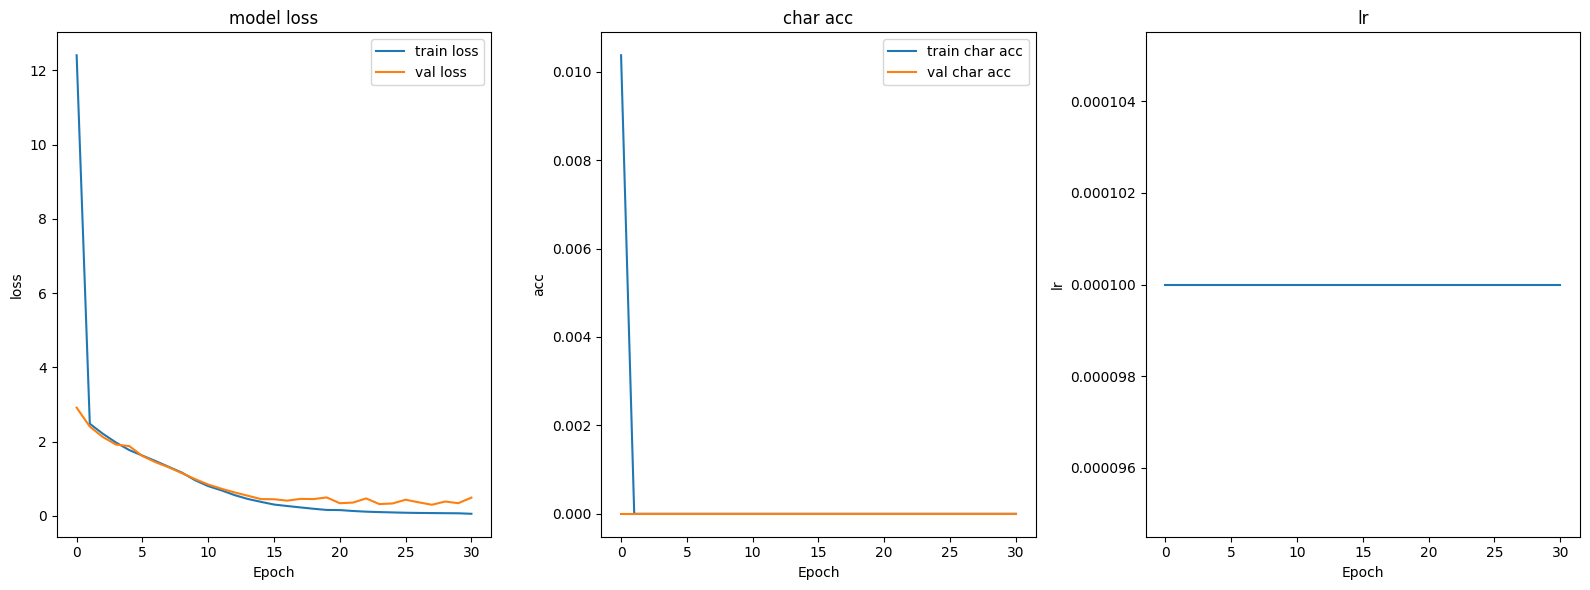


Evaluating crnn model:
Using greedy search to decode predictions...

Overall prediction accuracy: 80.29%
Character accuracy: 86.72%
Average edit distance: 0.22


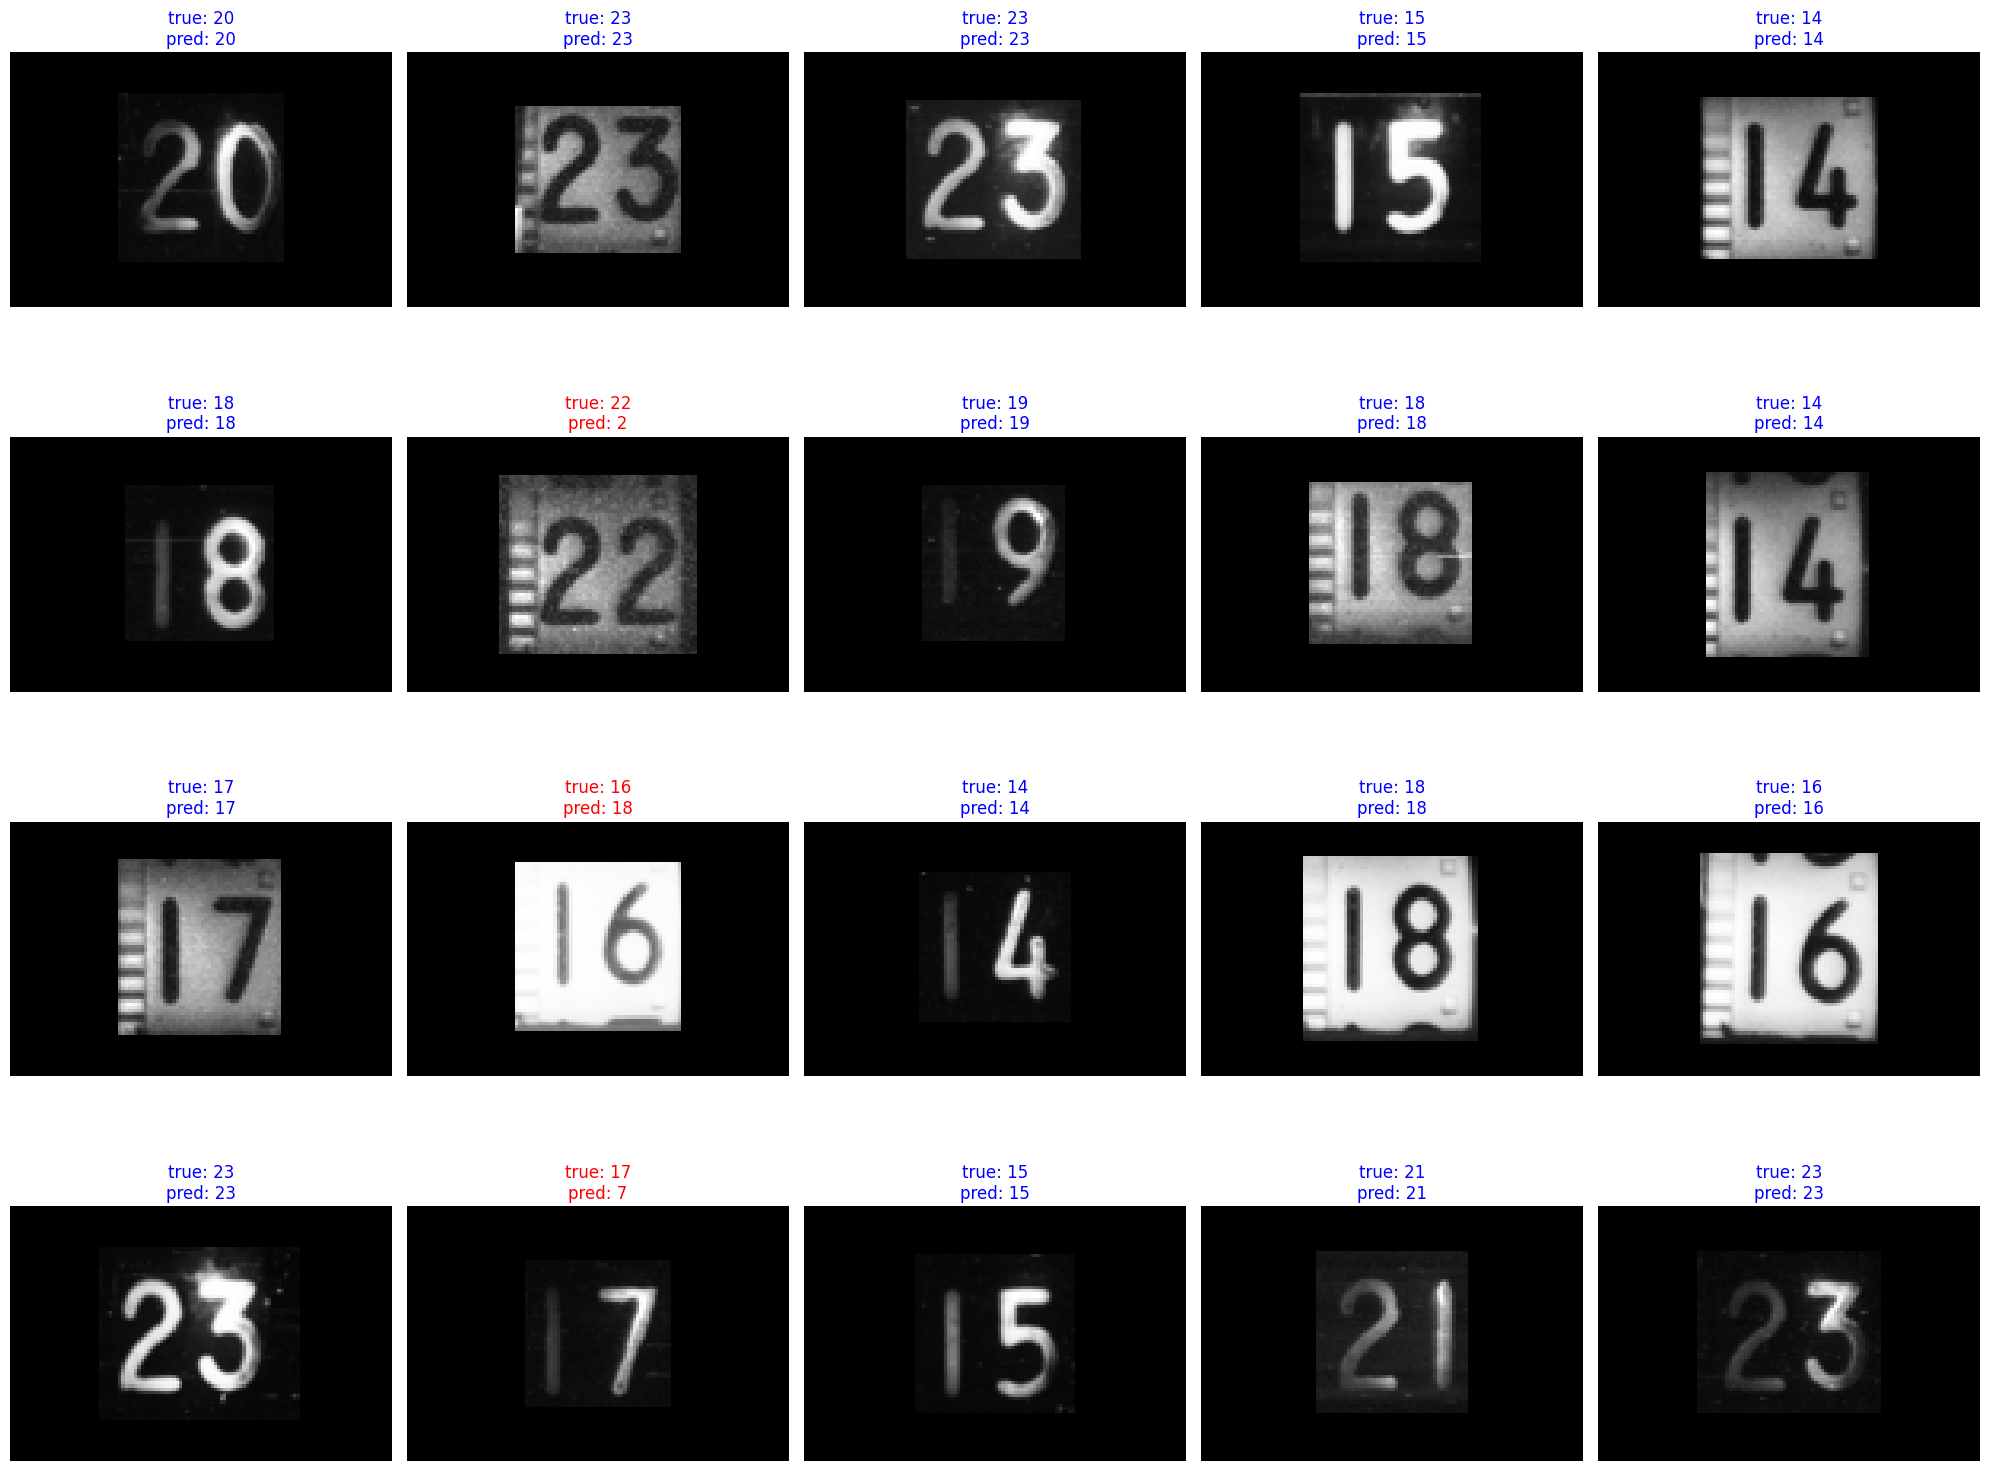


Training complete, final model saved to e:\pythonfile\main-task\read text\hour_crnn_models\hour_crnn_final_model.pt

===== Training CRNN model with attention mechanism =====
Using device: cuda
Selected model type: crnn_attention
Maximum image dimensions - Height: 80, Width: 120
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total model parameters: 2,955,723
Epoch 1/100 - time: 2.40s - LR: 0.000100 - train loss: 6.6069 - val loss: 2.6578 - train char acc: 0.0022 - val char acc: 0.0000
Saved best model, validation loss: 2.6578, character accuracy: 0.0000
Epoch 2/100 - time: 2.38s - LR: 0.000100 - train loss: 2.4931 - val loss: 2.5330 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.5330, character accuracy: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/100 - time: 2.44s - LR: 0.000100 - train loss: 2.2037 - val loss: 2.1909 - train char acc: 0.0000 - val char acc: 0.0000
Saved best mode

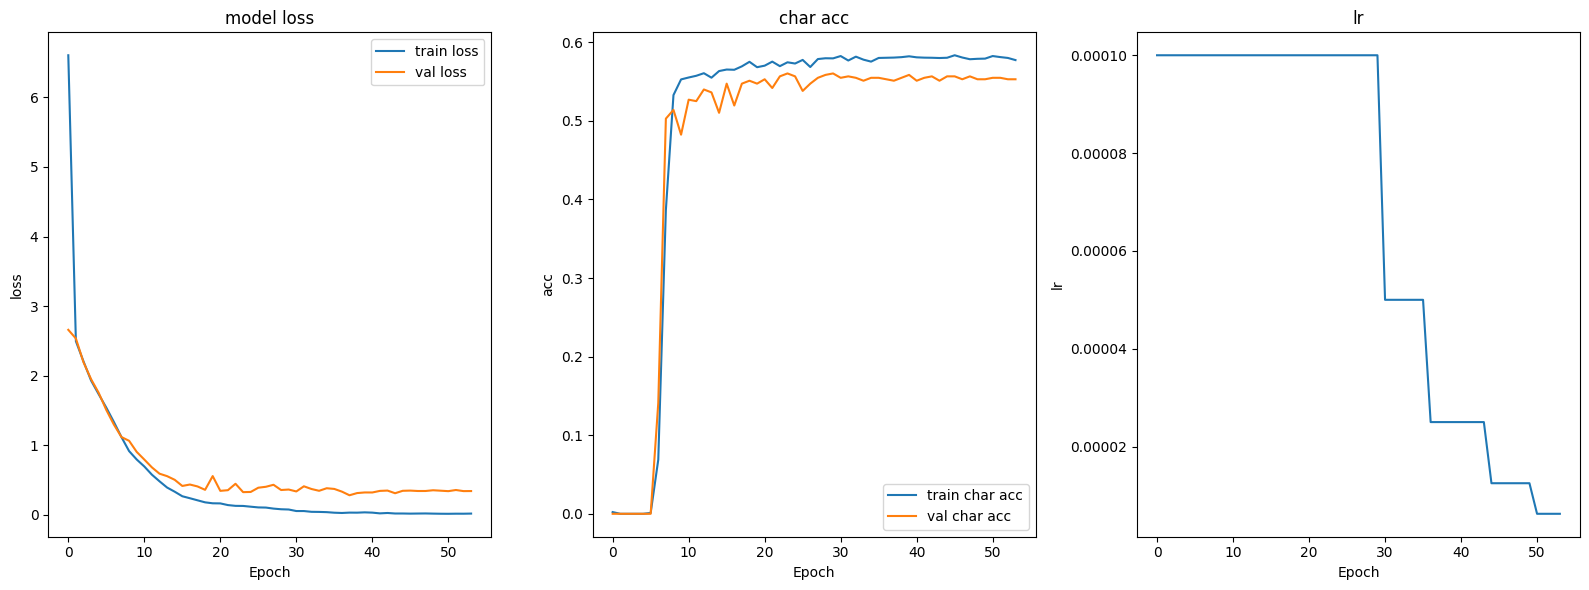


Evaluating crnn_attention model:
Using greedy search to decode predictions...

Overall prediction accuracy: 81.02%
Character accuracy: 87.45%
Average edit distance: 0.19


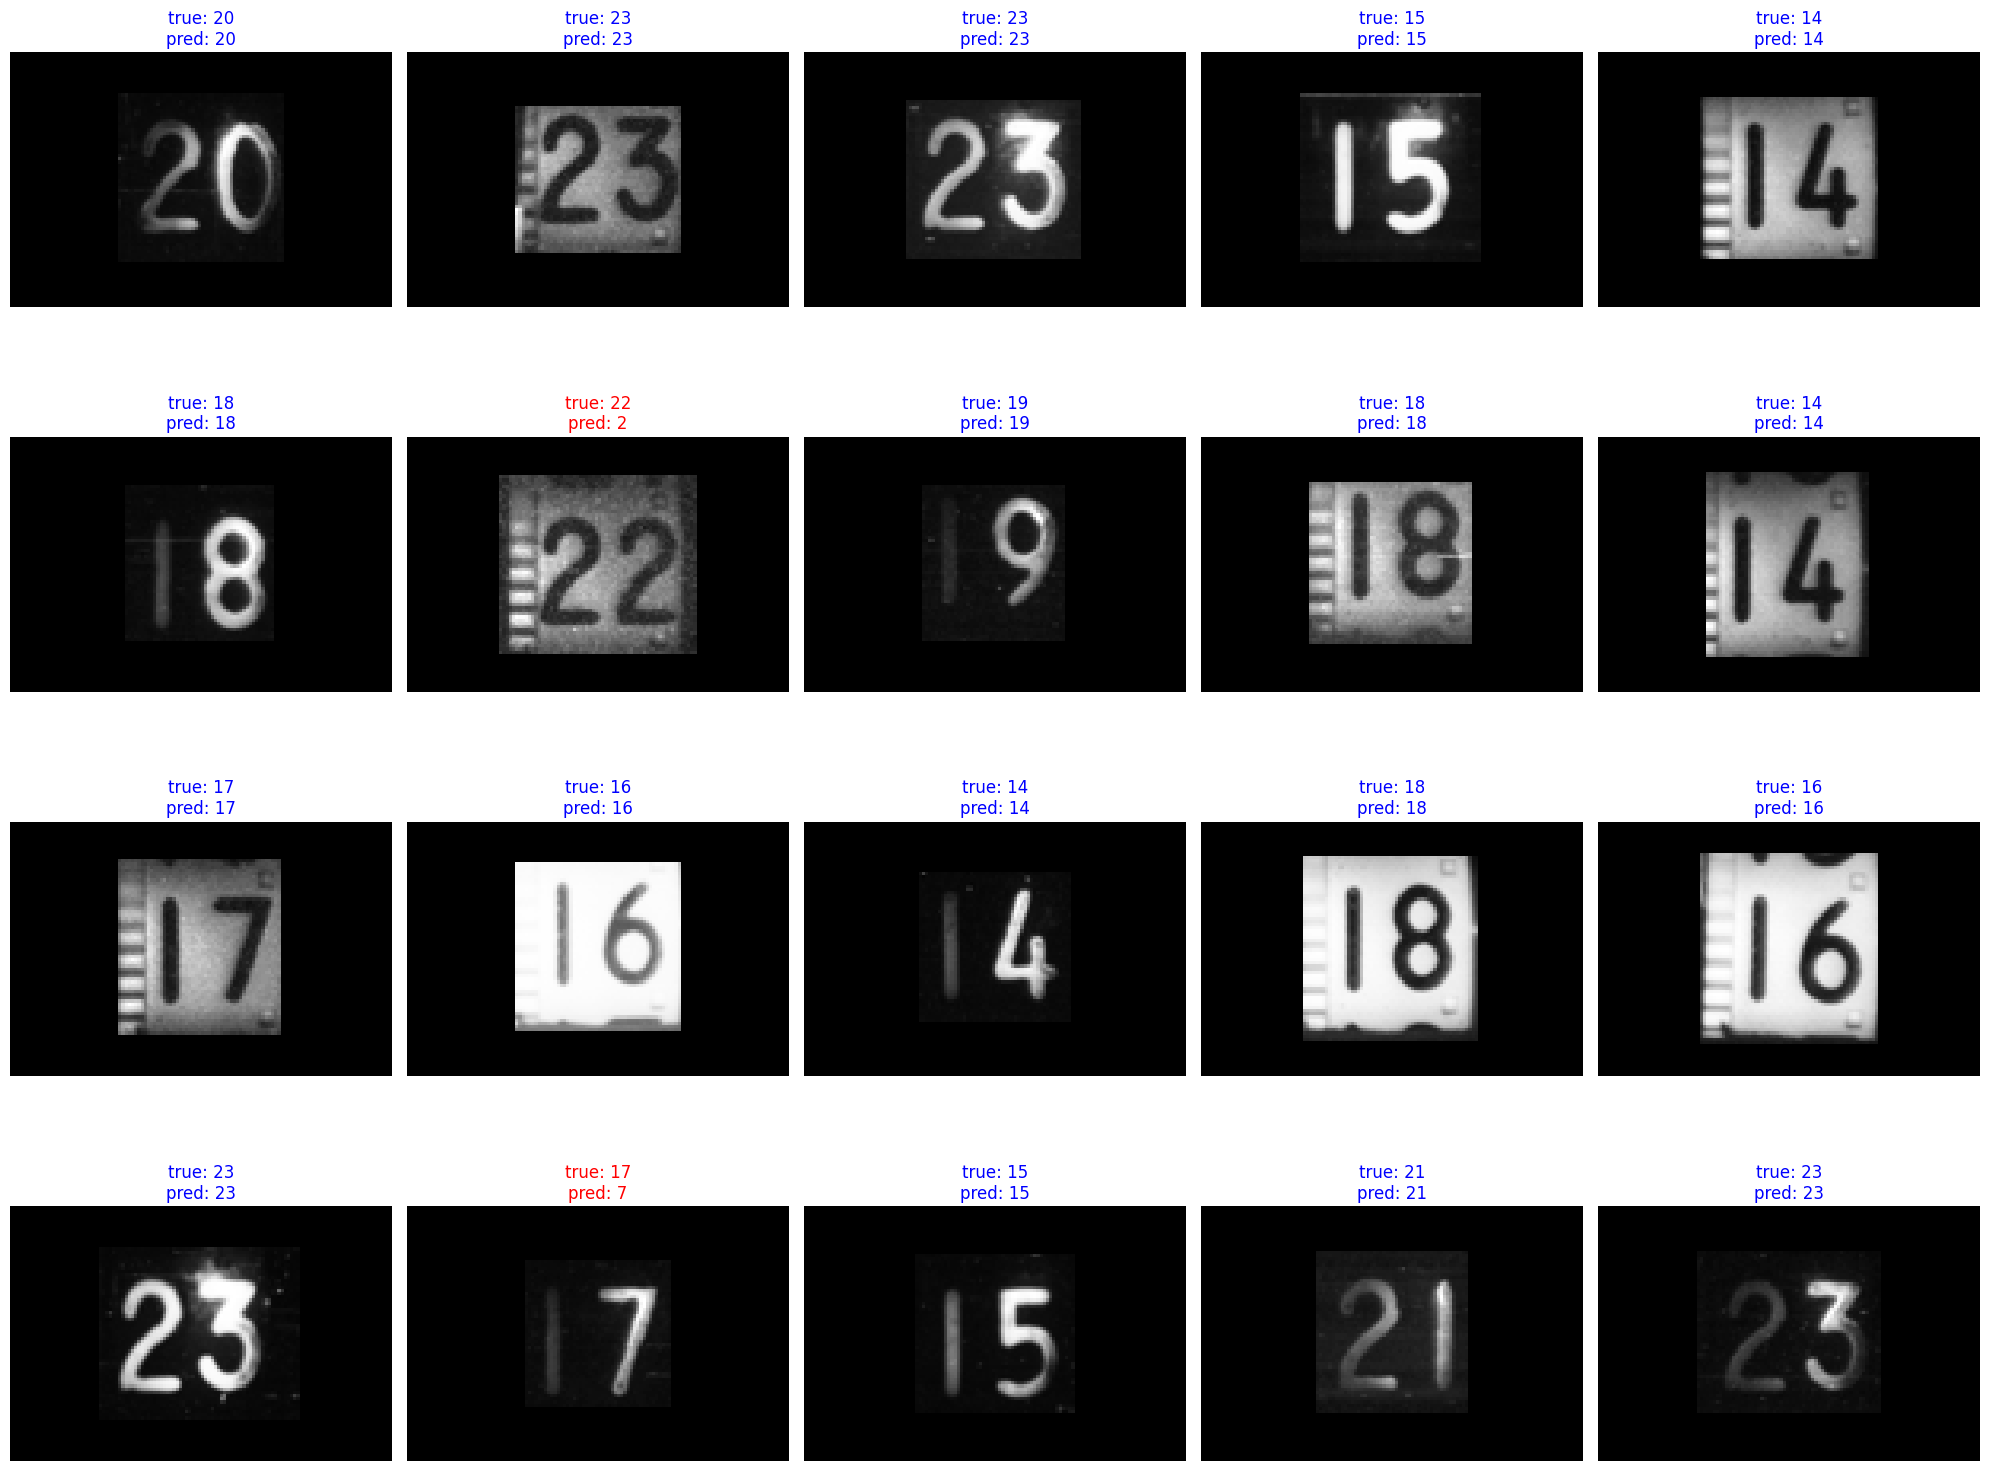


Training complete, final model saved to e:\pythonfile\main-task\read text\hour_crnn_attention_models\hour_crnn_attention_final_model.pt

===== Model comparison =====
Basic CRNN model accuracy: 0.8029
CRNN model with attention mechanism accuracy: 0.8102
Accuracy difference: 0.0073

Basic CRNN model character accuracy: 0.8672
CRNN model with attention mechanism character accuracy: 0.8745
Character accuracy difference: 0.0074


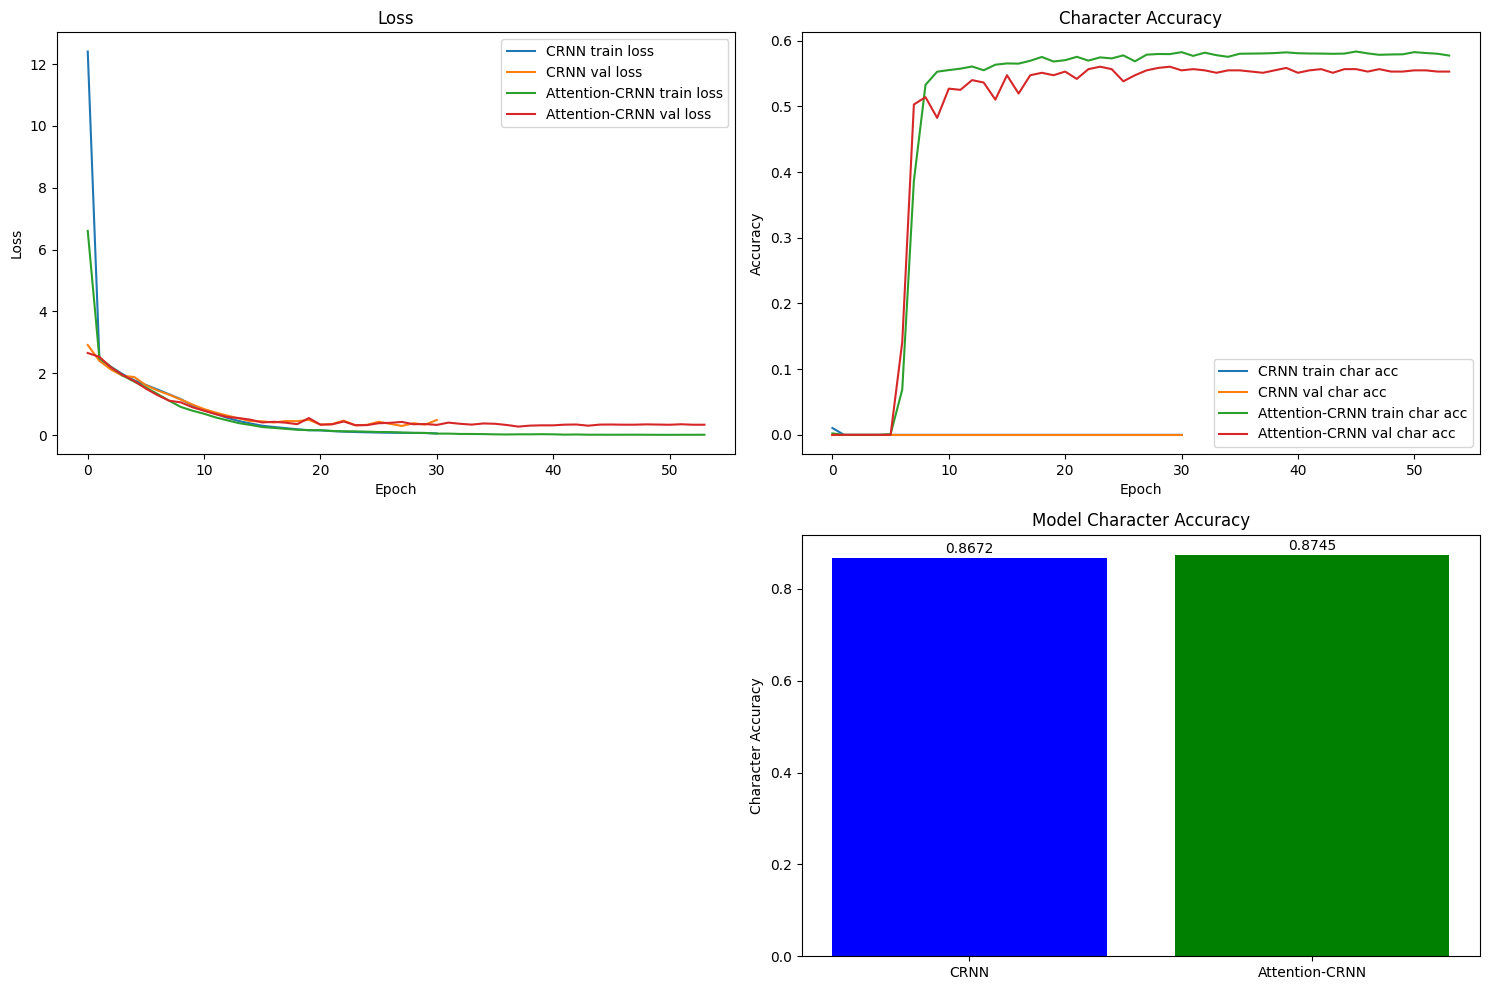

In [7]:


# %%
file_path = 'E:/pythonfile/main-task/'
data_name = ['rell_number', 'date', 'hour', 'minute', 'seconds']
# %%
n = 2
hour_df = data_process(data_name[n])
data_splits = data_main(hour_df)
# %%
parameter = 100, 32, 0.0001
hour_df_results = train_and_compare_models(hour_df, parameter, data_name[n], seed=seed)



Processing completed: 1362 successful, 17 failed
Maximum image dimensions - Height: 72, Width: 128
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training set size: 952
Validation set size: 273
Test set size: 137
Image shape: (72, 128)
Label shape: (2,)


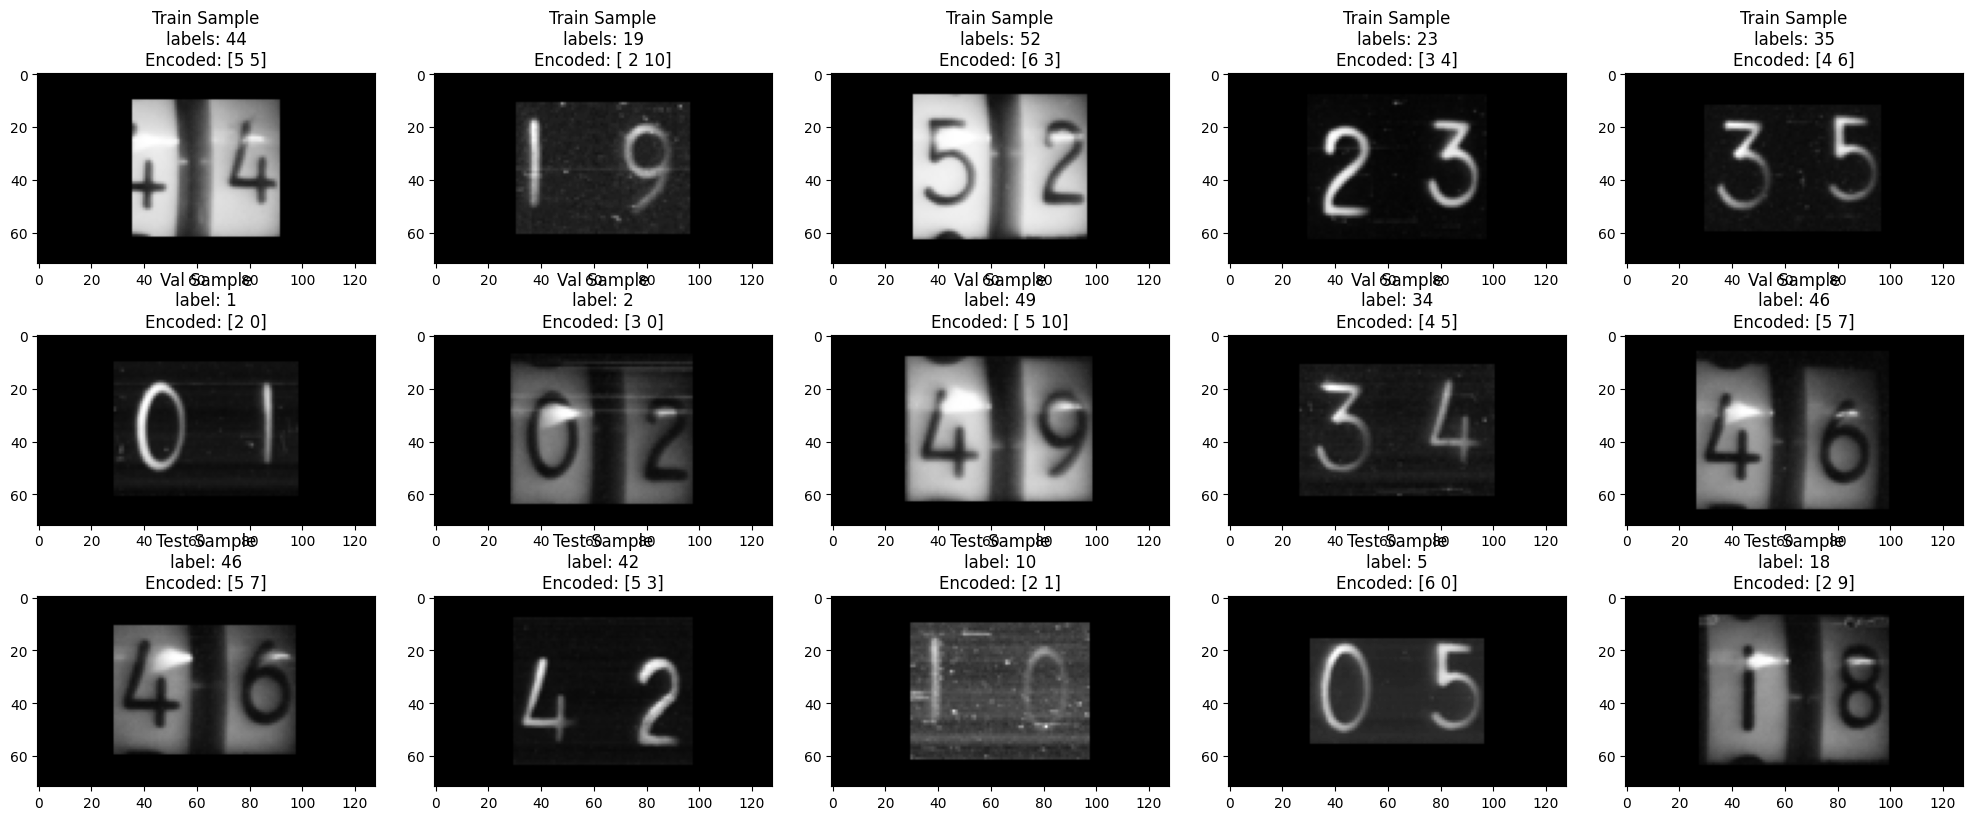


===== Training basic CRNN model =====
Using device: cuda
Selected model type: crnn
Maximum image dimensions - Height: 72, Width: 128
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total model parameters: 2,559,179
Epoch 1/150 - time: 2.09s - LR: 0.000500 - train loss: 8.7829 - val loss: 2.9768 - train char acc: 0.0031 - val char acc: 0.0000
Saved best model, validation loss: 2.9768, character accuracy: 0.0000
Epoch 2/150 - time: 2.29s - LR: 0.000500 - train loss: 2.9190 - val loss: 2.9060 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.9060, character accuracy: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/150 - time: 2.13s - LR: 0.000500 - train loss: 2.8122 - val loss: 2.8055 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.8055, character accuracy: 0.0000
EarlyStopping counter: 2 / 30
Epoch 4/150 - time: 2.17s - LR: 0.000500 - train loss: 2.6637

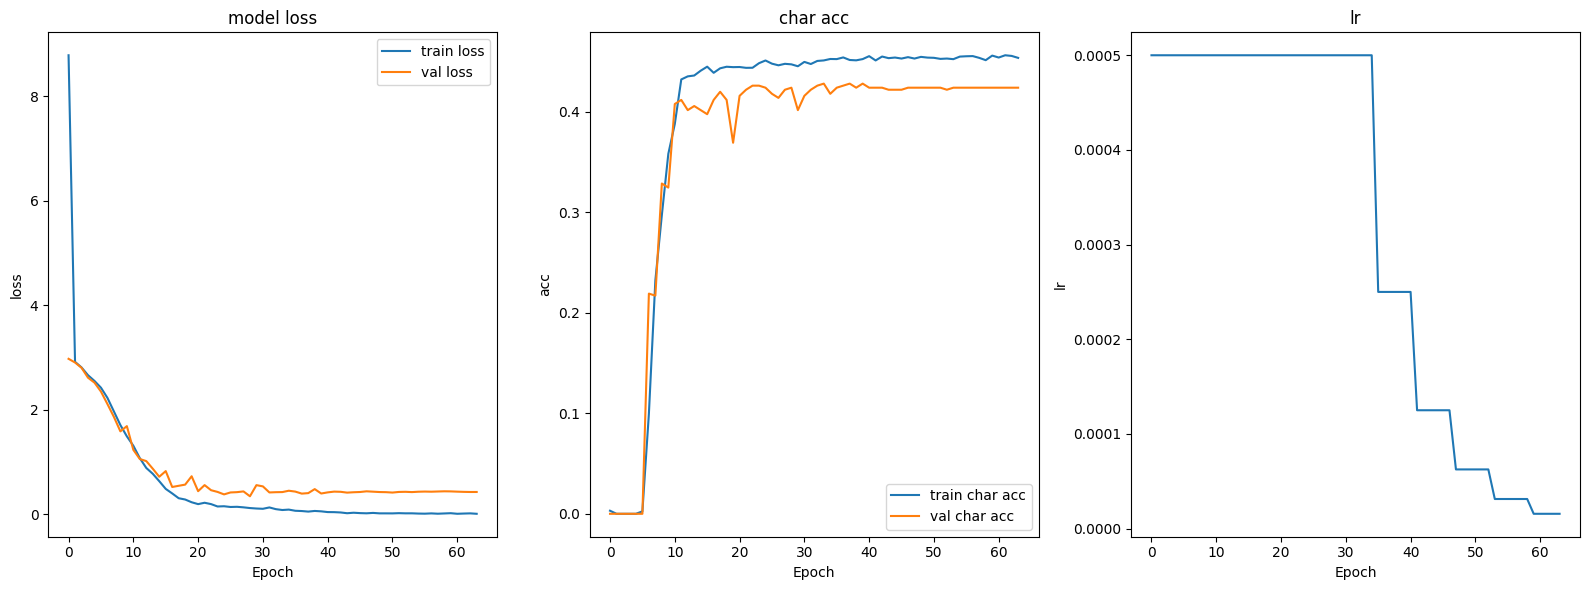


Evaluating crnn model:
Using greedy search to decode predictions...

Overall prediction accuracy: 80.29%
Character accuracy: 87.35%
Average edit distance: 0.23


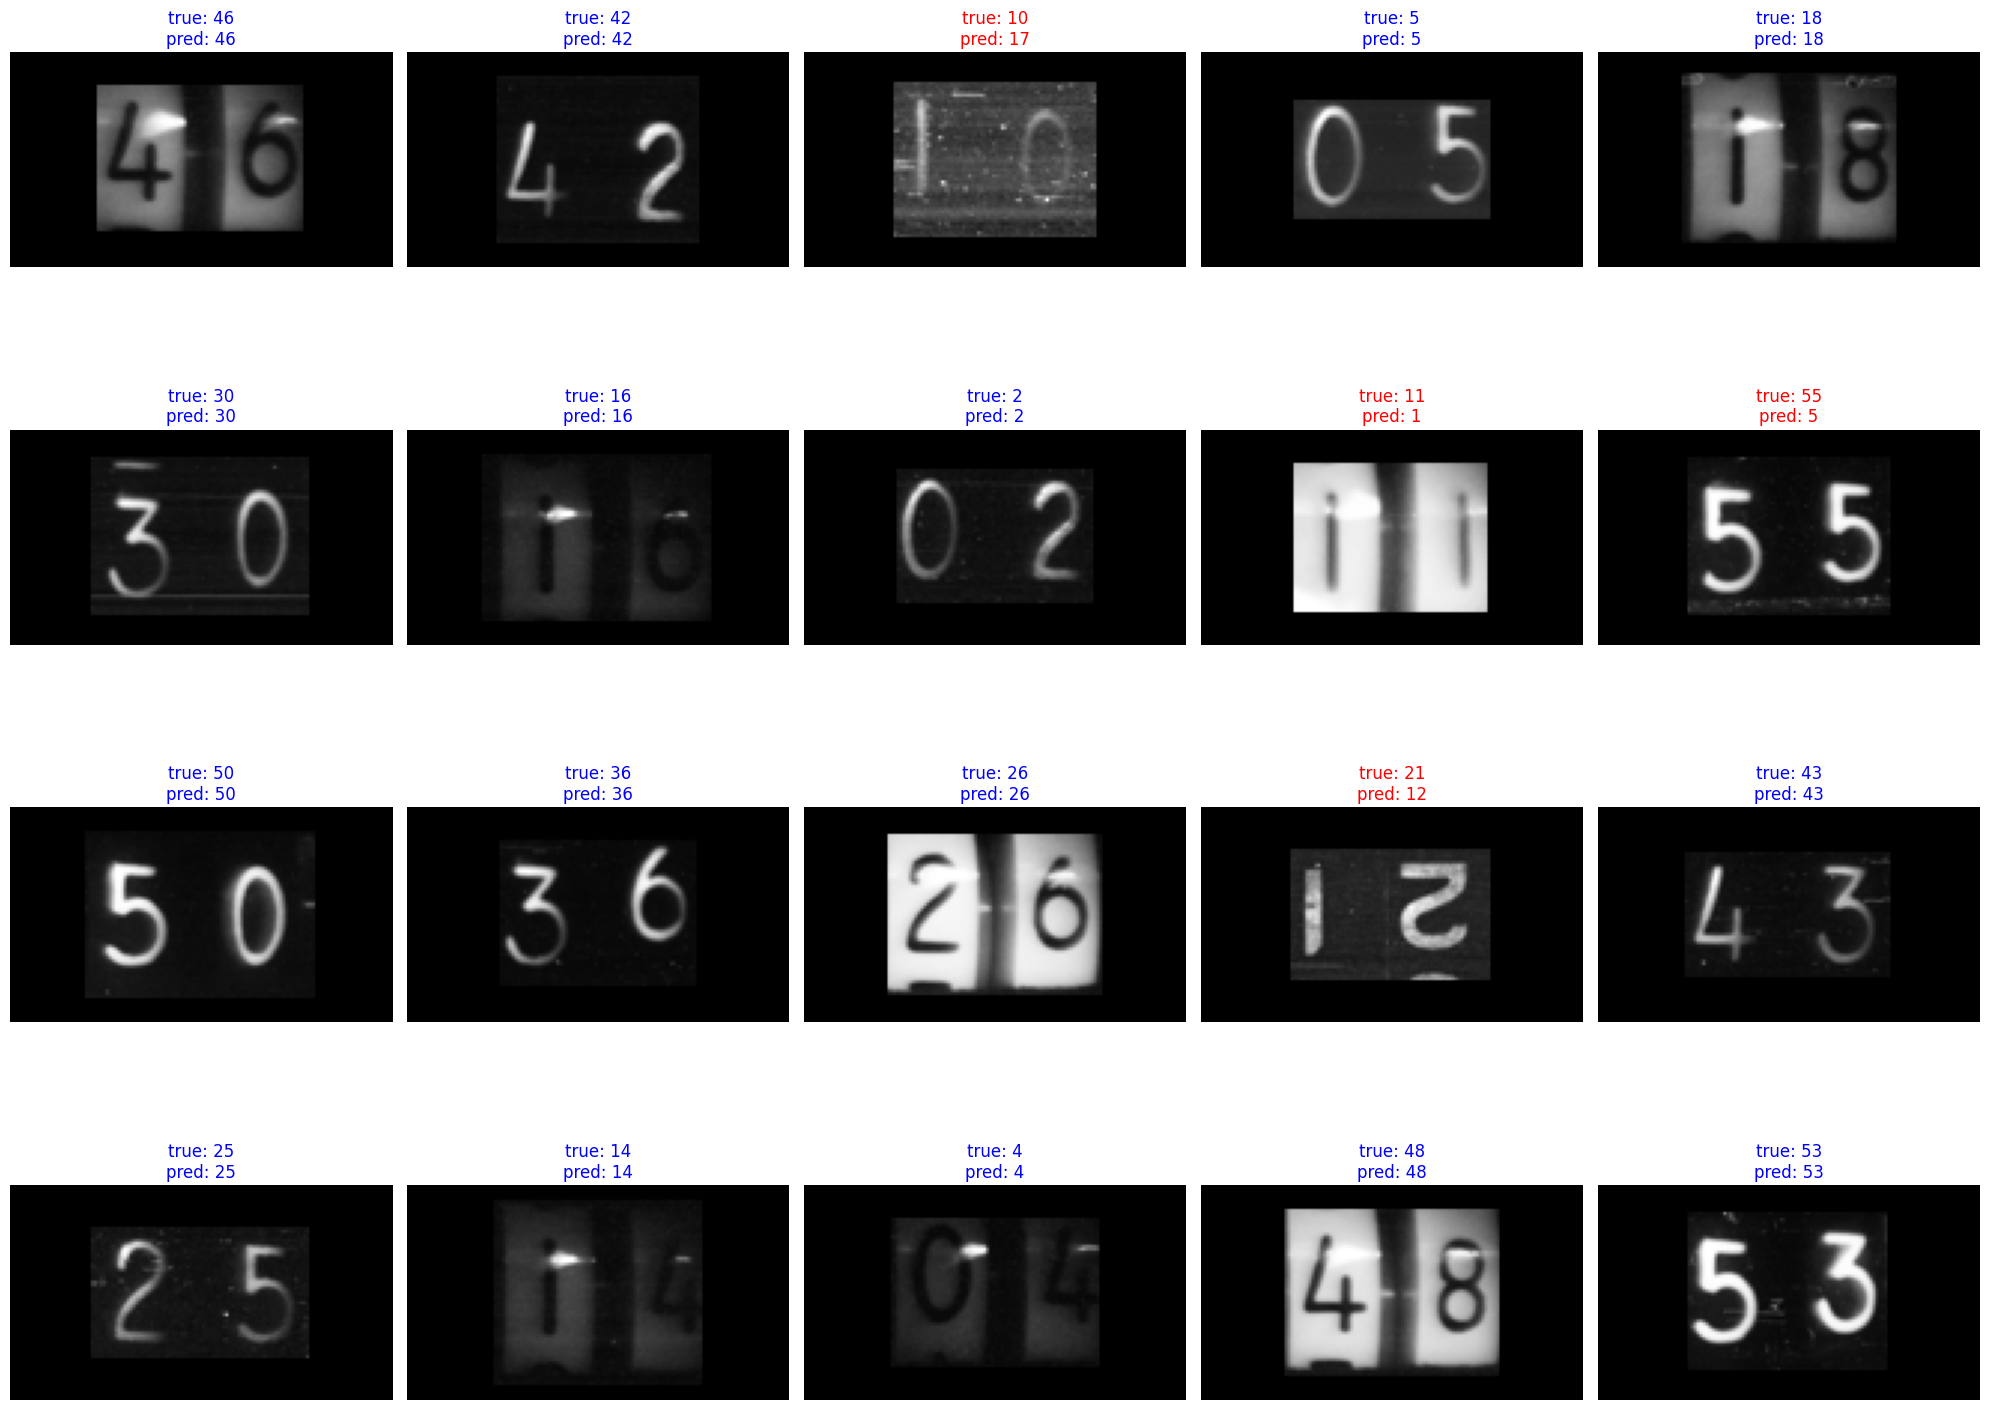


Training complete, final model saved to e:\pythonfile\main-task\read text\minute_crnn_models\minute_crnn_final_model.pt

===== Training CRNN model with attention mechanism =====
Using device: cuda
Selected model type: crnn_attention
Maximum image dimensions - Height: 72, Width: 128
Character set size: 10
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total model parameters: 2,693,579
Epoch 1/150 - time: 2.27s - LR: 0.000500 - train loss: 7.0785 - val loss: 2.9716 - train char acc: 0.0061 - val char acc: 0.0000
Saved best model, validation loss: 2.9716, character accuracy: 0.0000
Epoch 2/150 - time: 2.51s - LR: 0.000500 - train loss: 2.9364 - val loss: 2.9807 - train char acc: 0.0000 - val char acc: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/150 - time: 3.36s - LR: 0.000500 - train loss: 2.8576 - val loss: 2.9285 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 2.9285, character accuracy: 0.0000
EarlyStoppi

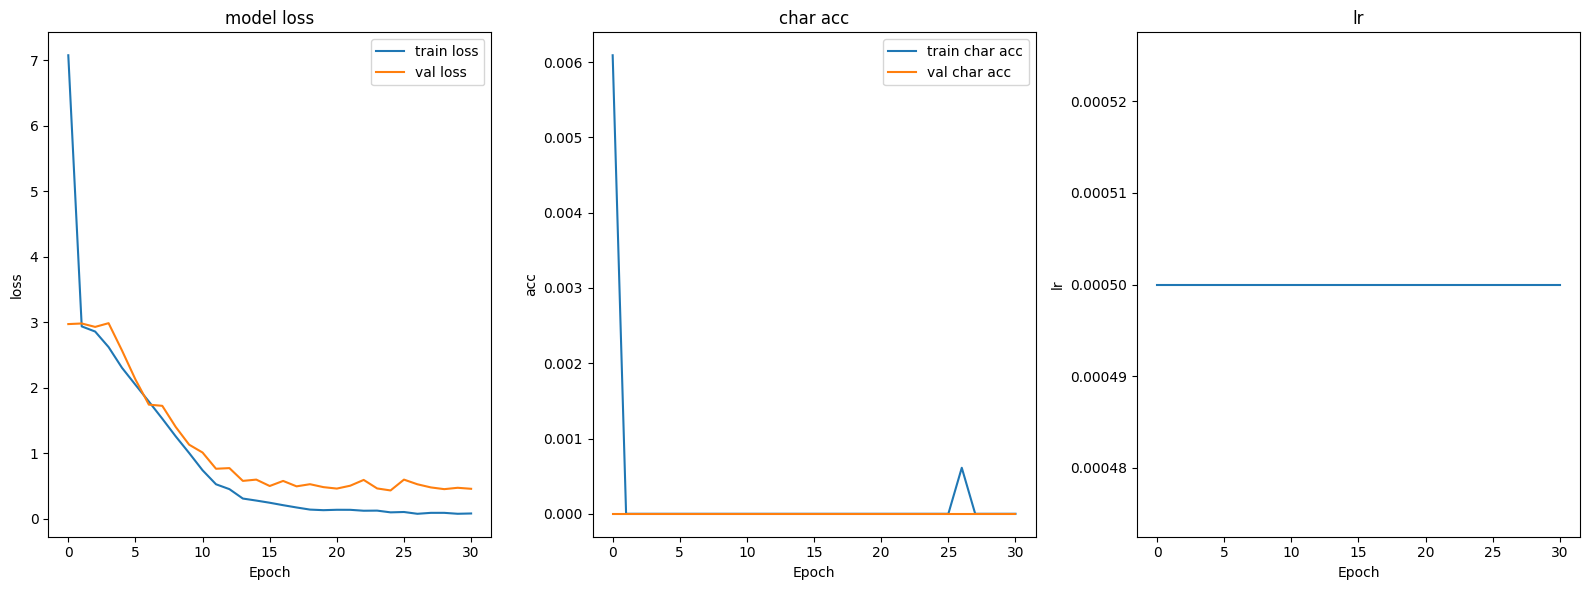


Evaluating crnn_attention model:
Using greedy search to decode predictions...

Overall prediction accuracy: 82.48%
Character accuracy: 87.76%
Average edit distance: 0.21


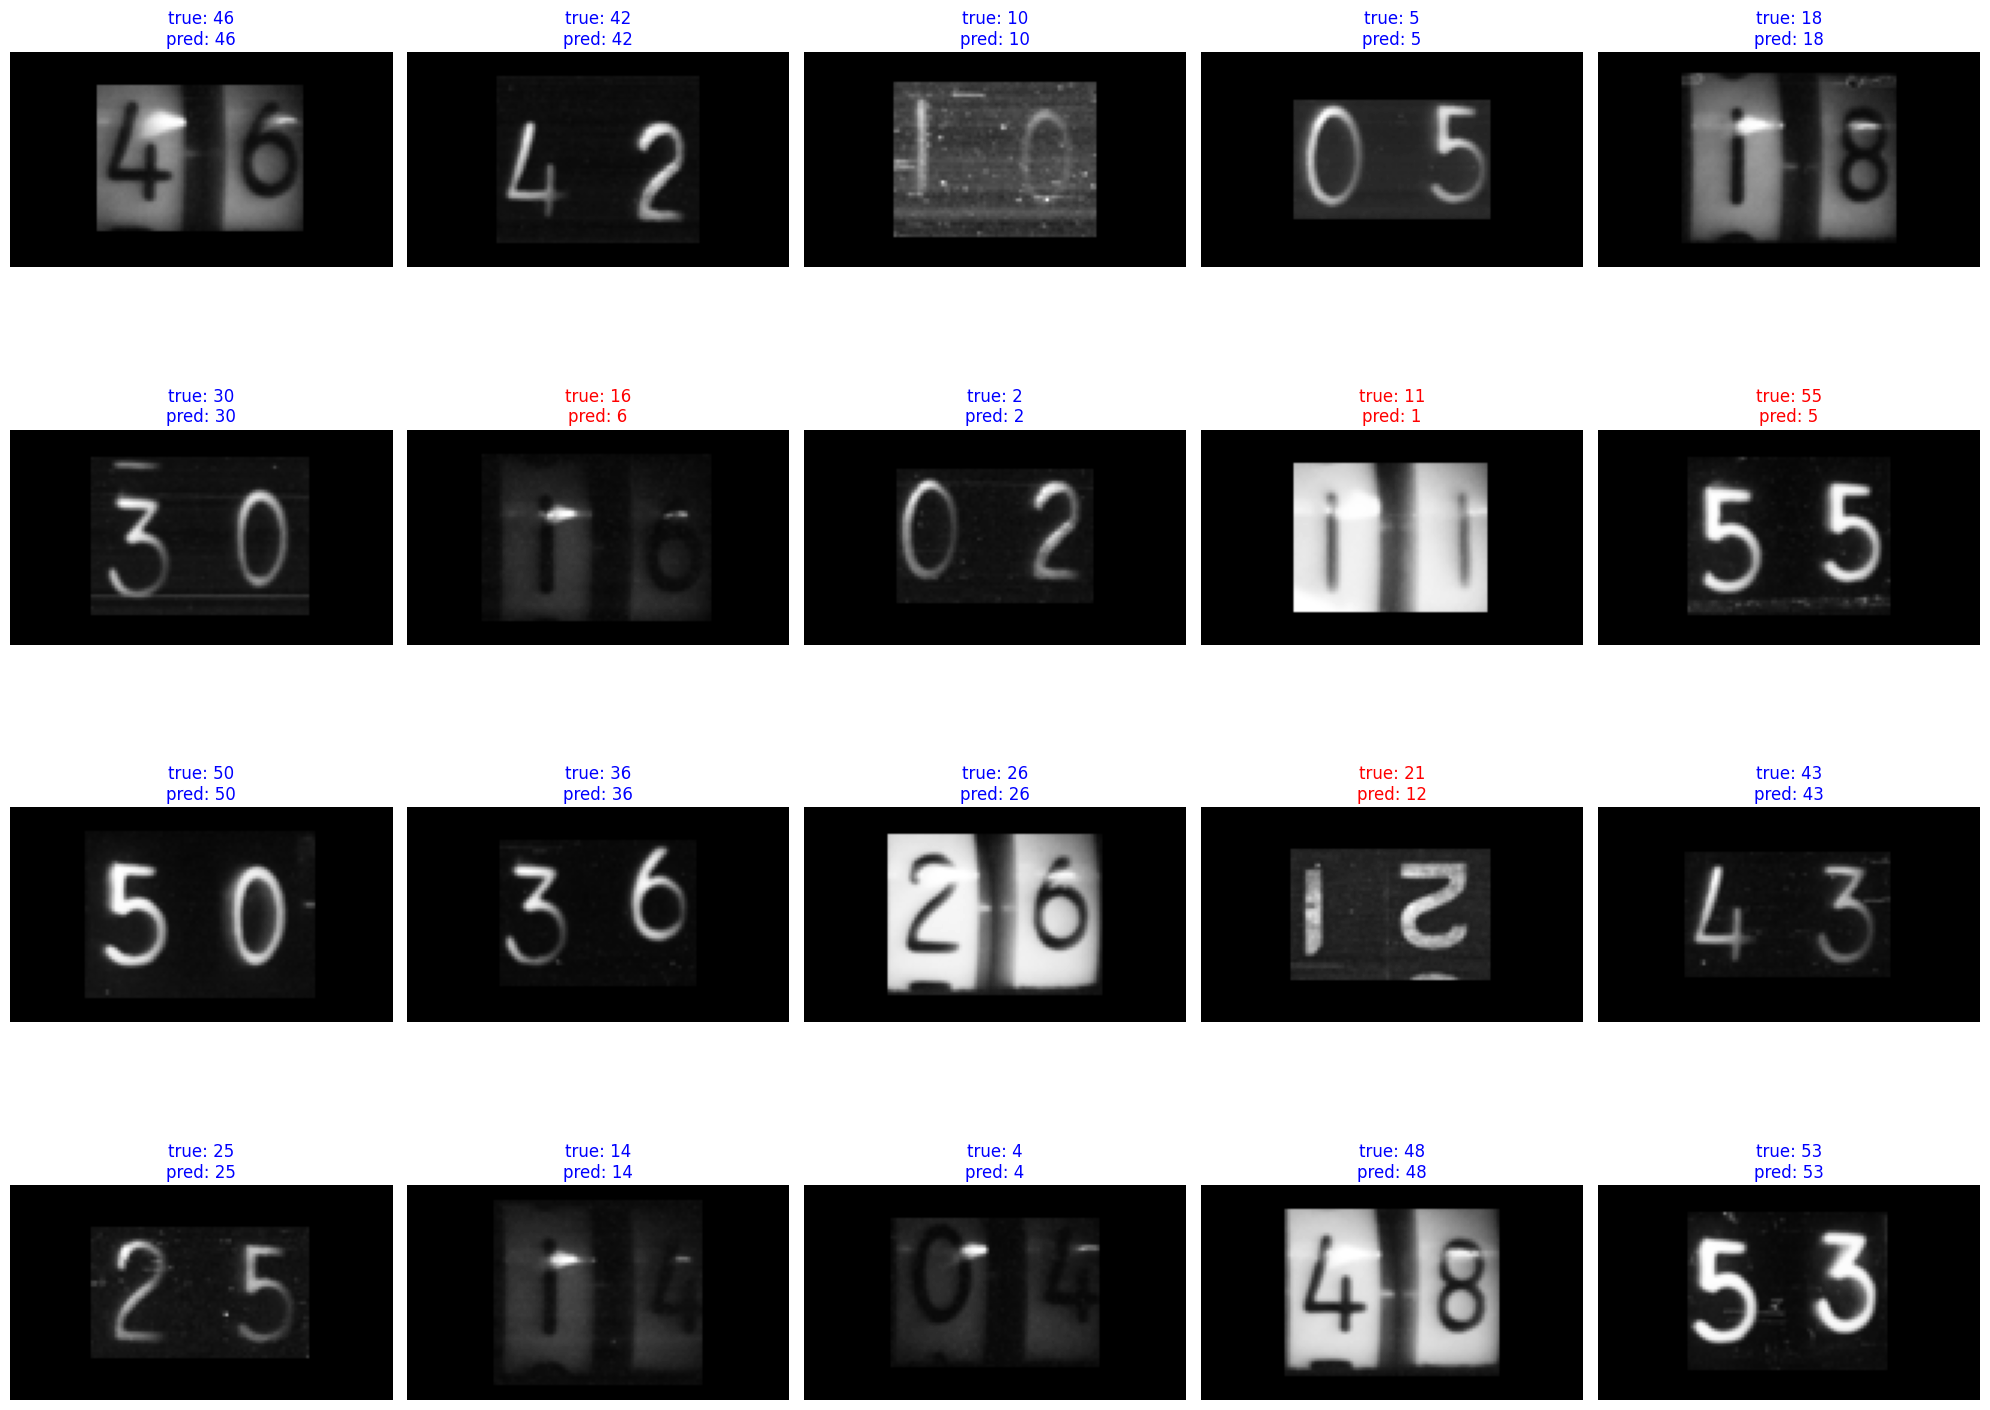


Training complete, final model saved to e:\pythonfile\main-task\read text\minute_crnn_attention_models\minute_crnn_attention_final_model.pt

===== Model comparison =====
Basic CRNN model accuracy: 0.8029
CRNN model with attention mechanism accuracy: 0.8248
Accuracy difference: 0.0219

Basic CRNN model character accuracy: 0.8735
CRNN model with attention mechanism character accuracy: 0.8776
Character accuracy difference: 0.0041


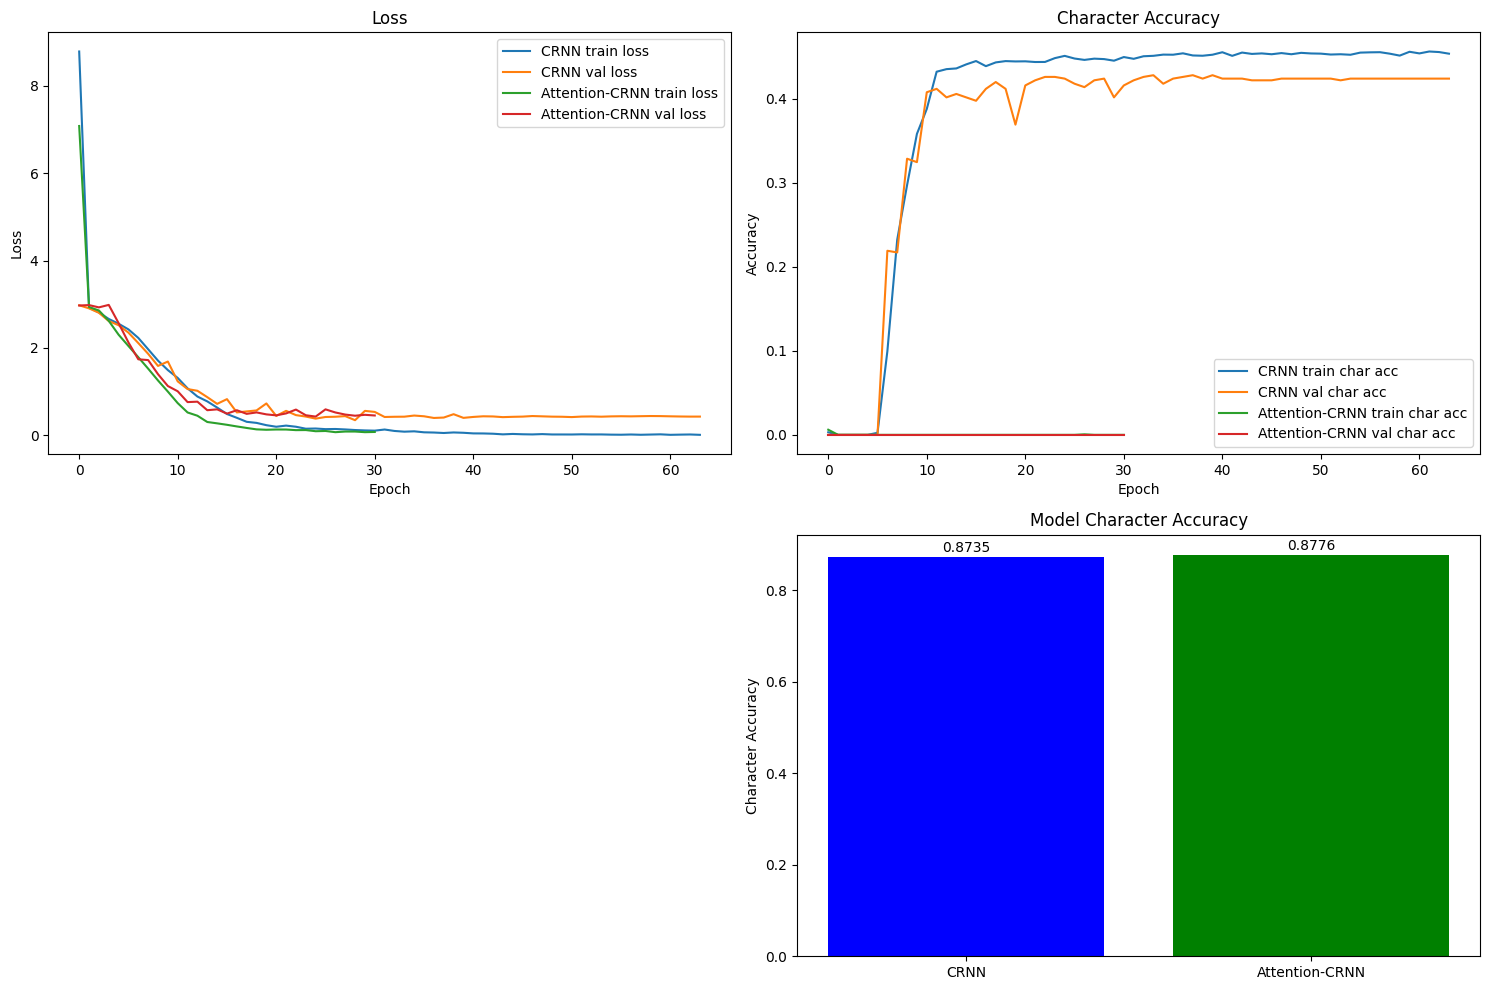

In [8]:

# %%
n = 3
seed=42
minute_df = data_process(data_name[n])
data_splits = data_main(minute_df)
parameter = 150, 64, 0.0005#0.0002
minute_df_results = train_and_compare_models(minute_df, parameter, data_name[n], seed=seed)





Processing completed: 1317 successful, 19 failed
Maximum image dimensions - Height: 72, Width: 96
Character set size: 7
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6']
Training set size: 921
Validation set size: 264
Test set size: 132
Image shape: (72, 96)
Label shape: (2,)


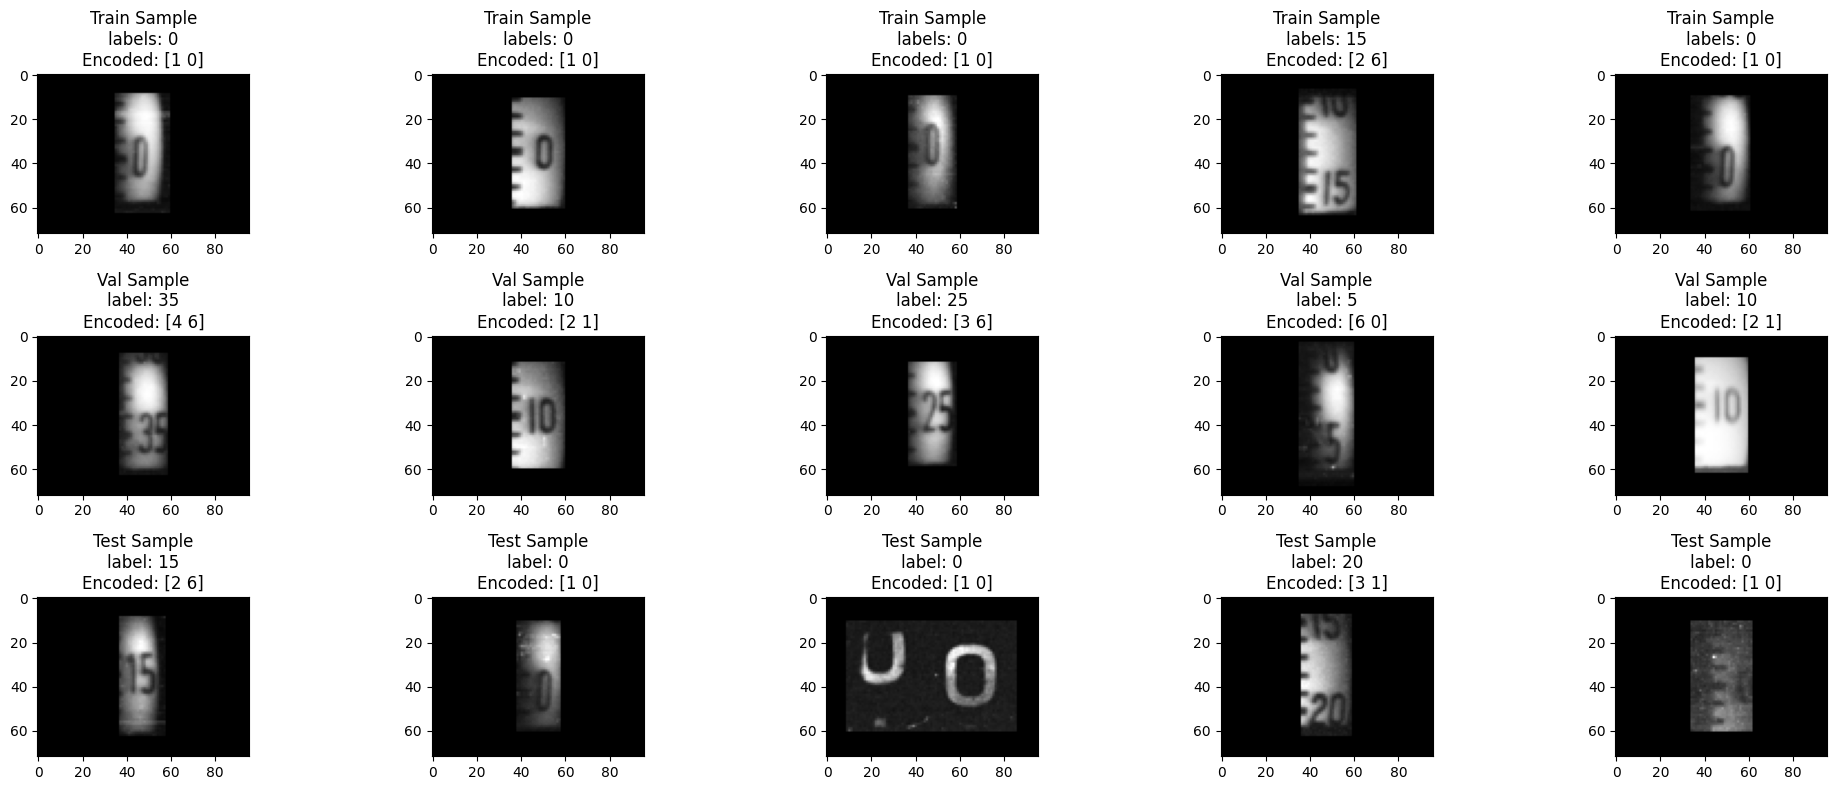


===== Training basic CRNN model =====
Using device: cuda
Selected model type: crnn
Maximum image dimensions - Height: 72, Width: 96
Character set size: 7
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6']
Total model parameters: 2,558,408
Epoch 1/100 - time: 1.79s - LR: 0.000500 - train loss: 7.0283 - val loss: 1.9592 - train char acc: 0.0008 - val char acc: 0.0000
Saved best model, validation loss: 1.9592, character accuracy: 0.0000
Epoch 2/100 - time: 1.78s - LR: 0.000500 - train loss: 1.8722 - val loss: 1.8559 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 1.8559, character accuracy: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/100 - time: 1.86s - LR: 0.000500 - train loss: 1.5810 - val loss: 1.4022 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 1.4022, character accuracy: 0.0000
EarlyStopping counter: 2 / 30
Epoch 4/100 - time: 1.84s - LR: 0.000500 - train loss: 1.1558 - val loss: 1.14

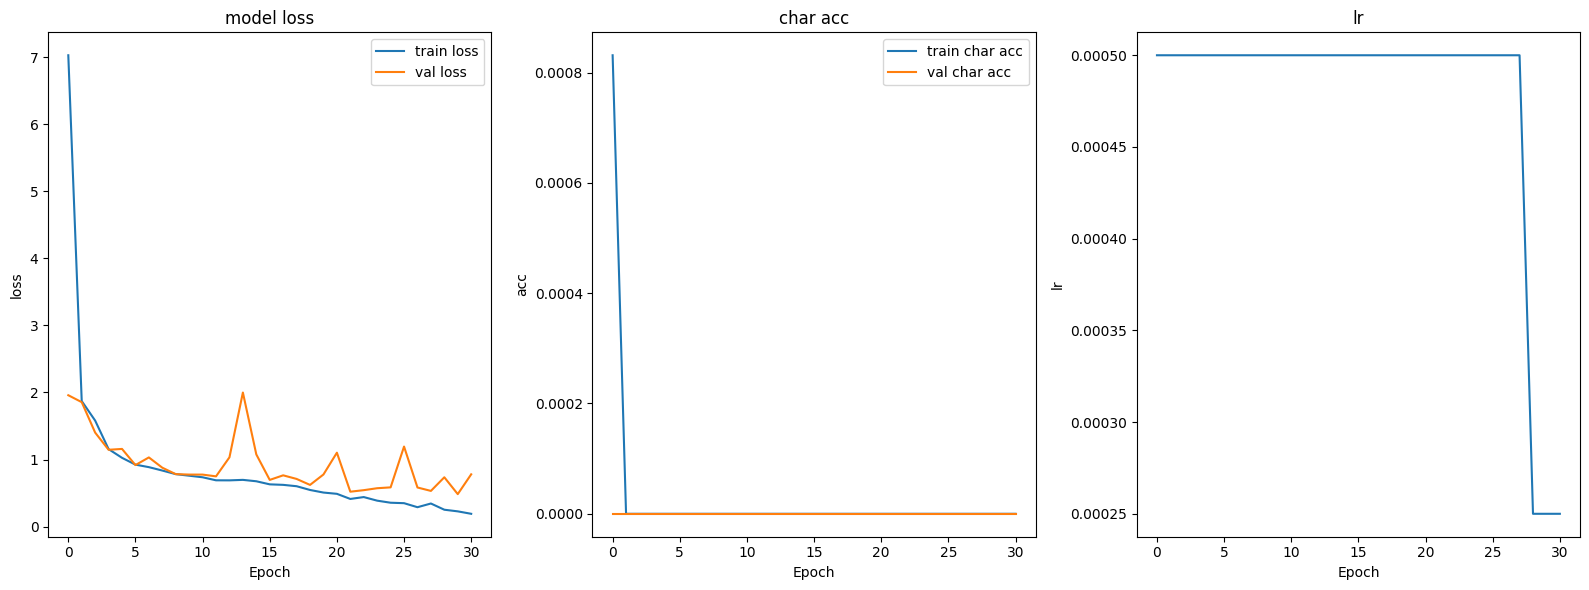


Evaluating crnn model:
Using greedy search to decode predictions...

Overall prediction accuracy: 68.18%
Character accuracy: 71.28%
Average edit distance: 0.38


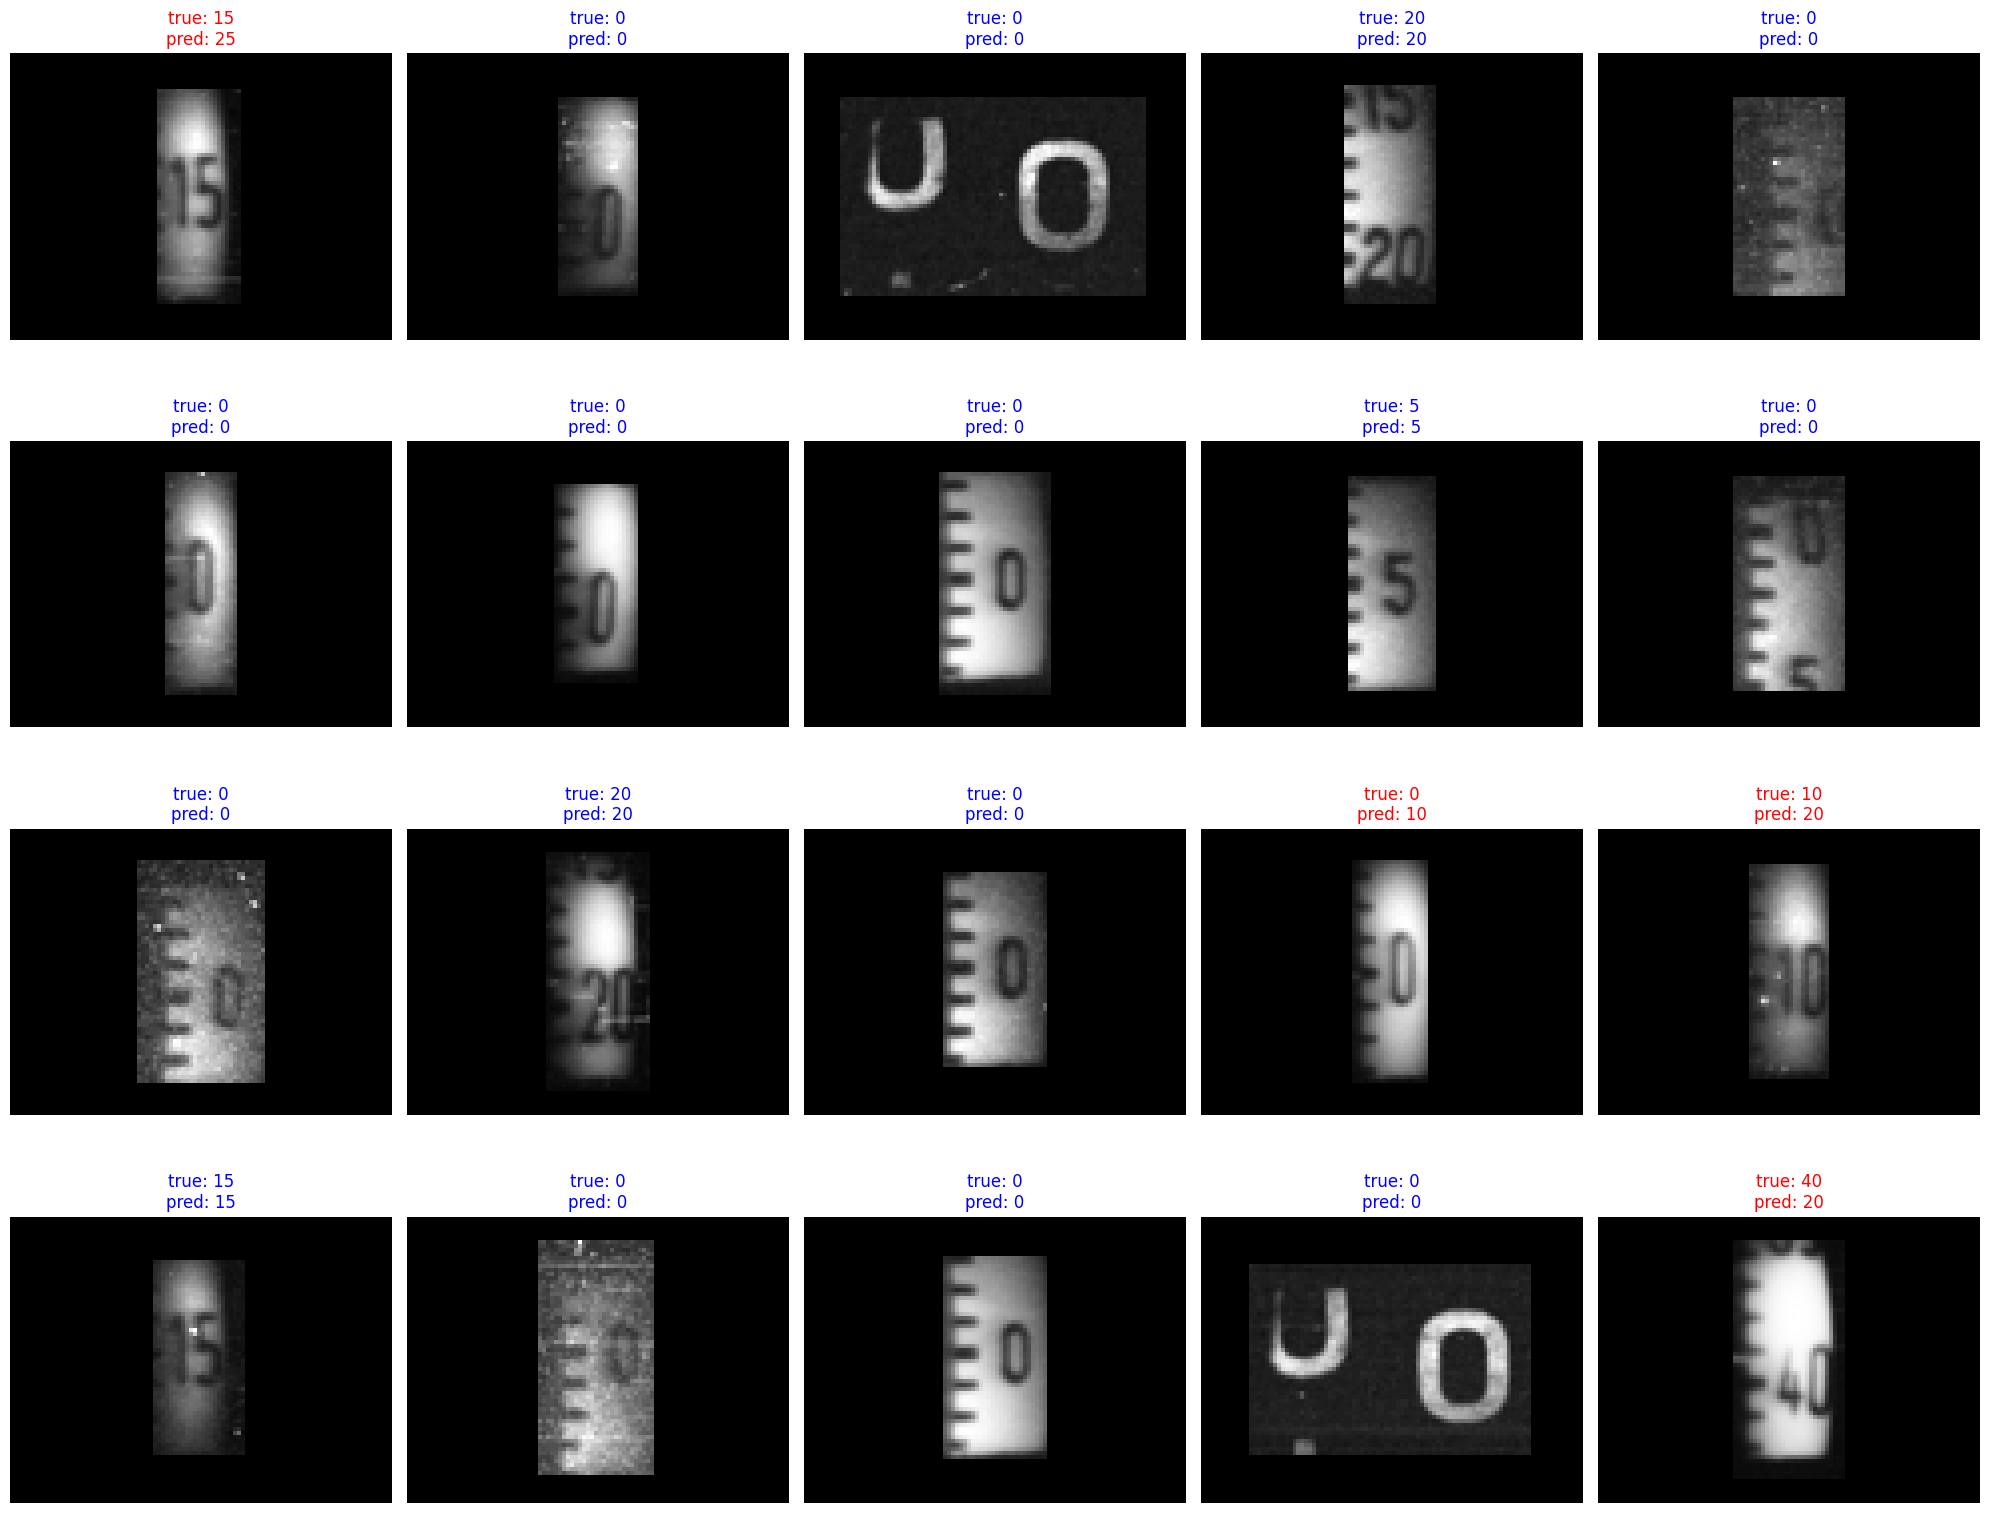


Training complete, final model saved to e:\pythonfile\main-task\read text\seconds_crnn_models\seconds_crnn_final_model.pt

===== Training CRNN model with attention mechanism =====
Using device: cuda
Selected model type: crnn_attention
Maximum image dimensions - Height: 72, Width: 96
Character set size: 7
Maximum label length: 2
Character set:  ['0', '1', '2', '3', '4', '5', '6']
Total model parameters: 2,692,040
Epoch 1/100 - time: 1.92s - LR: 0.000500 - train loss: 5.6919 - val loss: 1.9598 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 1.9598, character accuracy: 0.0000
Epoch 2/100 - time: 1.90s - LR: 0.000500 - train loss: 1.8825 - val loss: 1.9398 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validation loss: 1.9398, character accuracy: 0.0000
EarlyStopping counter: 1 / 30
Epoch 3/100 - time: 1.89s - LR: 0.000500 - train loss: 1.8276 - val loss: 1.9141 - train char acc: 0.0000 - val char acc: 0.0000
Saved best model, validati

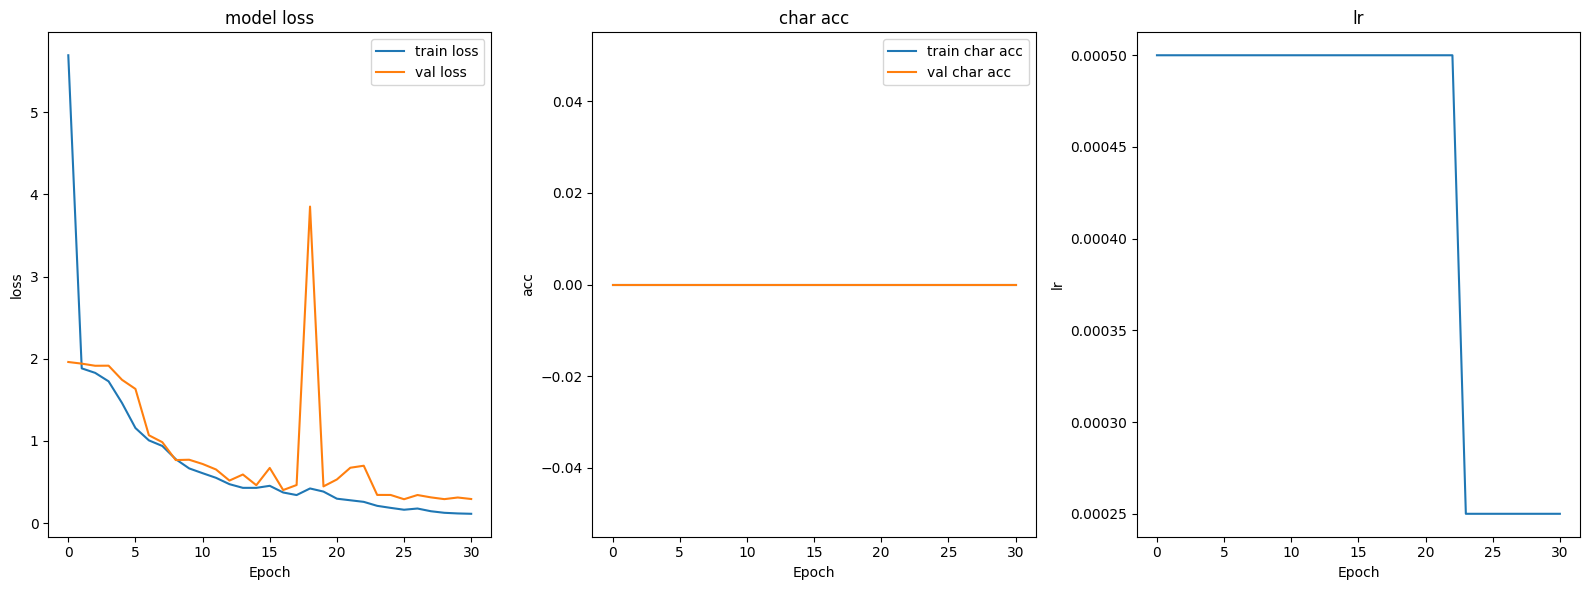


Evaluating crnn_attention model:
Using greedy search to decode predictions...

Overall prediction accuracy: 84.09%
Character accuracy: 83.51%
Average edit distance: 0.20


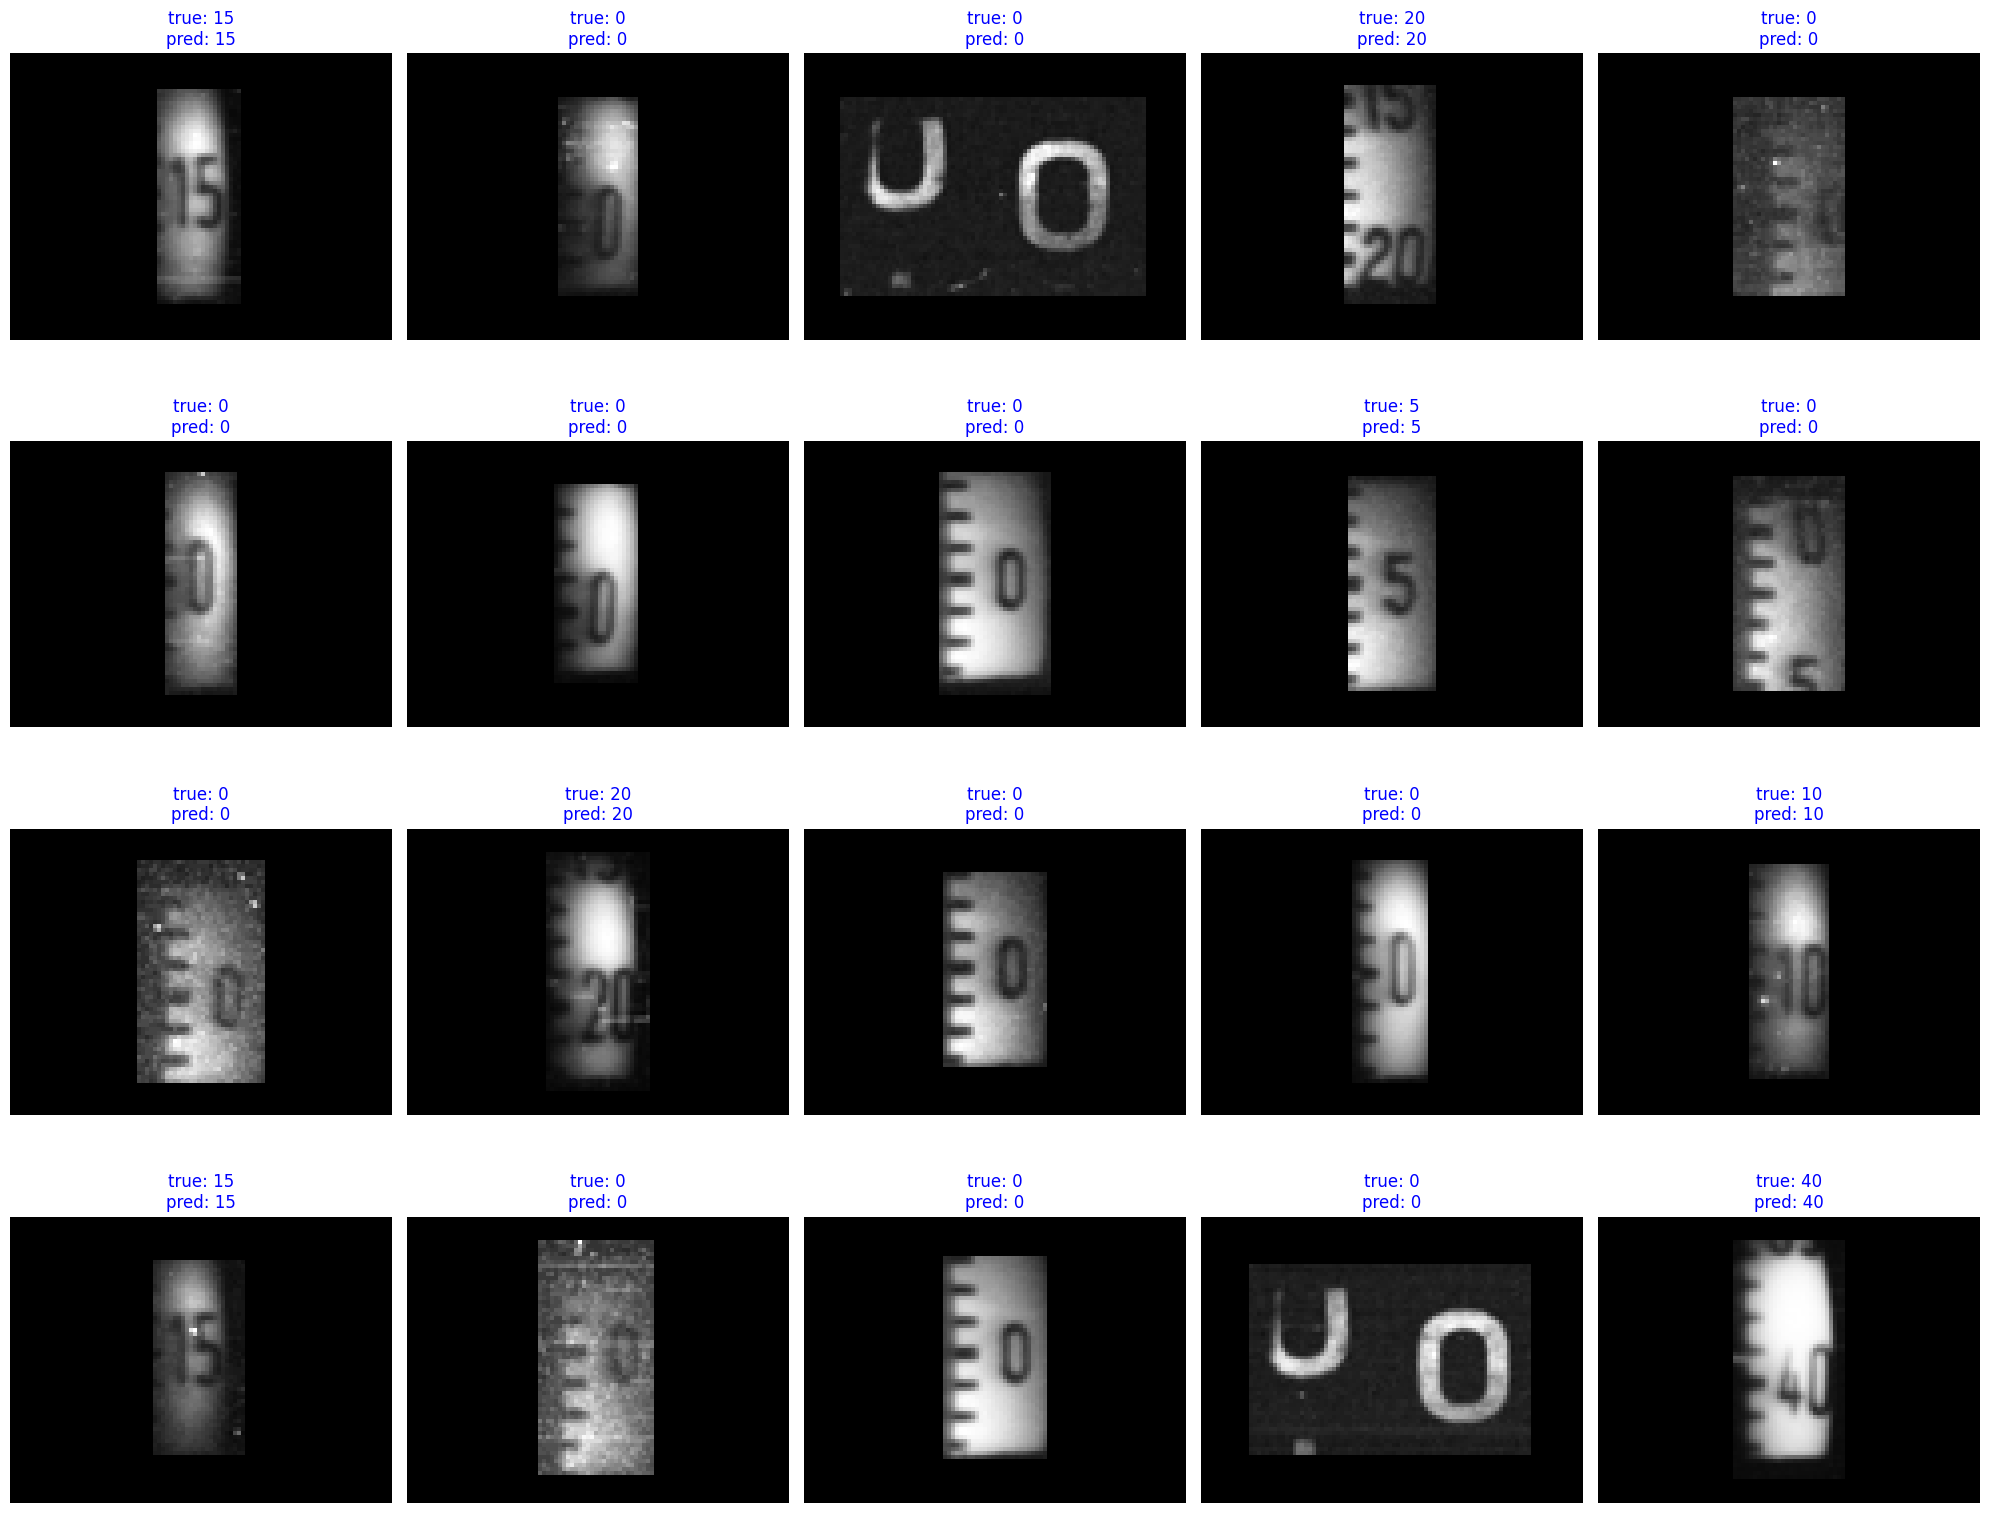


Training complete, final model saved to e:\pythonfile\main-task\read text\seconds_crnn_attention_models\seconds_crnn_attention_final_model.pt

===== Model comparison =====
Basic CRNN model accuracy: 0.6818
CRNN model with attention mechanism accuracy: 0.8409
Accuracy difference: 0.1591

Basic CRNN model character accuracy: 0.7128
CRNN model with attention mechanism character accuracy: 0.8351
Character accuracy difference: 0.1223


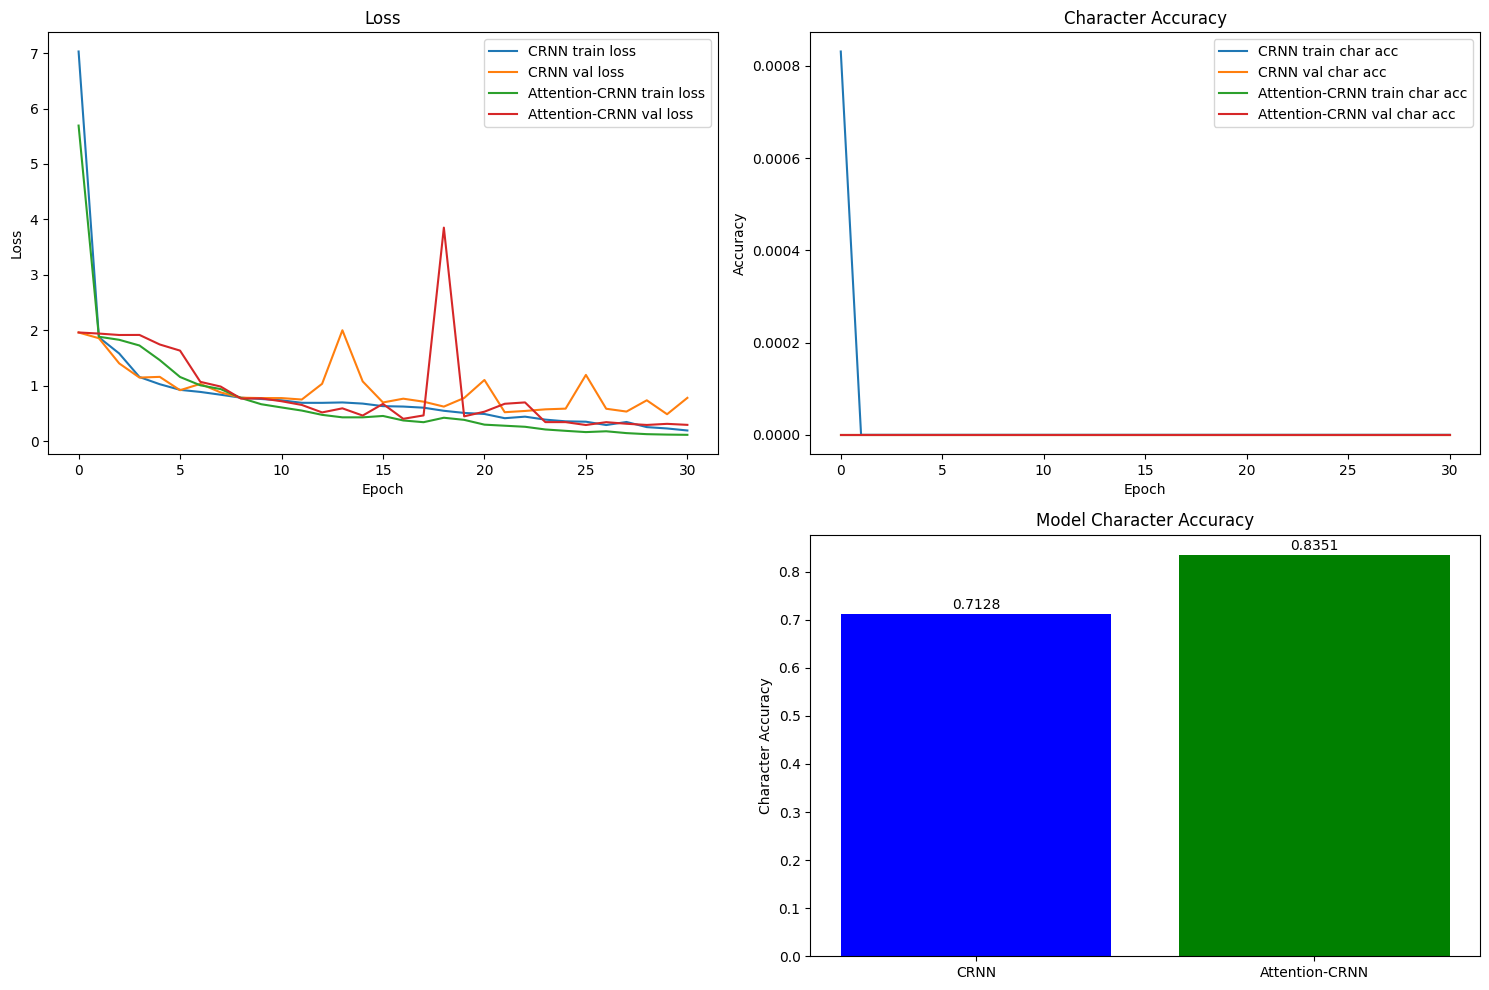

In [10]:
n = 4
seconds_df = data_process(data_name[n])
data_splits = data_main(seconds_df)
parameter = 100, 64, 0.0005
seconds_df_results = train_and_compare_models(seconds_df, parameter, data_name[n], seed=seed)
